#Distribuciones Comunes

## La Distribución Binomial en la Conversión de Ventas

**El Contexto del Negocio:**
Ustedes dirigen un equipo de *Outbound Sales* (Ventas Telefónicas). Su mejor agente hace exactamente $n = 40$ llamadas al día ofreciendo una actualización a una tarjeta de crédito *Black*. Según los datos históricos, la probabilidad de que un cliente acepte la oferta en cualquier llamada dada es del $p = 15\%$ ($0.15$).

Asumiendo que las llamadas son independientes (la respuesta de un cliente no afecta a la del siguiente), el número de ventas diarias sigue una distribución discreta:
$$X \sim \text{Binomial}(n=?, p=?)$$

**El Reto Analítico:**
Utilizando la librería `scipy.stats.binom`, resuelvan las siguientes preguntas operativas:
1. **El Objetivo Exacto (PMF - Función de Masa de Probabilidad):** ¿Cuál es la probabilidad de que el agente cierre *exactamente* 10 ventas hoy?
2. **El Riesgo de Fracaso (CDF - Función de Distribución Acumulada):** La cuota mínima de la empresa es 5 ventas. ¿Cuál es la probabilidad de que el agente no cumpla la cuota (es decir, cierre 4 ventas o menos)?
3. **El Bono de Excelencia (Cuantil / PPF):** La gerencia quiere dar un bono especial solo al $10\%$ de los mejores días históricos. ¿Cuántas ventas son?
4. **Planeación de Capacidad (Simulación):** Simulen las ventas de este agente durante los próximos 10,000 días laborables para ver cómo se distribuirían sus resultados a largo plazo.

--- 1. PROBABILIDAD EXACTA (PMF) ---
P(X = 10): 3.73%

--- 2. PROBABILIDAD ACUMULADA (CDF) ---
P(X <= 4): 26.33%

--- 3. EL CUANTIL (PPF - Percent Point Function) ---
Cuantil 90 (Top 10% de los días): 9.0 ventas

--- 4. SIMULACIÓN DE MONTE CARLO (RVS) ---
Promedio de ventas en 10000 días simulados: 5.95


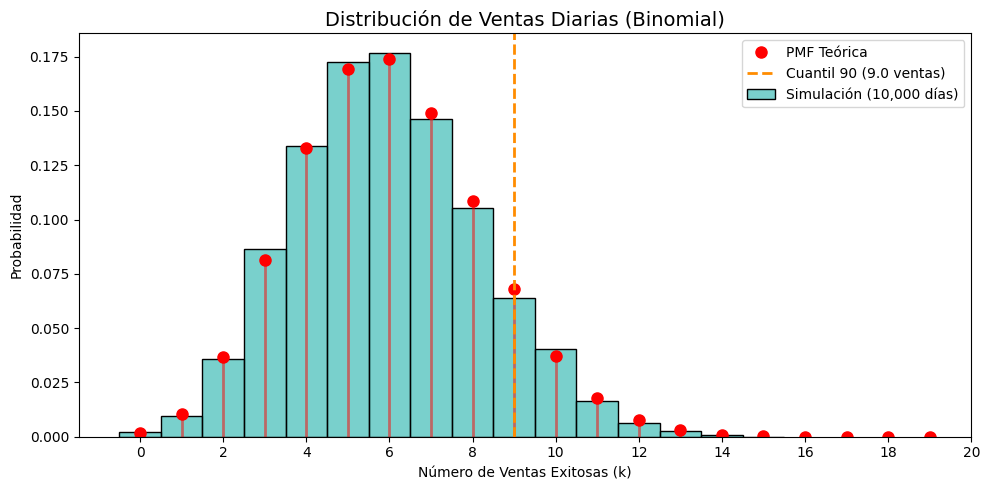

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import binom

# Parámetros del modelo de negocio
n_llamadas = 40
p_conversion = 0.15

print("--- 1. PROBABILIDAD EXACTA (PMF) ---")
# ¿Probabilidad de exactamente 10 ventas?
prob_10 = binom.pmf(k=10, n=n_llamadas, p=p_conversion)
print(f"P(X = 10): {prob_10*100:.2f}%")

print("\n--- 2. PROBABILIDAD ACUMULADA (CDF) ---")
# ¿Probabilidad de 4 ventas o menos?
prob_hasta_4 = binom.cdf(k=4, n=n_llamadas, p=p_conversion)
print(f"P(X <= 4): {prob_hasta_4*100:.2f}%")

print("\n--- 3. EL CUANTIL (PPF - Percent Point Function) ---")
# ¿Cuántas ventas representan el cuantil 90?
cuantil_90 = binom.ppf(q=0.90, n=n_llamadas, p=p_conversion)
print(f"Cuantil 90 (Top 10% de los días): {cuantil_90} ventas")

print("\n--- 4. SIMULACIÓN DE MONTE CARLO (RVS) ---")
# Simulamos 10,000 días de trabajo
np.random.seed(42)
dias_simulados = 10000
ventas_simuladas = binom.rvs(n=n_llamadas, p=p_conversion, size=dias_simulados)
print(f"Promedio de ventas en {dias_simulados} días simulados: {np.mean(ventas_simuladas):.2f}")

# --- VISUALIZACIÓN ---
plt.figure(figsize=(10, 5))

# Graficamos el histograma de la simulación
sns.histplot(ventas_simuladas, discrete=True, stat='proportion', color='lightseagreen', alpha=0.6, label='Simulación (10,000 días)')

# Superponemos la PMF teórica con puntos rojos
x_valores = np.arange(0, 20) # Rango razonable para graficar
pmf_teorica = binom.pmf(x_valores, n_llamadas, p_conversion)
plt.plot(x_valores, pmf_teorica, 'ro', ms=8, label='PMF Teórica')
plt.vlines(x_valores, 0, pmf_teorica, colors='red', lw=2, alpha=0.5)

plt.axvline(cuantil_90, color='darkorange', linestyle='dashed', linewidth=2, label=f'Cuantil 90 ({cuantil_90} ventas)')

plt.title('Distribución de Ventas Diarias (Binomial)', fontsize=14)
plt.xlabel('Número de Ventas Exitosas (k)')
plt.ylabel('Probabilidad')
plt.xticks(np.arange(0, 21, 2))
plt.legend()
plt.tight_layout()
plt.show()

## Control de Calidad

**El Contexto del Negocio:**
El equipo de Experiencia del Cliente (CX) está monitoreando las cancelaciones de pedidos debido a fallas en la pasarela de pagos. Históricamente, la aplicación sufre en promedio **$4.5$** cancelaciones por hora bajo este concepto.

El número de cancelaciones por hora ($X$) se modela como:
$$X \sim \text{Poisson}(\lambda)$$

**El Reto Analítico:**
No nos interesa el valor exacto de una sola cantidad, sino evaluar rangos de riesgo operativo. Utilizando las propiedades de la Función de Distribución Acumulada (`cdf`) y la Función de Supervivencia (`sf` o $1 - \text{CDF}$) en `scipy.stats.poisson`, resuelvan los siguientes incidentes:

1. **La Alarma de Fricción (Probabilidad de Cola Superior):** El sistema dispara una alerta al equipo de ingenieros si ocurren *estrictamente más* de 2 cancelaciones en una hora. ¿Cuál es la probabilidad de que esta alerta se encienda en cualquier hora dada?
2. **El Rango de Tolerancia (Probabilidad de Intervalo):** El nivel de servicio se considera "Degradado pero Manejable" si el número de cancelaciones es mayor a 3, pero no supera las 6 cancelaciones. ¿Cuál es la probabilidad de que el sistema opere en este estado?


--- 1. PROBABILIDAD DE COLA SUPERIOR: P(X > 2) ---
P(X > 2) [Vía Complemento]: 82.64%
P(X > 2) [Vía Survival]:    82.64%
Nota: La alerta a los ingenieros se disparará en el 82.64% de las horas (la tasa base es muy alta).

--- 2. PROBABILIDAD DE INTERVALO: P(3 < X <= 6) ---
P(3 < X <= 6) [Vía CDF]: 48.88%
P(3 < X <= 6) [Vía PMF]: 48.88%


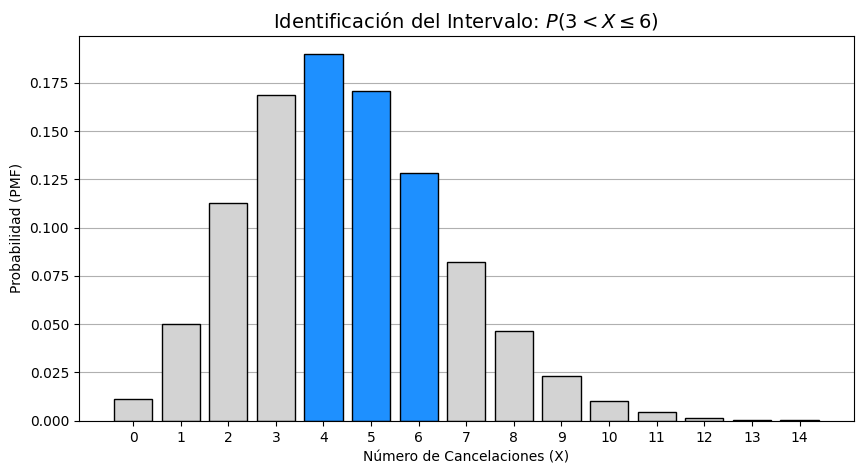

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# Parámetro: Promedio de cancelaciones por hora
tasa_cancelaciones = 4.5

print("--- 1. PROBABILIDAD DE COLA SUPERIOR: P(X > 2) ---")
# Forma 1: Usando la propiedad del complemento (1 - P(X <= 2))
prob_mayor_2_comp = 1 - poisson.cdf(k=2, mu=tasa_cancelaciones)

# Forma 2: Usando la función de supervivencia (sf) que es exactamente 1 - cdf
prob_mayor_2_sf = poisson.sf(k=2, mu=tasa_cancelaciones)

print(f"P(X > 2) [Vía Complemento]: {prob_mayor_2_comp*100:.2f}%")
print(f"P(X > 2) [Vía Survival]:    {prob_mayor_2_sf*100:.2f}%")
print("Nota: La alerta a los ingenieros se disparará en el 82.64% de las horas (la tasa base es muy alta).\n")


print("--- 2. PROBABILIDAD DE INTERVALO: P(3 < X <= 6) ---")
# Análisis de dominio discreto:
# Si 3 < X <= 6, los únicos valores enteros posibles son {4, 5, 6}.
# Por lo tanto, necesitamos P(X <= 6) y restarle todo lo que NO queremos, que es P(X <= 3).

prob_intervalo_cdf = poisson.cdf(k=6, mu=tasa_cancelaciones) - poisson.cdf(k=3, mu=tasa_cancelaciones)

# Comprobación de escritorio (Sumando las PMF individuales de 4, 5 y 6)
prob_intervalo_pmf = poisson.pmf(4, tasa_cancelaciones) + poisson.pmf(5, tasa_cancelaciones) + poisson.pmf(6, tasa_cancelaciones)

print(f"P(3 < X <= 6) [Vía CDF]: {prob_intervalo_cdf*100:.2f}%")
print(f"P(3 < X <= 6) [Vía PMF]: {prob_intervalo_pmf*100:.2f}%")


# --- VISUALIZACIÓN PEDAGÓGICA ---
plt.figure(figsize=(10, 5))
x_vals = np.arange(0, 15)
pmf_vals = poisson.pmf(x_vals, mu=tasa_cancelaciones)

# Crear gráfico de barras base (Gris)
bars = plt.bar(x_vals, pmf_vals, color='lightgray', edgecolor='black', zorder=2)

# Colorear el intervalo P(3 < X <= 6) que corresponde a {4, 5, 6} (Azul)
for i in [4, 5, 6]:
    bars[i].set_color('dodgerblue')
    bars[i].set_edgecolor('black')

# Añadir etiquetas con las correcciones de LaTeX
plt.title(r'Identificación del Intervalo: $P(3 < X \leq 6)$', fontsize=14)
plt.xlabel('Número de Cancelaciones (X)')
plt.ylabel('Probabilidad (PMF)')
plt.xticks(x_vals)
plt.grid(axis='y')

### La Distribución Uniforme y las Ventanas de Tiempo

**El Contexto del Negocio:**
Para optimizar las rutas de los repartidores, la empresa ha lanzado la opción "Ventana de Entrega Flexible". El cliente acepta que su paquete llegará en cualquier momento dentro de una ventana de **30 minutos** (por ejemplo, entre las 2:00 PM y las 2:30 PM).

El algoritmo de enrutamiento despacha al repartidor de forma completamente aleatoria dentro de este bloque. Por lo tanto, el minuto exacto de llegada ($X$) tiene la misma probabilidad de ocurrir en cualquier instante del intervalo $[0, 30]$.

Modelamos el tiempo de llegada como una variable continua:
$$X \sim \text{Uniforme}(a, b)$$

**El Reto Analítico:**
Utilizando la librería `scipy.stats.uniform`, resuelvan:
1. **El Cambio de Paradigma (PDF vs. Probabilidad Exacta):** En distribuciones continuas, ¿cuál es la probabilidad de que el repartidor llegue *exactamente* en el minuto 15? Calcule en su lugar la probabilidad de que llegue en un intervalo específico: entre el minuto 10 y el 15.
2. **La Promesa Temprana (CDF):** ¿Cuál es la probabilidad de que el cliente reciba su paquete en los primeros 10 minutos de la ventana?
3. **El Límite de Paciencia (Cuantil / PPF):** El 80% de los clientes no escriben a soporte técnico si el paquete llega antes de cierto minuto. ¿Cuál es ese minuto límite?
4. **Simulación de la Flota (RVS):** Simulen 5,000 entregas bajo este modelo para comprobar visualmente que la distribución no tiene "picos" de preferencia.

--- 1. PROBABILIDAD DE INTERVALO (PDF/CDF) ---
P(Llegar exactamente al min 15.00): 0.00% (Propiedad de variables continuas)
P(10 < X < 15): 16.67%

--- 2. PROBABILIDAD ACUMULADA (CDF) ---
P(X <= 10): 33.33%

--- 3. EL CUANTIL (PPF) ---
Cuantil 80 (El 80% de paquetes llegan antes del min): 24.0

--- 4. SIMULACIÓN (RVS) ---
Promedio empírico de la simulación: 14.90 minutos (Teórico: 15.00)


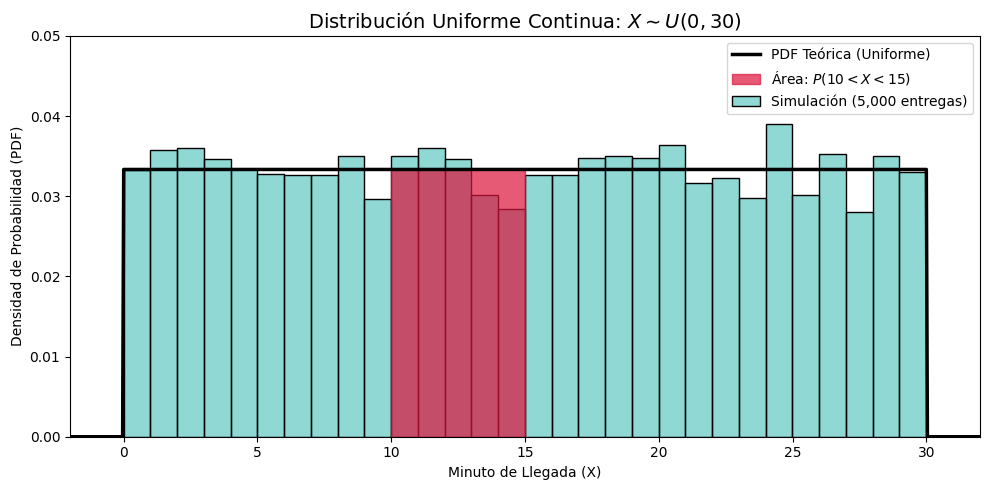

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import uniform

# Parámetros de la Uniforme: a = inicio, b = fin
inicio_a = 0
fin_b = 30
# Para scipy.stats, loc es el inicio (a), y scale es el ancho del intervalo (b - a)
ancho_escala = fin_b - inicio_a

print("--- 1. PROBABILIDAD DE INTERVALO (PDF/CDF) ---")
# En las continuas, P(X = 15) es teóricamente 0. Evaluamos áreas con la CDF.
# P(10 < X < 15) = CDF(15) - CDF(10)
prob_intervalo = uniform.cdf(15, loc=inicio_a, scale=ancho_escala) - uniform.cdf(10, loc=inicio_a, scale=ancho_escala)
print(f"P(Llegar exactamente al min 15.00): 0.00% (Propiedad de variables continuas)")
print(f"P(10 < X < 15): {prob_intervalo*100:.2f}%")

print("\n--- 2. PROBABILIDAD ACUMULADA (CDF) ---")
# Probabilidad de llegar en los primeros 10 minutos
prob_hasta_10 = uniform.cdf(10, loc=inicio_a, scale=ancho_escala)
print(f"P(X <= 10): {prob_hasta_10*100:.2f}%")

print("\n--- 3. EL CUANTIL (PPF) ---")
# Minuto que acumula el 80% de las entregas
cuantil_80 = uniform.ppf(0.80, loc=inicio_a, scale=ancho_escala)
print(f"Cuantil 80 (El 80% de paquetes llegan antes del min): {cuantil_80:.1f}")

print("\n--- 4. SIMULACIÓN (RVS) ---")
# Simulamos 5,000 entregas
np.random.seed(42)
entregas_simuladas = uniform.rvs(loc=inicio_a, scale=ancho_escala, size=5000)
print(f"Promedio empírico de la simulación: {np.mean(entregas_simuladas):.2f} minutos (Teórico: 15.00)")


# --- VISUALIZACIÓN PEDAGÓGICA ---
plt.figure(figsize=(10, 5))

# Histograma empírico
sns.histplot(entregas_simuladas, bins=30, stat='density', color='lightseagreen', alpha=0.5, edgecolor='black', label='Simulación (5,000 entregas)')

# Línea teórica (PDF) - El famoso "rectángulo"
x_vals = np.linspace(-5, 35, 1000)
pdf_vals = uniform.pdf(x_vals, loc=inicio_a, scale=ancho_escala)
plt.plot(x_vals, pdf_vals, 'k-', lw=2.5, label='PDF Teórica (Uniforme)')

# Colorear el área del primer ejercicio P(10 < X < 15)
x_fill = np.linspace(10, 15, 100)
y_fill = uniform.pdf(x_fill, loc=inicio_a, scale=ancho_escala)
plt.fill_between(x_fill, y_fill, color='crimson', alpha=0.7, label=r'Área: $P(10 < X < 15)$')

# Detalles estéticos (protegiendo los strings de LaTeX con 'r')
plt.title(r'Distribución Uniforme Continua: $X \sim U(0, 30)$', fontsize=14)
plt.xlabel('Minuto de Llegada (X)')
plt.ylabel('Densidad de Probabilidad (PDF)')
plt.xlim(-2, 32)
plt.ylim(0, 0.05)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

###La Distribución Normal y el Control de Calidad Operativa

**El Contexto del Negocio:**
Para que un pedido salga a tiempo, los *pickers* (empacadores) deben buscar los productos en los pasillos de la bodega. El equipo de Ingeniería Industrial ha medido miles de pedidos y concluyó que el tiempo de empacado de un pedido estándar ($X$) se distribuye de forma simétrica, siguiendo una **Distribución Normal** con un tiempo medio de **$12$** minutos y una desviación estándar de **$2$** minutos.

$$X \sim N(\mu, \sigma^2)$$

**El Reto Analítico:**
Utilizando la librería `scipy.stats.norm`, resuelvan los siguientes desafíos operativos:
1. **La Regla de Oro (Probabilidad Central):** El gerente de operaciones afirma que "la inmensa mayoría de los pedidos se empacan entre los 10 y los 14 minutos". Calcule exactamente esa probabilidad *Pista: Noten que 10 y 14 equivalen exactamente a $\mu - 1\sigma$ y $\mu + 1\sigma$.*
2. **El Cuello de Botella (Cola Superior):** Si un pedido tarda más de 16 minutos en empacarse, el repartidor que espera afuera penaliza a la tienda. ¿Cuál es el riesgo real de que esto suceda? .
3. **El Bono de Productividad (Cola Inferior y PPF):** Recursos Humanos quiere premiar a los empacadores cada vez que logren un tiempo de empacado tan rápido que pertenezca al **5%** de los mejores tiempos históricos (los tiempos más bajos). ¿Por debajo de qué minuto exacto deben empacar para ganar el bono?

--- 1. PROBABILIDAD CENTRAL: P(10 < X < 14) ---
P(10 < X < 14) [A 1 desviación estándar]: 68.27%

--- 2. EL CUELLO DE BOTELLA: P(X > 16) ---
P(X > 16) [Riesgo de penalización]: 2.28%

--- 3. EL BONO (CUANTIL INFERIOR PPF) ---
Cuantil 5% (Bono de rapidez): Deben empacar en menos de 8.71 minutos

--- 4. SIMULACIÓN (RVS) ---
Promedio del turno simulado: 12.04 min


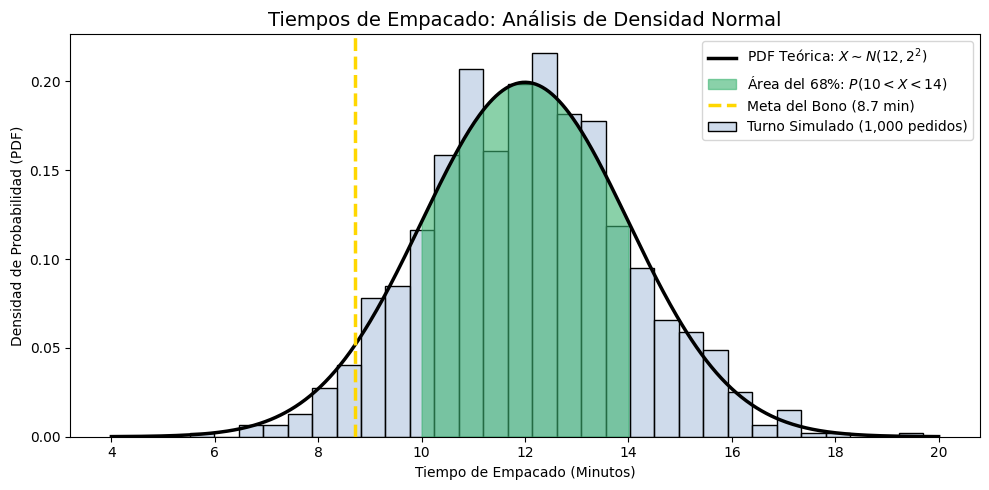

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# Parámetros de la Normal (mu, sigma)
mu_picking = 12.0
sigma_picking = 2.0

print("--- 1. PROBABILIDAD CENTRAL: P(10 < X < 14) ---")
# Calculamos CDF(14) - CDF(10)
prob_central = norm.cdf(14, loc=mu_picking, scale=sigma_picking) - norm.cdf(10, loc=mu_picking, scale=sigma_picking)
print(f"P(10 < X < 14) [A 1 desviación estándar]: {prob_central*100:.2f}%")

print("\n--- 2. EL CUELLO DE BOTELLA: P(X > 16) ---")
# Usamos la función de supervivencia (sf = 1 - cdf)
prob_mayor_16 = norm.sf(16, loc=mu_picking, scale=sigma_picking)
print(f"P(X > 16) [Riesgo de penalización]: {prob_mayor_16*100:.2f}%")

print("\n--- 3. EL BONO (CUANTIL INFERIOR PPF) ---")
# Queremos el 5% de los tiempos MÁS RÁPIDOS (la cola izquierda de la campana)
cuantil_05 = norm.ppf(0.05, loc=mu_picking, scale=sigma_picking)
print(f"Cuantil 5% (Bono de rapidez): Deben empacar en menos de {cuantil_05:.2f} minutos")

print("\n--- 4. SIMULACIÓN (RVS) ---")
# Simulamos 1,000 pedidos en un turno
np.random.seed(42)
pedidos_simulados = norm.rvs(loc=mu_picking, scale=sigma_picking, size=1000)
print(f"Promedio del turno simulado: {np.mean(pedidos_simulados):.2f} min")


# --- VISUALIZACIÓN PEDAGÓGICA ---
plt.figure(figsize=(10, 5))

# Histograma de la simulación
sns.histplot(pedidos_simulados, bins=30, stat='density', color='lightsteelblue', alpha=0.6, edgecolor='black', label='Turno Simulado (1,000 pedidos)')

# Curva teórica (PDF)
x_vals = np.linspace(4, 20, 500)
pdf_vals = norm.pdf(x_vals, loc=mu_picking, scale=sigma_picking)
plt.plot(x_vals, pdf_vals, 'k-', lw=2.5, label=r'PDF Teórica: $X \sim N(12, 2^2)$')

# Colorear el área central (mu +/- 1 sigma)
x_fill = np.linspace(10, 14, 100)
y_fill = norm.pdf(x_fill, loc=mu_picking, scale=sigma_picking)
plt.fill_between(x_fill, y_fill, color='mediumseagreen', alpha=0.6, label=r'Área del 68%: $P(10 < X < 14)$')

# Marcar el límite del bono (Cuantil 5)
plt.axvline(cuantil_05, color='gold', linestyle='dashed', lw=2.5, label=f'Meta del Bono ({cuantil_05:.1f} min)')

# Estética
plt.title(r'Tiempos de Empacado: Análisis de Densidad Normal', fontsize=14)
plt.xlabel('Tiempo de Empacado (Minutos)')
plt.ylabel('Densidad de Probabilidad (PDF)')
plt.xticks(np.arange(4, 21, 2))
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

## La Lección Estadística y Gerencial

1. **El Descubrimiento del 68%:** Al calcular la probabilidad de empacar entre $10$ y $14$ minutos ($\mu \pm 1\sigma$), el resultado fue **$68.27\%$**. Esta es una ley universal de la Distribución Normal: en cualquier fenómeno del mundo real verdaderamente Normal, aproximadamente el $68\%$ de los datos siempre caerán a una desviación estándar de distancia de la media.
2. **El Control de Riesgos Extremos:** La probabilidad de tardar más de 16 minutos es sorprendentemente baja (**$2.28\%$**). Esto ocurre porque 16 minutos está a dos desviaciones estándar de distancia ($\mu + 2\sigma$). La campana de Gauss "castiga" fuertemente a los valores extremos, haciendo que los tiempos excesivamente altos sean raros (a menos que haya un problema sistémico en la bodega que rompa la normalidad).
3. **El Cuantil en la Cola Izquierda:** A diferencia de la capacidad de la bodega donde queríamos prepararnos para el peor caso (cola derecha), en tiempos de entrega "menos es mejor". Por eso, calculamos el $Q_{0.05}$ (el 5% inferior) para encontrar el umbral de **$8.71$ minutos**. Cualquier empacador que rompa esa barrera está rindiendo a un nivel excepcional de rapidez.

### La Distribución Exponencial y la "Falta de Memoria"

**El Contexto del Negocio:**
Ustedes auditan el *Call Center* de Soporte Técnico. Han determinado que el tiempo de espera hasta que un operador contesta la llamada es una variable continua y asimétrica. La mayoría de las veces contestan rápido, pero a veces el sistema colapsa y las llamadas se eternizan.

El tiempo de espera en la línea ($X$, medido en minutos) sigue una **Distribución Exponencial**. El tiempo promedio de espera es de **$4$** minutos.
$$X \sim Exp(\lambda)$$

*Nota Técnica:* En `scipy.stats.expon`, el parámetro `scale` equivale a nuestra media $\beta$ (que a su vez es $1/\lambda$ en la relación con Poisson).

**El Reto Analítico:**
1. **El Éxito del SLA (CDF):** El Acuerdo de Nivel de Servicio (SLA) exige contestar en 2 minutos o menos. ¿Cuál es la probabilidad de cumplir este SLA en una llamada cualquiera?
2. **El Cliente Furioso (Cola Superior / Supervivencia):** ¿Cuál es el riesgo de que un cliente se quede esperando en la línea *más de 10 minutos*?
3. **El Peor de los Casos (Cuantil / PPF):** El 90% de los clientes esperan menos de cierta cantidad de minutos. Encuentren ese umbral.
4. **La "Falta de Memoria" (Probabilidad Condicional):** Un cliente lleva esperando 4 minutos y no le contestan. Frustrado, se pregunta: *"Ya esperé 4 minutos, ¿cuál es la probabilidad de tener que esperar otros 4 minutos más?"*. Calcule matemáticamente si la línea "recuerda" el tiempo que el cliente ya invirtió.

--- 1. ÉXITO DEL SLA: P(X <= 2) ---
P(X <= 2) [Contestar rápido]: 39.35%

--- 2. EL CLIENTE FURIOSO: P(X > 10) ---
P(X > 10) [Espera extrema]: 8.21%

--- 3. EL UMBRAL DEL 90% (CUANTIL 90) ---
Cuantil 90: El 90% de las llamadas se contestan en menos de 9.21 minutos

--- 4. LA PROPIEDAD DE FALTA DE MEMORIA ---
P(Esperar > 4 min desde el inicio):        36.79%
P(Esperar > 4 min extra | Ya esperó 4):    36.79%
¡El resultado es exactamente el mismo! El sistema no tiene memoria.


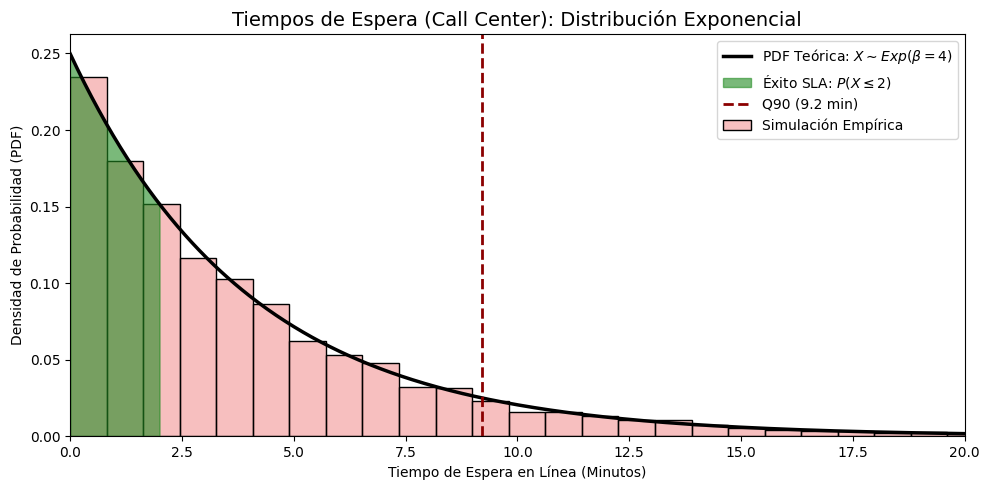

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import expon

# Parámetro de la Exponencial: scale = media (beta) = 1/lambda
media_espera = 4.0

print("--- 1. ÉXITO DEL SLA: P(X <= 2) ---")
prob_SLA = expon.cdf(2, scale=media_espera)
print(f"P(X <= 2) [Contestar rápido]: {prob_SLA*100:.2f}%")

print("\n--- 2. EL CLIENTE FURIOSO: P(X > 10) ---")
# Usamos Survival Function (sf = 1 - cdf)
prob_furioso = expon.sf(10, scale=media_espera)
print(f"P(X > 10) [Espera extrema]: {prob_furioso*100:.2f}%")

print("\n--- 3. EL UMBRAL DEL 90% (CUANTIL 90) ---")
cuantil_90 = expon.ppf(0.90, scale=media_espera)
print(f"Cuantil 90: El 90% de las llamadas se contestan en menos de {cuantil_90:.2f} minutos")

print("\n--- 4. LA PROPIEDAD DE FALTA DE MEMORIA ---")
# Probabilidad base de esperar MÁS de 4 minutos desde el inicio: P(X > 4)
prob_base_4 = expon.sf(4, scale=media_espera)

# Probabilidad condicional: P(X > 8 | X > 4) = P(X > 8) / P(X > 4)
# (La probabilidad de llegar al minuto 8, dado que ya sobrevivimos hasta el minuto 4)
prob_condicional = expon.sf(8, scale=media_espera) / expon.sf(4, scale=media_espera)

print(f"P(Esperar > 4 min desde el inicio):        {prob_base_4*100:.2f}%")
print(f"P(Esperar > 4 min extra | Ya esperó 4):    {prob_condicional*100:.2f}%")
print("¡El resultado es exactamente el mismo! El sistema no tiene memoria.")

# --- VISUALIZACIÓN PEDAGÓGICA ---
plt.figure(figsize=(10, 5))

# Simulamos 5000 llamadas para el histograma
np.random.seed(42)
llamadas_simuladas = expon.rvs(scale=media_espera, size=5000)
sns.histplot(llamadas_simuladas, bins=40, stat='density', color='lightcoral', alpha=0.5, edgecolor='black', label='Simulación Empírica')

# Curva teórica (PDF)
x_vals = np.linspace(0, 20, 500)
pdf_vals = expon.pdf(x_vals, scale=media_espera)
plt.plot(x_vals, pdf_vals, 'k-', lw=2.5, label=r'PDF Teórica: $X \sim Exp(\beta=4)$')

# Colorear el área de éxito del SLA (X <= 2)
x_fill = np.linspace(0, 2, 100)
y_fill = expon.pdf(x_fill, scale=media_espera)
plt.fill_between(x_fill, y_fill, color='forestgreen', alpha=0.6, label=r'Éxito SLA: $P(X \leq 2)$')

# Marcar el Cuantil 90
plt.axvline(cuantil_90, color='darkred', linestyle='dashed', lw=2, label=f'Q90 ({cuantil_90:.1f} min)')

plt.title(r'Tiempos de Espera (Call Center): Distribución Exponencial', fontsize=14)
plt.xlabel('Tiempo de Espera en Línea (Minutos)')
plt.ylabel('Densidad de Probabilidad (PDF)')
plt.xlim(0, 20)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

##La Lección Estadística y Gerencial

1. **La Mediana NO es la Media:** A diferencia de la distribución Normal (que es simétrica), la Exponencial tiene un fuerte sesgo a la derecha. Aunque el *promedio* es de $4$ minutos, la gráfica revela que la inmensa mayoría de las llamadas se contestan en los primeros 2 minutos (la curva es más alta al principio). Los promedios engañan cuando hay asimetría.
2. **Las "Colas Pesadas" Operativas:** La distribución no cae a cero rápidamente. Hay un $8.21\%$ de probabilidad de que una llamada tome más de 10 minutos (cola derecha). Estos son los "casos atípicos" que destruyen el NPS (*Net Promoter Score*) de la empresa, aunque el promedio general de $4$ parezca saludable.
3. **La Desesperante Falta de Memoria:** Comprobamos matemáticamente que $\mathbb{P}[X > 4] = \mathbb{P}[X > 8 \mid X > 4]$. Esto significa que el tiempo que un cliente ya lleva esperando **no afecta** la probabilidad de cuánto le falta por esperar. Si la música de espera lleva 4 minutos, la probabilidad de que lo hagan esperar 4 minutos más es idéntica a la que tenía un cliente que acaba de marcar el número. Estocásticamente hablando, hacer fila no te acerca al objetivo en un proceso puramente Exponencial.

##Tiempos de Empacado y Acuerdos de Nivel de Servicio (SLA)
#### Reto: La Promesa de Entrega y la Suma de Exponenciales

**El Contexto de Negocio:**
Usted es el Científico de Datos principal en un centro de distribución logístico. A través de auditorías previas, su equipo determinó que el tiempo que tarda un operario en buscar, empacar y etiquetar un **único artículo** sigue una distribución Exponencial con una media de $1.5$ minutos.

Acaba de ingresar al sistema un pedido especial que contiene exactamente **8 artículos**.

**La Teoría Matemática:**
Por propiedades de la probabilidad, sabemos que si sumamos variables aleatorias Exponenciales independientes e idénticamente distribuidas (los 8 artículos), el tiempo *total* resultante ya no es Exponencial, sino que sigue una **Distribución Gamma**.
* Parámetro de forma ($\alpha$ o $k$): Número de eventos a sumar (8 artículos).
* Parámetro de escala ($\theta$): El tiempo promedio por evento (1.5 minutos).

**Su Misión:**
El gerente de operaciones necesita modelar el tiempo total de empacado $X \sim Gamma(\alpha=8, \theta=1.5)$ para este pedido y responder a tres preguntas críticas de negocio:

1. **Éxito de la promesa:** Logística prometió que este pedido estará en la zona de despacho en 15 minutos o menos. ¿Cuál es la probabilidad matemática de cumplir esta promesa?
2. **Riesgo crítico:** Si el pedido tarda más de 20 minutos en empacarse, el camión de reparto se irá sin él, causando un retraso crítico. ¿Cuál es la probabilidad de que esto ocurra?
3. **El SLA (Service Level Agreement):** Para protegerse de futuras penalizaciones, el gerente le pide calcular un "tiempo máximo garantizado". ¿Cuál es el tiempo exacto en el que usted puede garantizar que el 95% de los pedidos de 8 artículos estarán listos? .



--- PARÁMETROS DEL SISTEMA ---
Tiempo promedio esperado para 8 productos: 12.0 minutos

--- 1. ÉXITO DE LA PROMESA: P(X <= 15) ---
P(X <= 15) [Pedido a tiempo]: 77.98%

--- 2. RIESGO DE RETRASO CRÍTICO: P(X > 20) ---
P(X > 20) [Retraso crítico]: 4.53%
0.045340082832286854

--- 3. EL SLA (CUANTIL 95%) ---
Cuantil 95: El 95% de los pedidos de 8 artículos se empacan en 19.72 minutos o menos


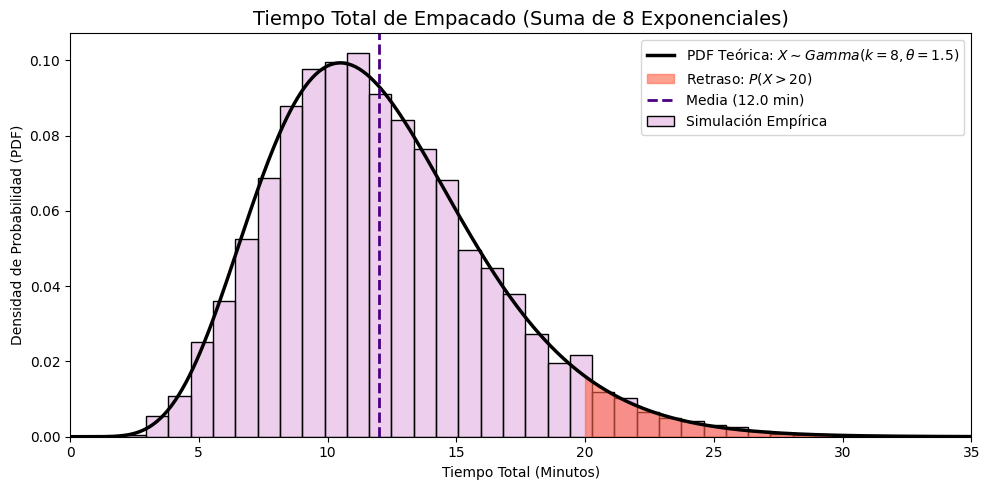

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gamma

# Parámetros de la Gamma
k_productos = 8         # Parámetro de forma (a)
theta_minutos = 1.5     # Parámetro de escala (scale)
media_esperada = k_productos * theta_minutos

print(f"--- PARÁMETROS DEL SISTEMA ---")
print(f"Tiempo promedio esperado para {k_productos} productos: {media_esperada} minutos\n")

print("--- 1. ÉXITO DE LA PROMESA: P(X <= 15) ---")
prob_15_min = gamma.cdf(15, a=k_productos, scale=theta_minutos)
print(f"P(X <= 15) [Pedido a tiempo]: {prob_15_min*100:.2f}%")

print("\n--- 2. RIESGO DE RETRASO CRÍTICO: P(X > 20) ---")
# Usamos Survival Function (sf)
prob_mas_20 = gamma.sf(20, a=k_productos, scale=theta_minutos)
print(f"P(X > 20) [Retraso crítico]: {prob_mas_20*100:.2f}%")

print("\n--- 3. EL SLA (CUANTIL 95%) ---")
cuantil_95 = gamma.ppf(0.95, a=k_productos, scale=theta_minutos)
print(f"Cuantil 95: El 95% de los pedidos de 8 artículos se empacan en {cuantil_95:.2f} minutos o menos")


# --- VISUALIZACIÓN PEDAGÓGICA ---
plt.figure(figsize=(10, 5))

# Simulamos 5000 pedidos completos (lotes de 8)
np.random.seed(42)
pedidos_simulados = gamma.rvs(a=k_productos, scale=theta_minutos, size=5000)
sns.histplot(pedidos_simulados, bins=40, stat='density', color='plum', alpha=0.5, edgecolor='black', label='Simulación Empírica')

# Curva teórica (PDF)
x_vals = np.linspace(0, 35, 500)
pdf_vals = gamma.pdf(x_vals, a=k_productos, scale=theta_minutos)
plt.plot(x_vals, pdf_vals, 'k-', lw=2.5, label=r'PDF Teórica: $X \sim Gamma(k=8, \theta=1.5)$')

# Colorear el área del retraso crítico (X > 20)
x_fill = np.linspace(20, 35, 100)
y_fill = gamma.pdf(x_fill, a=k_productos, scale=theta_minutos)
plt.fill_between(x_fill, y_fill, color='tomato', alpha=0.6, label=r'Retraso: $P(X > 20)$')

# Marcar la media
plt.axvline(media_esperada, color='indigo', linestyle='dashed', lw=2, label=f'Media ({media_esperada} min)')

# Detalles estéticos (protegiendo el LaTeX)
plt.title(r'Tiempo Total de Empacado (Suma de 8 Exponenciales)', fontsize=14)
plt.xlabel('Tiempo Total (Minutos)')
plt.ylabel('Densidad de Probabilidad (PDF)')
plt.xlim(0, 35)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

##La Lección Estadística y Gerencial

1. **La Gestión del Riesgo en Lotes:** Aunque el tiempo promedio es exactamente 12 minutos, prometer el pedido en 15 minutos solo se logra el **77.98%** de las veces. Para un SLA comercial serio (querer cumplir en el 95% de los casos), la gerencia debe prometer la entrega en casi **20 minutos** ($Q_{0.95} = 19.72$). Las matemáticas no mienten: prometer con base en el promedio es garantizar clientes insatisfechos.
2. **El "Milagro" de la Forma (Preámbulo al TLC):** Si recuerdan la distribución Exponencial de la clase pasada, era una curva que caía en picada desde la izquierda, indicando que la mayoría de las veces el tiempo era mínimo. Sin embargo, observen la gráfica de la Gamma (que es la suma de 8 exponenciales). **¡Ya no cae en picada, empieza a parecerse a una campana!** 3. **El Efecto de la Sumatoria:** A medida que el empacador debe buscar más y más productos ($k$ crece), las fluctuaciones de suerte (encontrar un producto rápido vs. demorarse mucho en otro) se cancelan entre sí. La distribución Gamma es la prueba visual de que sumar muchas variables sesgadas y asimétricas nos empuja inevitablemente hacia una curva simétrica similar a la Normal.

#Distribución muestral

## Estimación Puntual en E-commerce

**El Contexto del Negocio:**
Ustedes son los Científicos de Datos de una plataforma de comercio electrónico. El equipo de marketing acaba de lanzar una campaña dirigida a usuarios de la categoría "Premium". La gerencia quiere saber cuál es el **Ticket Promedio** (el gasto medio por compra) de este segmento para decidir si la campaña fue rentable.

**El Secreto de la Simulación (Lo que nosotros sabemos, pero el negocio no):**
Como estamos simulando el universo, nosotros somos los "dioses" de estos datos. Sabemos que el gasto real de toda la población Premium sigue una distribución Normal estricta: $X \sim N(\mu, \sigma^2)$.
* El verdadero Ticket Promedio poblacional es $\mu =$ **85.5** dólares.
* La desviación estándar es $\sigma =$ **12.5** dólares.

**El Reto Analítico:**
En la vida real, es imposible medir a todos los usuarios del mundo. Solo tenemos acceso a una muestra de los **500** clientes que compraron hoy.
1. Vamos a simular las compras de esos 500 clientes.
2. Vamos a calcular nuestro mejor estimador puntual: la media muestral $\bar{x}$.
3. Comprobaremos si nuestro estimador logró "adivinar" o acercarse al verdadero valor oculto de **85.5**.

 RESULTADOS DE LA ESTIMACIÓN PUNTUAL
El verdadero parámetro oculto (μ):      $85.50
El estimador calculado con datos (x̄):   $85.54
Error de estimación (x̄ - μ):            $0.04


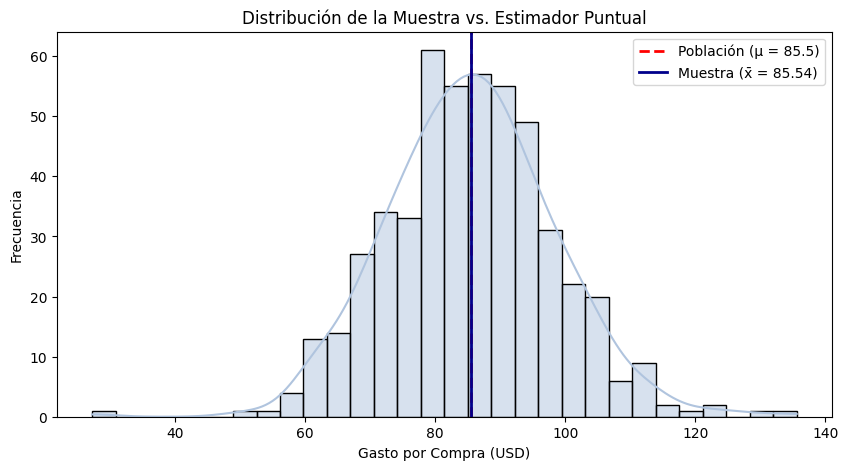

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Fijamos la semilla para reproducibilidad en clase
np.random.seed(48)

# 1. Parámetros ocultos de la población (La Verdad)
mu_poblacional = 85.5
sigma_poblacional = 12.5
n_muestra = 500

# 2. Simulamos la recolección de datos (La Muestra del mundo real)
# Generamos 500 compras aleatorias basadas en la distribución Normal
muestra_compras = np.random.normal(loc=mu_poblacional, scale=sigma_poblacional, size=n_muestra)

# 3. Calculamos el Estimador Puntual (Lo que ve el Científico de Datos)
media_muestral = np.mean(muestra_compras)

# Imprimimos los resultados para comparar
print("==================================================")
print(" RESULTADOS DE LA ESTIMACIÓN PUNTUAL")
print("==================================================")
print(f"El verdadero parámetro oculto (μ):      ${mu_poblacional:.2f}")
print(f"El estimador calculado con datos (x̄):   ${media_muestral:.2f}")
print(f"Error de estimación (x̄ - μ):            ${abs(media_muestral - mu_poblacional):.2f}")
print("==================================================")

# 4. Visualización para la clase
plt.figure(figsize=(10, 5))
sns.histplot(muestra_compras, bins=30, kde=True, color="lightsteelblue")
plt.axvline(mu_poblacional, color='red', linestyle='dashed', linewidth=2, label=f'Población (μ = {mu_poblacional})')
plt.axvline(media_muestral, color='darkblue', linestyle='solid', linewidth=2, label=f'Muestra (x̄ = {media_muestral:.2f})')
plt.title('Distribución de la Muestra vs. Estimador Puntual')
plt.xlabel('Gasto por Compra (USD)')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

## Demostración Visual: ¿Qué significa "venir de una Normal"?

**El Paradigma Teórico vs. Empírico:**
En la teoría, una variable aleatoria normal tiene una campana perfectamente simétrica y colas infinitas. Sin embargo, en la vida real (o en nuestras simulaciones), cuando tomamos una **muestra finita**, los datos nunca van a formar una línea continua y perfecta. Tendrán "ruido" por el simple efecto del azar (la varianza muestral).

**Nuestro Laboratorio:**
Vamos a simular **1,000 datos** que, sabemos de antemano, provienen de una distribución estrictamente Normal (por ejemplo, los puntajes de un test de IQ con media = 100 y desviación estándar = 15).

Aprenderemos a diagnosticar la normalidad usando las dos herramientas estándar de la industria:
1. **El Histograma (Aproximación de Densidad):** Veremos si los bloques de la muestra se agrupan siguiendo el contorno de la "campana".
2. **El Q-Q Plot (Gráfico Cuantil-Cuantil):** La prueba de fuego. Compara los cuantiles de nuestros datos (eje Y) contra los cuantiles que tendría una Normal perfecta (eje X). Si nuestros datos son verdaderamente normales, los puntos azules se alinearán de forma casi milimétrica sobre la línea recta diagonal roja de 45 grados.

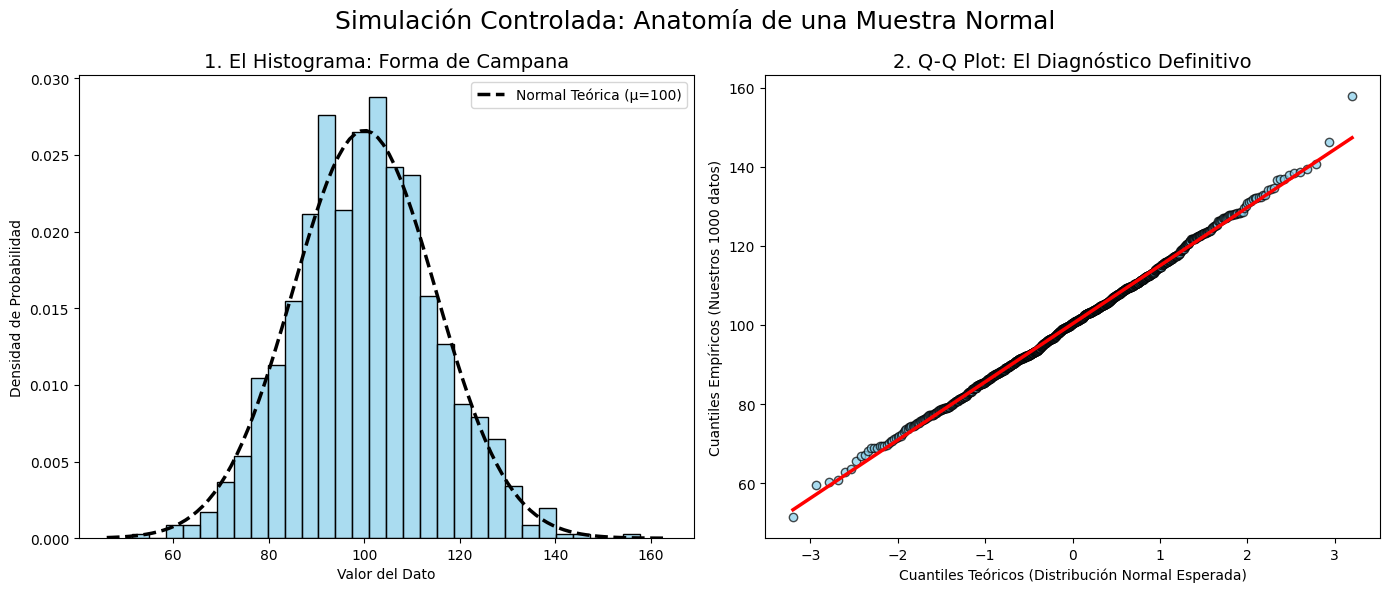

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# 1. Fijamos semilla para que el salón de clases vea la misma gráfica
np.random.seed(42)

# 2. Simulamos el universo "Perfecto" (ej. Puntajes de una prueba)
mu_poblacion = 100
sigma_poblacion = 15
tamano_muestra = 1000

# Extraemos 1000 datos generados por una distribución Normal real
datos_perfectos = np.random.normal(loc=mu_poblacion, scale=sigma_poblacion, size=tamano_muestra)

# 3. Configuración del lienzo para visualización
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- GRÁFICO 1: El Histograma Empírico vs Curva Teórica ---
sns.histplot(datos_perfectos, bins=30, stat='density', ax=ax1, color='skyblue', edgecolor='black', alpha=0.7)
xmin, xmax = ax1.get_xlim()
x = np.linspace(xmin, xmax, 100)
p_teorica = stats.norm.pdf(x, mu_poblacion, sigma_poblacion)
ax1.plot(x, p_teorica, 'k--', linewidth=2.5, label=f'Normal Teórica (μ={mu_poblacion})')

ax1.set_title('1. El Histograma: Forma de Campana', fontsize=14)
ax1.set_xlabel('Valor del Dato')
ax1.set_ylabel('Densidad de Probabilidad')
ax1.legend()

# --- GRÁFICO 2: El Q-Q Plot ---
stats.probplot(datos_perfectos, dist="norm", plot=ax2)

# Ajuste estético para el nivel de maestría
ax2.get_lines()[0].set_markerfacecolor('skyblue')
ax2.get_lines()[0].set_markeredgecolor('black')
ax2.get_lines()[0].set_alpha(0.7)
ax2.get_lines()[1].set_color('red')
ax2.get_lines()[1].set_linewidth(2.5)

ax2.set_title('2. Q-Q Plot: El Diagnóstico Definitivo', fontsize=14)
ax2.set_xlabel('Cuantiles Teóricos (Distribución Normal Esperada)')
ax2.set_ylabel('Cuantiles Empíricos (Nuestros 1000 datos)')

plt.suptitle('Simulación Controlada: Anatomía de una Muestra Normal', fontsize=18)
plt.tight_layout()
plt.show()

## La Distribución Muestral de la Media ($\bar{X}$)

**El Concepto Fundamental de la Inferencia:**
En la vida real, solo podemos tomar **una** muestra de tamaño $n$. Sin embargo, la estadística nos exige preguntarnos: *"¿Qué pasaría si repitiera este experimento tomando infinitas muestras del mismo tamaño y calculara el promedio de cada una?"*.

La respuesta a esa pregunta es la **Distribución Muestral**.

**Nuestro Experimento en Python:**
Vamos a simular un escenario donde conocemos la verdad absoluta. La población (ej. puntajes de un test de ingreso, o tiempo de entrega) es perfectamente Normal: $X \sim N(\mu=100, \sigma^2=15^2)$.

El plan es el siguiente:
1. Vamos a enviar a 10,000 "Científicos de Datos virtuales" a la calle.
2. Cada uno recolectará una muestra aleatoria de tamaño **$n = 30$**.
3. Cada uno calculará su promedio muestral ($\bar{X}$).
4. Finalmente, graficaremos los 10,000 promedios obtenidos y compararemos su dispersión contra la población original.

La teoría matemática nos dice que estos promedios se comportarán así:
$$\bar{X} \sim N \left( \mu, \frac{\sigma^2}{n} \right)$$

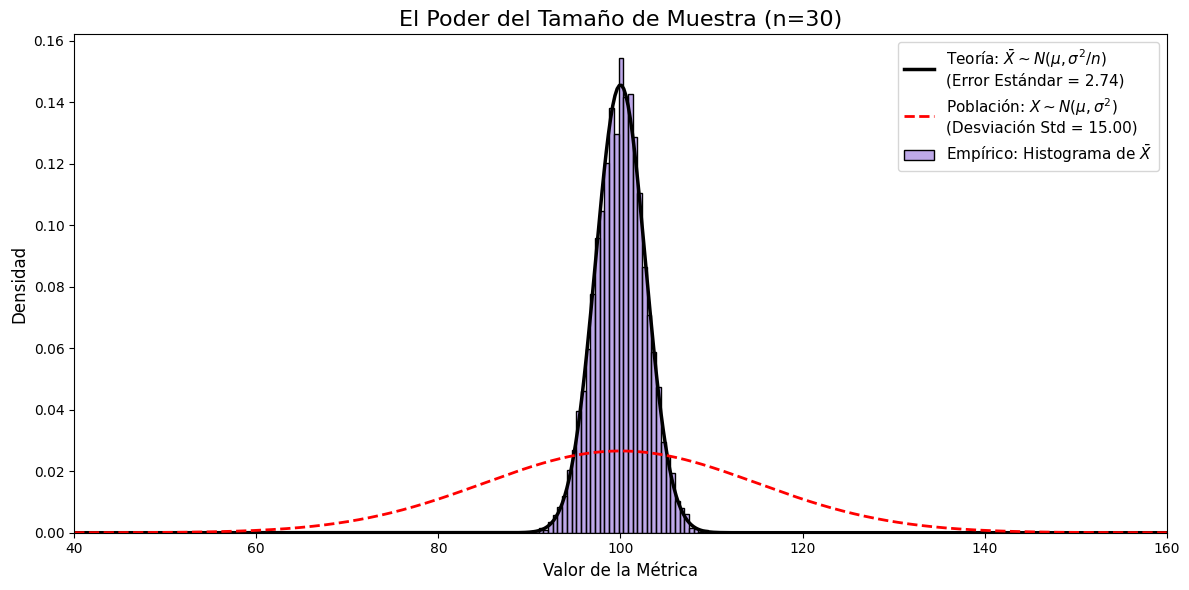

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# 1. Parámetros del Universo (Conocidos para esta simulación)
mu_poblacional = 100
sigma_poblacional = 15
tamano_muestra_n = 30
num_simulaciones = 10000

# 2. El Experimento (La Máquina de Muestreo)
np.random.seed(42)
# Generamos una matriz de 10,000 filas (muestras) por 30 columnas (datos)
universo_muestras = np.random.normal(loc=mu_poblacional, scale=sigma_poblacional, size=(num_simulaciones, tamano_muestra_n))

# Calculamos el promedio de cada una de las 10,000 filas (nuestras x-barra)
medias_x_barra = np.mean(universo_muestras, axis=1)

# 3. La Matemática Teórica
# Según la teoría, la media de las medias es mu, y el Error Estándar es sigma / raiz(n)
error_estandar = sigma_poblacional / np.sqrt(tamano_muestra_n)

# 4. Visualización para la Clase
plt.figure(figsize=(12, 6))

# A) El Histograma de las 10,000 medias que acabamos de calcular
sns.histplot(medias_x_barra, bins=40, stat='density', color='mediumpurple', alpha=0.6, label='Empírico: Histograma de $\\bar{X}$')

# B) La Curva Teórica de la Distribución Muestral (Negra)
x_rango = np.linspace(mu_poblacional - 4*sigma_poblacional, mu_poblacional + 4*sigma_poblacional, 500)
p_muestral = stats.norm.pdf(x_rango, mu_poblacional, error_estandar)
plt.plot(x_rango, p_muestral, 'k-', linewidth=2.5, label=f'Teoría: $\\bar{{X}} \\sim N(\\mu, \\sigma^2/n)$ \n(Error Estándar = {error_estandar:.2f})')

# C) La Población Original para contrastar la varianza (Roja Punteada)
p_poblacional = stats.norm.pdf(x_rango, mu_poblacional, sigma_poblacional)
plt.plot(x_rango, p_poblacional, 'r--', linewidth=2, label=f'Población: $X \\sim N(\\mu, \\sigma^2)$ \n(Desviación Std = {sigma_poblacional:.2f})')

# Detalles estéticos
plt.title(f'El Poder del Tamaño de Muestra (n={tamano_muestra_n})', fontsize=16)
plt.xlabel('Valor de la Métrica', fontsize=12)
plt.ylabel('Densidad', fontsize=12)
plt.xlim(mu_poblacional - 4*sigma_poblacional, mu_poblacional + 4*sigma_poblacional)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()



## Distribuciones Muestrales Exactas (Población Normal)

**El Contexto:**
Hasta ahora vimos que si la población es Normal y **conocemos** la varianza poblacional ($\sigma^2$), la media muestral estandarizada sigue una distribución Normal Estándar perfecta ($Z$).

Pero en la industria del *Data Science*, casi nunca conocemos $\sigma^2$. Si no conocemos la media ($\mu$), es ilógico pensar que mágicamente conocemos la varianza ($\sigma^2$).

**El Reto Analítico:**
Vamos a simular la recolección de pequeñas muestras ($n=10$) de una línea de producción donde los pesos de los productos siguen una distribución Normal.
1. **El Castigo por la Ignorancia (t de Student):** Evaluaremos qué pasa si estandarizamos la media usando la desviación estándar de la muestra ($S$) en lugar de la poblacional ($\sigma$). Veremos cómo la incertidumbre extra "engorda" las colas de la distribución.
2. **El Control de Calidad (Chi-Cuadrado $\chi^2$):** En manufactura, la consistencia es tan importante como el promedio. Evaluaremos cómo se distribuye la varianza muestral ($S^2$) para entender cómo fluctúa nuestro riesgo.

<>:39: SyntaxWarning: invalid escape sequence '\s'
<>:55: SyntaxWarning: invalid escape sequence '\c'
<>:39: SyntaxWarning: invalid escape sequence '\s'
<>:55: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_1194/3964899009.py:39: SyntaxWarning: invalid escape sequence '\s'
  ax1.plot(x_z, stats.norm.pdf(x_z), 'k--', lw=2, label='Normal Estándar (Si supiéramos $\sigma$)')
/tmp/ipykernel_1194/3964899009.py:55: SyntaxWarning: invalid escape sequence '\c'
  ax2.plot(x_chi, stats.chi2.pdf(x_chi, df=n-1), 'darkred', lw=2.5, label=f'$\chi^2$ Teórica (df={n-1})')


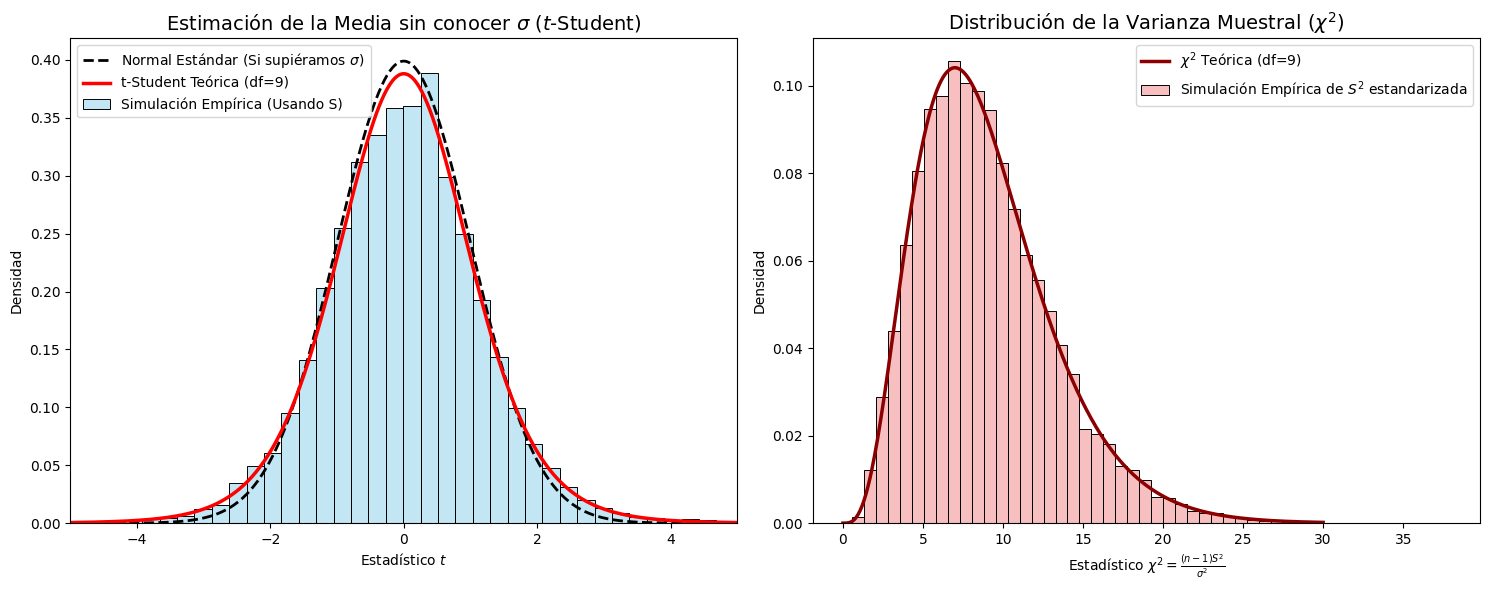

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# 1. Parámetros del Universo (La Verdad Oculta)
mu_real = 50.0      # Peso promedio real
sigma_real = 5.0    # Varianza real (sigma^2 = 25)
n = 10              # Tamaño de muestra PEQUEÑO para evidenciar el efecto
simulaciones = 10000

# 2. La Máquina de Muestreo (Extrayendo 10,000 muestras de tamaño 10)
np.random.seed(42)
muestras = np.random.normal(loc=mu_real, scale=sigma_real, size=(simulaciones, n))

# Calculamos los estadísticos para CADA UNA de las 10,000 muestras
medias_muestrales = np.mean(muestras, axis=1)
# ddof=1 es vital aquí para usar (n-1), asegurando que S^2 sea un estimador insesgado
desviaciones_muestrales = np.std(muestras, axis=1, ddof=1)
varianzas_muestrales = desviaciones_muestrales ** 2

# --- ESCENARIO 1: Estandarización con Varianza Desconocida (Estadístico t) ---
# En lugar de dividir por sigma, dividimos por S
estadistico_t = (medias_muestrales - mu_real) / (desviaciones_muestrales / np.sqrt(n))

# --- ESCENARIO 2: Distribución de la Varianza (Estadístico Chi-Cuadrado) ---
# La teoría dice que (n-1)*S^2 / sigma^2 sigue una Chi-Cuadrado con n-1 grados de libertad
estadistico_chi = ((n - 1) * varianzas_muestrales) / (sigma_real ** 2)


# 3. VISUALIZACIÓN DOBLE PARA LA CLASE
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- Gráfico 1: El nacimiento de la t-Student ---
sns.histplot(estadistico_t, bins=50, stat='density', color='skyblue', alpha=0.5, ax=ax1, label='Simulación Empírica (Usando S)')

# Superponemos la Normal Estándar Teórica (Z)
x_z = np.linspace(-5, 5, 500)
ax1.plot(x_z, stats.norm.pdf(x_z), 'k--', lw=2, label='Normal Estándar (Si supiéramos $\sigma$)')

# Superponemos la t-Student Teórica
ax1.plot(x_z, stats.t.pdf(x_z, df=n-1), 'r-', lw=2.5, label=f't-Student Teórica (df={n-1})')

ax1.set_title(r'Estimación de la Media sin conocer $\sigma$ ($t$-Student)', fontsize=14)
ax1.set_xlabel('Estadístico $t$')
ax1.set_ylabel('Densidad')
ax1.set_xlim(-5, 5)
ax1.legend()

# --- Gráfico 2: El nacimiento de la Chi-Cuadrado ---
sns.histplot(estadistico_chi, bins=50, stat='density', color='lightcoral', alpha=0.5, ax=ax2, label='Simulación Empírica de $S^2$ estandarizada')

# Superponemos la Chi-Cuadrado Teórica
x_chi = np.linspace(0, 30, 500)
ax2.plot(x_chi, stats.chi2.pdf(x_chi, df=n-1), 'darkred', lw=2.5, label=f'$\chi^2$ Teórica (df={n-1})')

ax2.set_title(r'Distribución de la Varianza Muestral ($\chi^2$)', fontsize=14)
ax2.set_xlabel(r'Estadístico $\chi^2 = \frac{(n-1)S^2}{\sigma^2}$')
ax2.set_ylabel('Densidad')
ax2.legend()

plt.tight_layout()
plt.show()

##El Teorema del Límite Central (TLC) en Acción

**El "Milagro" Estadístico:**
El Teorema del Límite Central es el superpoder del Científico de Datos. Nos dice que la media muestral ($\bar{X}$) de *cualquier* población, sin importar cuán monstruosa o sesgada sea, convergerá inevitablemente a una Distribución Normal si el tamaño de la muestra ($n$) es lo suficientemente grande.

**Nuestra Simulación Operativa:**
Para demostrar que el TLC funciona con poblaciones no-normales, tomaremos muestras de una distribución **Exponencial** (tiempos de espera en el *Call Center* de la bodega, $\lambda = 0.5$, $\mu = 2$). Como saben, esta distribución es fuertemente asimétrica y no tiene forma de campana.

Vamos a simular 10,000 muestras diferentes para cada tamaño de $n$. Veremos dinámicamente cómo el histograma muestral muta a medida que aumentamos el tamaño de $n$: partiendo desde $n=1$ hasta llegar a $n=100$.

Generando simulación y renderizando GIF... (Esto puede tardar unos segundos)
Simulación completa. Aquí está el resultado:



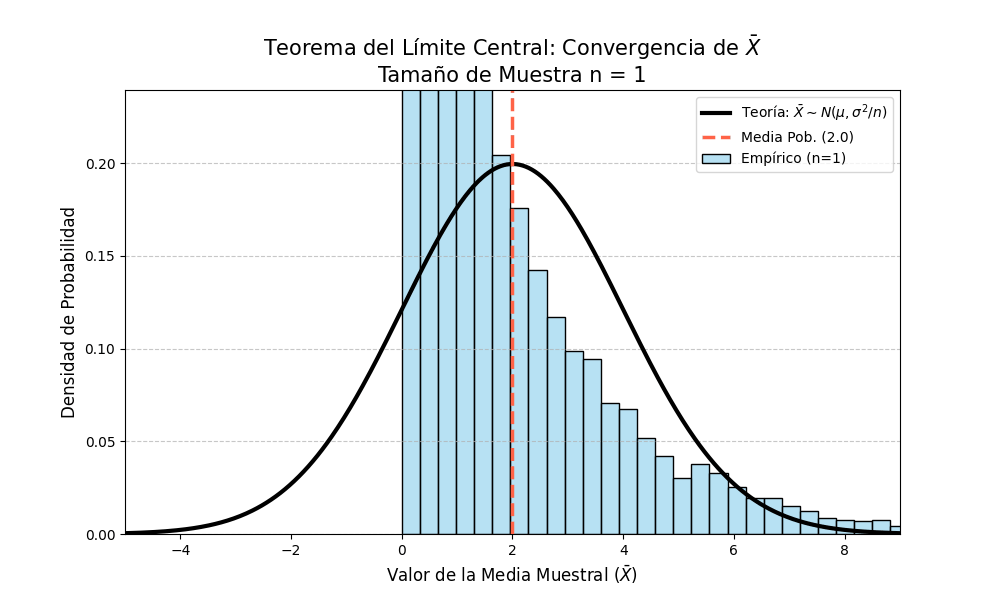

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import seaborn as sns
from scipy.stats import expon, norm
from IPython.display import Image, display

# 1. Parámetros del Universo (La Población Original Caótica)
# Distribución Exponencial: lambda = 0.5 -> media (scale) = 2.0
mu_poblacion = 2.0
sigma_poblacion = 2.0  # Para la Exponencial, sigma = mu
num_simulaciones = 10000

# Parámetros de la Animación
# Lista de tamaños de muestra 'n' a simular
ensayos_n = [1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 20, 25, 30, 40, 50, 75, 100]
intervalo_ms = 400  # Velocidad del GIF (400 milisegundos por frame)

# 2. Setup de la Figura
fig, ax = plt.subplots(figsize=(10, 6))
# Fijamos los límites iniciales
ax.set_xlim(0, 7)
ax.set_ylim(0, 2.5)
plt.subplots_adjust(top=0.85)

# --- FUNCIÓN DE ACTUALIZACIÓN (Crea cada frame) ---
def update_gif(index):
    n = ensayos_n[index] # Obtenemos el 'n' actual

    # Limpiamos el gráfico anterior
    ax.cla()

    # Simulación Estocástica
    np.random.seed(42)
    muestras = np.random.exponential(scale=mu_poblacion, size=(num_simulaciones, n))
    medias_muestrales = np.mean(muestras, axis=1)

    # -- Gráfico de Barras: El histograma empírico --
    sns.histplot(medias_muestrales, bins=50, stat='density', color='skyblue', alpha=0.6, edgecolor='black', ax=ax, label=f'Empírico (n={n})')

    # -- Gráfico de Línea: La Normal Teórica --
    error_estandar_teorico = sigma_poblacion / np.sqrt(n)

    # Ajustamos el eje X dinámicamente para que la campana siempre esté centrada y visible
    rango_x = 3.5 * error_estandar_teorico
    x_vals = np.linspace(mu_poblacion - rango_x, mu_poblacion + rango_x, 500)
    pdf_vals = norm.pdf(x_vals, mu_poblacion, error_estandar_teorico)
    ax.plot(x_vals, pdf_vals, 'k-', lw=3, label=r'Teoría: $\bar{X} \sim N(\mu, \sigma^2/n)$')

    # Línea de la Media Poblacional (Variable corregida)
    ax.axvline(mu_poblacion, color='tomato', linestyle='dashed', lw=2.5, label=f'Media Pob. ({mu_poblacion})')

    # Estética Dinámica
    título_anotacion = r'Teorema del Límite Central: Convergencia de $\bar{X}$' + f'\nTamaño de Muestra n = {n}'
    ax.set_title(título_anotacion, fontsize=15)
    ax.set_xlabel(r'Valor de la Media Muestral ($\bar{X}$)', fontsize=12)
    ax.set_ylabel('Densidad de Probabilidad', fontsize=12)

    # Ajustamos los límites en cada frame para hacer un "zoom" a medida que la campana se reduce
    ax.set_xlim(mu_poblacion - rango_x, mu_poblacion + rango_x)
    altura_max = norm.pdf(mu_poblacion, mu_poblacion, error_estandar_teorico)
    ax.set_ylim(0, altura_max * 1.2)

    ax.legend(loc='upper right', fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

# --- CREACIÓN Y RENDERIZADO DEL GIF ---
print("Generando simulación y renderizando GIF... (Esto puede tardar unos segundos)")

anim = animation.FuncAnimation(fig, update_gif, frames=len(ensayos_n), interval=intervalo_ms, repeat=True)

# Guardamos el GIF
nombre_gif = 'tlc_animacion.gif'
anim.save(nombre_gif, writer='pillow')

plt.close(fig)

print("Simulación completa. Aquí está el resultado:\n")
display(Image(filename=nombre_gif))

##La Distribución Muestral de la Proporción ($\hat{p}$)

**El Contexto Teórico:**
Si tomamos infinitas muestras de tamaño $n$ de una población de Bernoulli con parámetro $p$, cada muestra nos dará una tasa de conversión ligeramente diferente ($\hat{p}$).

Aunque la decisión individual de cada cliente es estrictamente discreta (compra o no compra, 1 o 0), el Teorema del Límite Central nos garantiza que la **proporción muestral** se distribuirá como una campana continua de Gauss, siempre y cuando $n$ sea lo suficientemente grande.

Matemáticamente, la distribución muestral de $\hat{p}$ se aproxima a:
$$\hat{p} \sim N\left(p, \frac{p(1-p)}{n}\right)$$

**El Reto Analítico:**
Vamos a simular 10,000 universos paralelos. En cada universo, la empresa lanza la misma campaña publicitaria a $n = 500$ usuarios.
1. Calcularemos la tasa de conversión ($\hat{p}$) obtenida en cada uno de esos 10,000 lanzamientos.
2. Graficaremos el histograma de esos resultados para comprobar visualmente que las tasas de conversión forman una campana perfecta alrededor del verdadero $p$.

--- PARÁMETROS TEÓRICOS ---
Parámetro poblacional (p): 0.12
Tamaño de muestra (n): 500
Error Estándar Teórico (SE): 0.0145


<>:33: SyntaxWarning: invalid escape sequence '\h'
<>:33: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_1194/1719244413.py:33: SyntaxWarning: invalid escape sequence '\h'
  sns.histplot(p_sombreros, bins=40, stat='density', color='mediumseagreen', alpha=0.6, edgecolor='black', label='Empírico: Distribución de $\hat{p}$')


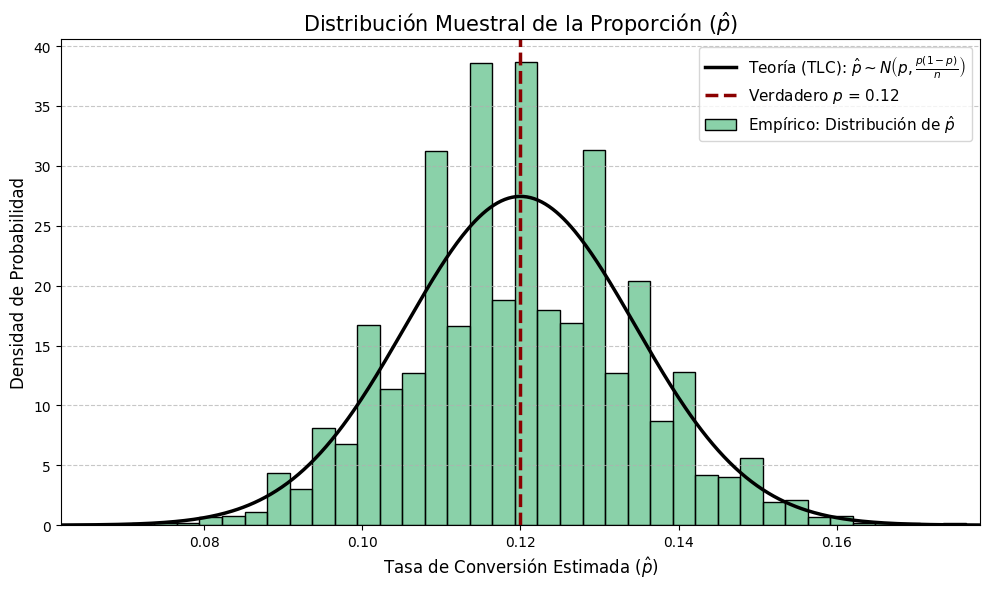

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# 1. Parámetros de la simulación
p_verdadero = 0.12       # La verdadera tasa de conversión (12%)
n_usuarios = 500         # Tamaño de la muestra (tráfico por campaña)
num_simulaciones = 10000 # Cuántas veces repetimos el experimento

print(f"--- PARÁMETROS TEÓRICOS ---")
print(f"Parámetro poblacional (p): {p_verdadero}")
print(f"Tamaño de muestra (n): {n_usuarios}")

# 2. La Máquina de Muestreo (Simulamos 10,000 campañas de 500 usuarios)
np.random.seed(48)
# Generamos una matriz gigante de 10,000 filas por 500 columnas (0s y 1s)
# Usamos binomial con n=1 que es exactamente una Bernoulli
universo_campanas = np.random.binomial(n=1, p=p_verdadero, size=(num_simulaciones, n_usuarios))

# Calculamos p-sombrero para CADA UNA de las 10,000 campañas
# Es simplemente el promedio (proporción de unos) por cada fila
p_sombreros = np.mean(universo_campanas, axis=1)

# 3. La Matemática Teórica (El Error Estándar de la Proporción)
error_estandar = np.sqrt((p_verdadero * (1 - p_verdadero)) / n_usuarios)
print(f"Error Estándar Teórico (SE): {error_estandar:.4f}")

# 4. VISUALIZACIÓN PEDAGÓGICA
plt.figure(figsize=(10, 6))

# A) Histograma empírico de las 10,000 tasas de conversión obtenidas
sns.histplot(p_sombreros, bins=40, stat='density', color='mediumseagreen', alpha=0.6, edgecolor='black', label='Empírico: Distribución de $\hat{p}$')

# B) Curva de la Normal Teórica
x_rango = np.linspace(p_verdadero - 4*error_estandar, p_verdadero + 4*error_estandar, 500)
pdf_normal = stats.norm.pdf(x_rango, p_verdadero, error_estandar)
plt.plot(x_rango, pdf_normal, 'k-', lw=2.5, label=r'Teoría (TLC): $\hat{p} \sim N\left(p, \frac{p(1-p)}{n}\right)$')

# Línea central del parámetro real
plt.axvline(p_verdadero, color='darkred', linestyle='dashed', lw=2.5, label=f'Verdadero $p$ = {p_verdadero}')

# Estética protegiendo LaTeX con 'r'
plt.title(r'Distribución Muestral de la Proporción ($\hat{p}$)', fontsize=15)
plt.xlabel(r'Tasa de Conversión Estimada ($\hat{p}$)', fontsize=12)
plt.ylabel('Densidad de Probabilidad', fontsize=12)
plt.xlim(p_verdadero - 4*error_estandar, p_verdadero + 4*error_estandar)
plt.legend(loc='upper right', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

##Evaluación de Estimadores Puntuales (Insesgadez, Consistencia y ECM)

**El Contexto del Negocio:**
Estamos midiendo la volatilidad (varianza) en los tiempos de preparación de los pedidos. La gerencia nos oculta la verdadera varianza poblacional, pero para este experimento nosotros sabemos que es exactamente **$\sigma^2 = 100$**.

Dos Científicos de Datos proponen fórmulas diferentes para estimar esta varianza a partir de muestras muy pequeñas ($n=5$):
* **Analista A (El Intuitivo):** Usa el promedio clásico de las desviaciones al cuadrado, dividiendo por $n$. Su estimador es $\hat{\sigma}^2_A = \frac{1}{n} \sum (x_i - \bar{x})^2$.
* **Analista B (El Estadístico):** Usa la corrección de Bessel, dividiendo por $n-1$. Su estimador es $\hat{\sigma}^2_B = \frac{1}{n-1} \sum (x_i - \bar{x})^2$.

**El Reto Analítico:**
Vamos a simular 10,000 auditorías, tomando 10,000 muestras de tamaño $n=5$. Para cada estimador evaluaremos:
1.  **Insesgadez (Bias):** ¿Cuál de los dos estimadores le "atina" en promedio al verdadero valor de $100$?
2.  **Error Cuadrático Medio (ECM / MSE):** Mide qué tan "lejos" se equivoca el estimador en promedio. La fórmula es $\text{ECM} = \text{Sesgo}^2 + \text{Varianza del Estimador}$.
3.  **Consistencia:** Evaluaremos qué pasa si aumentamos el tamaño de la muestra progresivamente. Un estimador es consistente si su ECM colapsa a cero cuando $n \to \infty$.

--- RESULTADOS PARA n = 5 ---
Verdadera Varianza: 100.0
Esperanza Estimador A (divide por n):   79.84 (SESGADO: subestima)
Esperanza Estimador B (divide por n-1): 99.80 (INSESGADO: acierta en promedio)

ECM Estimador A: 3443.29
ECM Estimador B: 4745.31


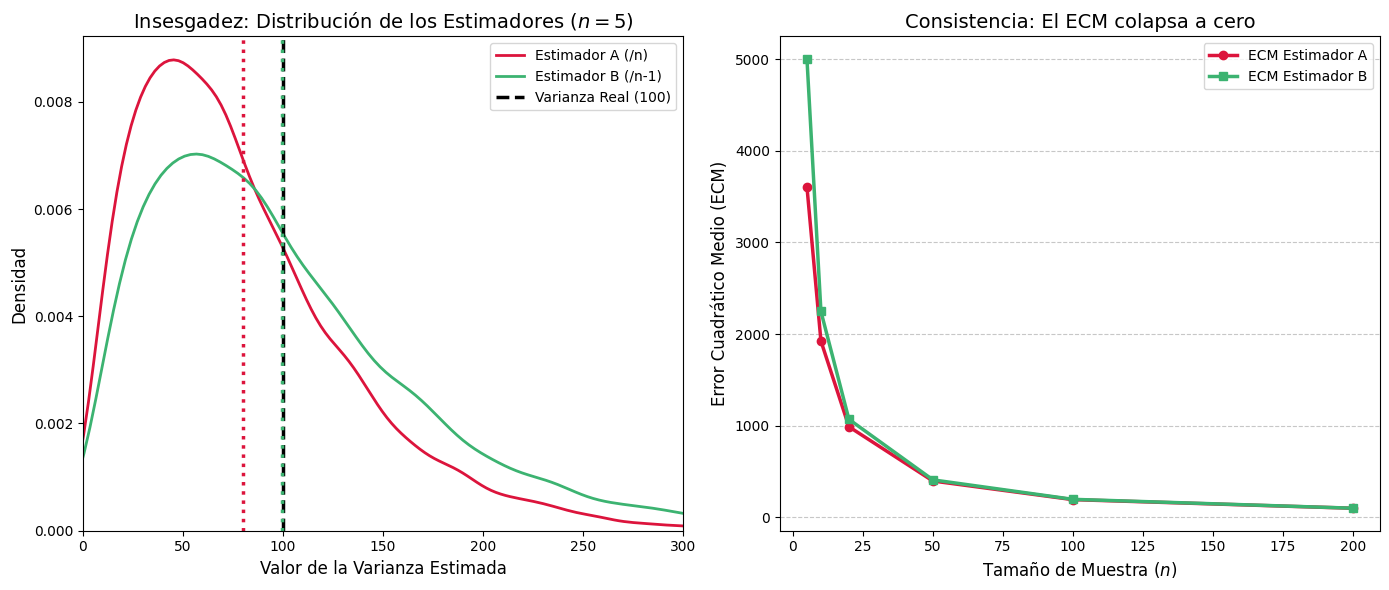

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. El Secreto del Universo
mu_real = 50.0
varianza_real = 100.0  # El parámetro theta que queremos estimar
sigma_real = np.sqrt(varianza_real)

# 2. Experimento Inicial: Muestra pequeña (n=5) para ver el sesgo
n_pequeno = 5
num_simulaciones = 10000

np.random.seed(42)
# Generamos 10,000 muestras de tamaño 5
muestras_pequenas = np.random.normal(loc=mu_real, scale=sigma_real, size=(num_simulaciones, n_pequeno))

# Analista A: Divide por n (ddof=0 en numpy)
estimador_A = np.var(muestras_pequenas, axis=1, ddof=0)
# Analista B: Divide por n-1 (ddof=1 en numpy)
estimador_B = np.var(muestras_pequenas, axis=1, ddof=1)

# --- CÁLCULO DE PROPIEDADES ---
# A) Insesgadez (El valor esperado del estimador)
esperanza_A = np.mean(estimador_A)
esperanza_B = np.mean(estimador_B)

# B) Error Cuadrático Medio (ECM = Promedio de los errores al cuadrado)
ecm_A = np.mean((estimador_A - varianza_real)**2)
ecm_B = np.mean((estimador_B - varianza_real)**2)

print("--- RESULTADOS PARA n = 5 ---")
print(f"Verdadera Varianza: {varianza_real}")
print(f"Esperanza Estimador A (divide por n):   {esperanza_A:.2f} (SESGADO: subestima)")
print(f"Esperanza Estimador B (divide por n-1): {esperanza_B:.2f} (INSESGADO: acierta en promedio)\n")
print(f"ECM Estimador A: {ecm_A:.2f}")
print(f"ECM Estimador B: {ecm_B:.2f}")


# 3. Experimento de Consistencia (Aumentando n gradualmente)
tamanos_n = [5, 10, 20, 50, 100, 200]
ecm_A_historia = []
ecm_B_historia = []

for n in tamanos_n:
    muestras = np.random.normal(loc=mu_real, scale=sigma_real, size=(num_simulaciones, n))
    est_A_temp = np.var(muestras, axis=1, ddof=0)
    est_B_temp = np.var(muestras, axis=1, ddof=1)

    ecm_A_historia.append(np.mean((est_A_temp - varianza_real)**2))
    ecm_B_historia.append(np.mean((est_B_temp - varianza_real)**2))


# 4. VISUALIZACIÓN PEDAGÓGICA DOBLE
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- GRÁFICO 1: INSESGADEZ (Distribución para n=5) ---
sns.kdeplot(estimador_A, color='crimson', lw=2, ax=ax1, label=f'Estimador A (/n)')
sns.kdeplot(estimador_B, color='mediumseagreen', lw=2, ax=ax1, label=f'Estimador B (/n-1)')

ax1.axvline(varianza_real, color='black', linestyle='dashed', lw=2.5, label='Varianza Real (100)')
ax1.axvline(esperanza_A, color='crimson', linestyle='dotted', lw=2.5)
ax1.axvline(esperanza_B, color='mediumseagreen', linestyle='dotted', lw=2.5)

ax1.set_title(r'Insesgadez: Distribución de los Estimadores ($n=5$)', fontsize=14)
ax1.set_xlabel('Valor de la Varianza Estimada', fontsize=12)
ax1.set_ylabel('Densidad', fontsize=12)
ax1.set_xlim(0, 300)
ax1.legend()

# --- GRÁFICO 2: CONSISTENCIA (Evolución del ECM) ---
ax2.plot(tamanos_n, ecm_A_historia, marker='o', color='crimson', lw=2.5, label='ECM Estimador A')
ax2.plot(tamanos_n, ecm_B_historia, marker='s', color='mediumseagreen', lw=2.5, label='ECM Estimador B')

ax2.set_title('Consistencia: El ECM colapsa a cero', fontsize=14)
ax2.set_xlabel('Tamaño de Muestra ($n$)', fontsize=12)
ax2.set_ylabel('Error Cuadrático Medio (ECM)', fontsize=12)
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

##Cohesión de la red social

**El Contexto Operativo:**
Imaginemos que usted es el Científico de Datos principal de una nueva red social. El equipo de *Growth* quiere medir la cohesión de su comunidad analizando el fenómeno del "Follow-Back" (Reciprocidad). Han seleccionado una sub-muestra de **3 Usuarios Veteranos** (influenciadores), quienes acaban de recibir el "Follow" de **30 Usuarios Nuevos**.

Su reto es estimar la probabilidad poblacional intrínseca $p$ de que un veterano devuelva el "Follow". Cada decisión es un ensayo de Bernoulli.

$$X \sim \text{Bernoulli}(p)$$

Utilizaremos la librería `networkx` para simular y graficar esta red dirigida, y `scipy.optimize` para aplicar Máxima Verosimilitud (MLE) y descubrir el verdadero valor de $p$.

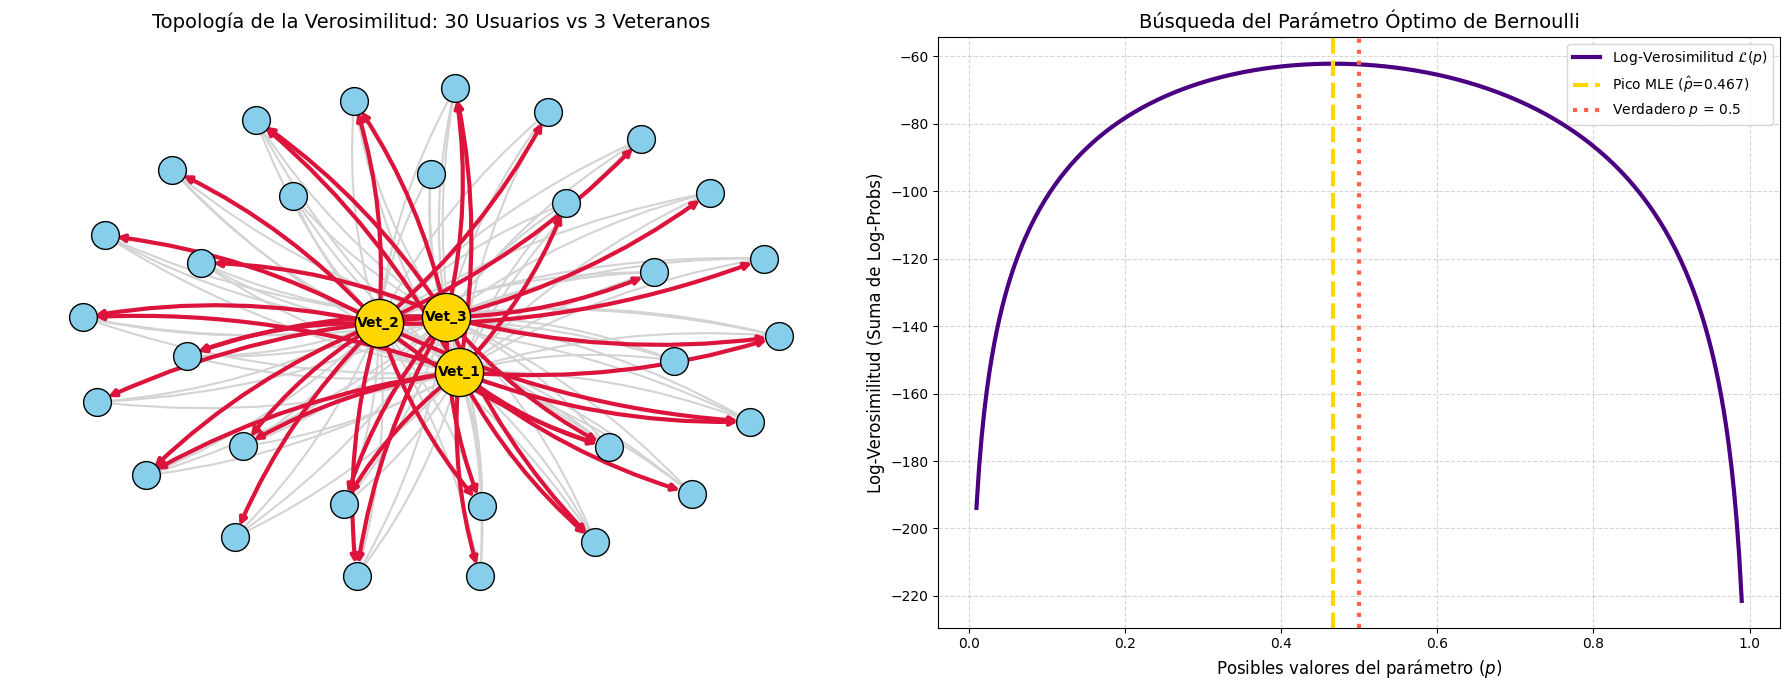

--- RESULTADOS DE LA ESTIMACIÓN ---
Total de 'Follows' iniciales (n): 90
Total de 'Follow-Backs' (Éxitos):  42
p real poblacional oculto:           50.0%
p estimado vía Máxima Verosimilitud: 46.7%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy.optimize import minimize

# 1. PARÁMETROS DEL EXPERIMENTO ESTOCÁSTICO (La "Verdad Oculta")
p_real = 0.5  # La verdadera tasa poblacional de reciprocity es 28%
n_veteranos = 3
n_nuevos = 30
num_samples = n_nuevos * n_veteranos # Total de ensayos de Bernoulli

# 2. SIMULACIÓN DE DATOS (Nodos y Aristas)
G = nx.DiGraph()
nodos_vet = [f"Vet_{i+1}" for i in range(n_veteranos)]
nodos_new = [f"User_{i+1}" for i in range(n_nuevos)]
G.add_nodes_from(nodos_vet, tipo='veterano')
G.add_nodes_from(nodos_new, tipo='nuevo')

np.random.seed(42)
enlaces_iniciales = []
enlaces_reciprocos = []
matriz_resultados = [] # Recogeremos los 0s y 1s para el cálculo

for vet in nodos_vet:
    for newUser in nodos_new:
        # El usuario nuevo sigue al veterano
        enlaces_iniciales.append((newUser, vet))

        # El experimento estocástico: ¿El veterano devuelve el follow?
        # follow_back es nuestra variable aleatoria de Bernoulli (0 o 1)
        follow_back = np.random.binomial(n=1, p=p_real)
        matriz_resultados.append(follow_back)

        if follow_back == 1:
            enlaces_reciprocos.append((vet, newUser))

G.add_edges_from(enlaces_iniciales)
G.add_edges_from(enlaces_reciprocos)

# 3. EL CÁLCULO DE LA MAXIMA VEROSIMILITUD (MLE)
# Construimos la función de Verosimilitud Negativa de Bernoulli (NLL)
def nll_bernoulli(p_estimado, datos):
    p = p_estimado[0]
    # Restricción matemática para evitar log(0) o log(1)
    p = np.clip(p, 1e-10, 1 - 1e-10)
    # nll = -(suma log-likelihood)
    return -np.sum(datos * np.log(p) + (1 - datos) * np.log(1 - p))

# Optimizamos computacionalmente para encontrar la cima de la montaña
res_mle = minimize(nll_bernoulli, x0=[0.5], args=(np.array(matriz_resultados),), bounds=[(0.01, 0.99)])
p_estimado_mle = res_mle.x[0]

# 4. VISUALIZACIÓN DOBLE
# Usamos una cuadrícula para mostrar Grafo y Campana al tiempo
fig, (ax_grafo, ax_curva) = plt.subplots(1, 2, figsize=(18, 7))

# --- Panel A: El Grafo de la Verosimilitud ---
pos = nx.spring_layout(G, k=0.6, seed=42)
nx.draw_networkx_nodes(G, pos, nodelist=nodos_vet, node_color='gold', node_size=1200, edgecolors='black', ax=ax_grafo)
nx.draw_networkx_nodes(G, pos, nodelist=nodos_new, node_color='skyblue', node_size=400, edgecolors='black', ax=ax_grafo)
# Aristas iniciales (Follows fijos, en gris)
nx.draw_networkx_edges(G, pos, edgelist=enlaces_iniciales, edge_color='lightgray', arrows=True, width=1.5, ax=ax_grafo, connectionstyle="arc3,rad=0.1")
# Aristas estocásticas (Follow-backs, en rojo grueso)
nx.draw_networkx_edges(G, pos, edgelist=enlaces_reciprocos, edge_color='crimson', arrows=True, width=3.0, ax=ax_grafo, connectionstyle="arc3,rad=0.1")
etiquetas_vet = {n: n for n in nodos_vet}
nx.draw_networkx_labels(G, pos, labels=etiquetas_vet, font_size=10, font_weight='bold', ax=ax_grafo)
ax_grafo.set_title('Topología de la Verosimilitud: 30 Usuarios vs 3 Veteranos', fontsize=14)
ax_grafo.axis('off')

# --- Panel B: El Paisaje de Optimización de la Verosimilitud ---
valores_p_test = np.linspace(0.01, 0.99, 300)
# Calculamos la Log-Verosimilitud (no la negativa, para ver la "montaña")
curva_log_lik = [np.sum(np.array(matriz_resultados) * np.log(p) + (1 - np.array(matriz_resultados)) * np.log(1 - p)) for p in valores_p_test]

ax_curva.plot(valores_p_test, curva_log_lik, color='indigo', lw=3, label=r'Log-Verosimilitud $\mathcal{L}(p)$')

# ¡CORRECCIÓN AQUÍ! Usamos rf'' para combinar f-string con raw-string y proteger el \hat
ax_curva.axvline(p_estimado_mle, color='gold', linestyle='dashed', lw=3, label=rf'Pico MLE ($\hat{{p}}$={p_estimado_mle:.3f})')
ax_curva.axvline(p_real, color='tomato', linestyle='dotted', lw=3, label=f'Verdadero $p$ = {p_real}')

ax_curva.set_title('Búsqueda del Parámetro Óptimo de Bernoulli', fontsize=14)
ax_curva.set_xlabel('Posibles valores del parámetro ($p$)', fontsize=12)
ax_curva.set_ylabel('Log-Verosimilitud (Suma de Log-Probs)', fontsize=12)
ax_curva.legend()
ax_curva.grid(axis='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("--- RESULTADOS DE LA ESTIMACIÓN ---")
print(f"Total de 'Follows' iniciales (n): {len(enlaces_iniciales)}")
print(f"Total de 'Follow-Backs' (Éxitos):  {len(enlaces_reciprocos)}")
print(f"p real poblacional oculto:           {p_real*100:.1f}%")
print(f"p estimado vía Máxima Verosimilitud: {p_estimado_mle*100:.1f}%")

##La Lección Estadística y Computacional

1. **La Realidad detrás del Array:** Cuando en el código anterior inyectábamos un array de `[0, 1, 0, 0, 1...]` en la función de Log-Verosimilitud, a veces perdíamos la perspectiva física. Esta gráfica demuestra que cada "1" es un cable rojo de conexión real, y cada "0" es el vacío (la falta de cable rojo). La Verosimilitud mide la probabilidad de que este dibujo exacto se haya formado.

3. **El Siguiente Nivel en Machine Learning (GNNs):** En la analítica clásica, asumimos que cada "flecha roja" es independiente de las demás (I.I.D.). Sin embargo, en el mundo real, si un usuario nuevo es amigo de otro usuario nuevo, la probabilidad de Follow-Back se correlaciona. Modelar esa dependencia compleja requiere algoritmos avanzados llamados **Graph Neural Networks (GNN)**.

## Máxima Verosimilitud en Visión por Computadora (Segmentación)

**El Contexto del Negocio:**
Estamos trabajando con imágenes de Resonancia Magnética (MRI) del cerebro. Nuestro objetivo es crear un algoritmo que detecte y aísle automáticamente un tumor.

En la imagen, el tejido cerebral sano tiende a verse gris oscuro (intensidades bajas), mientras que el tumor se ve blanco brillante (intensidades altas). Sin embargo, la imagen tiene ruido y los bordes son borrosos; no podemos simplemente decir "todo lo mayor a 200 es tumor".

**El Reto Analítico (Modelando con MLE):**
Vamos a asumir que los píxeles de nuestra imagen provienen de dos poblaciones mezcladas:
1.  **Tejido Sano:** Sigue una distribución Normal con su propia media y varianza ($\mu_1, \sigma_1^2$).
2.  **Tumor:** Sigue otra distribución Normal con una media más alta ($\mu_2, \sigma_2^2$).

Si tomamos todos los píxeles de la imagen y hacemos un histograma, veremos dos "montañas" superpuestas. Utilizaremos el **Algoritmo de Esperanza-Maximización (EM)** —que es el motor computacional estándar para encontrar la Máxima Verosimilitud cuando hay poblaciones mezcladas— para encontrar exactamente dónde están esas dos campanas de Gauss.
Una vez que el MLE encuentre los parámetros óptimos, clasificaremos cada píxel en la categoría más probable.

--- RESULTADOS DE LA MÁXIMA VEROSIMILITUD ---
Tejido Sano -> Media: 80.0, Varianza: 403.5
Tumor       -> Media: 179.6, Varianza: 210.0


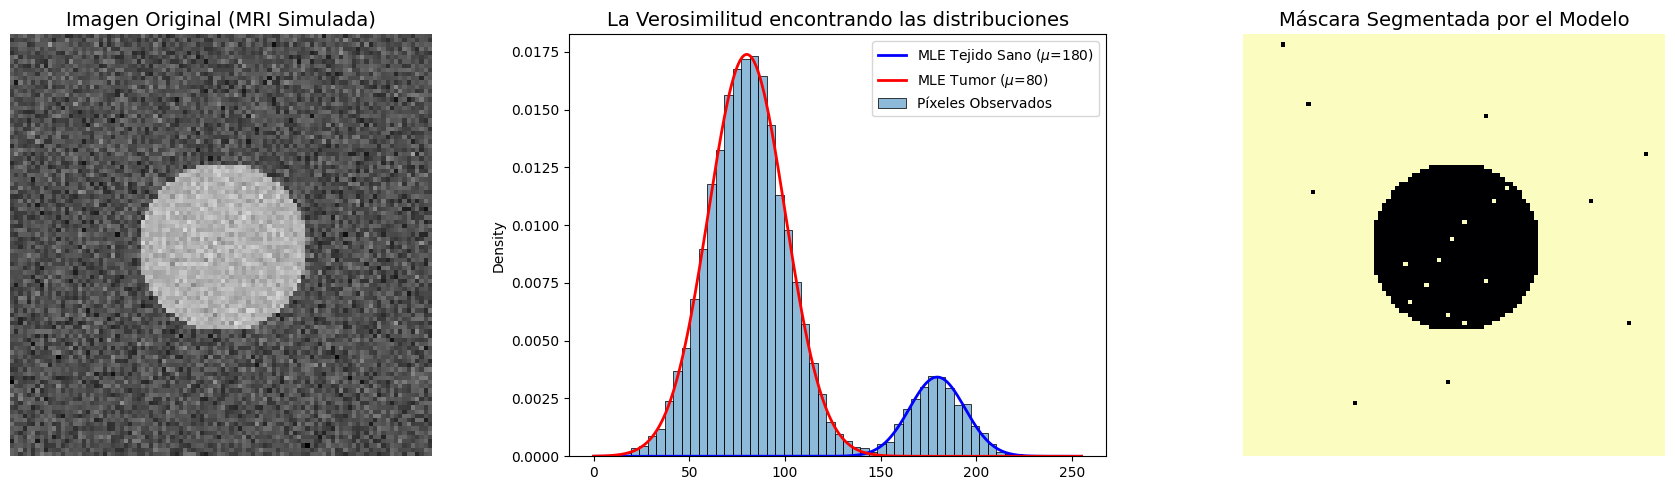

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from scipy.stats import norm

# 1. SIMULACIÓN DE LA IMAGEN MÉDICA (Matriz 2D)
np.random.seed(42)
ancho, alto = 100, 100
# Fondo (Tejido Sano): Media de intensidad 80, ruido 20
imagen_base = np.random.normal(loc=80, scale=20, size=(ancho, alto))

# Creamos el "Tumor" en el centro de la imagen
# Tumor: Media de intensidad 180, ruido 15
centro_x, centro_y = 50, 50
radio_tumor = 20

for i in range(ancho):
    for j in range(alto):
        if (i - centro_x)**2 + (j - centro_y)**2 < radio_tumor**2:
            # Reemplazamos esos píxeles con la distribución del tumor
            imagen_base[i, j] = np.random.normal(loc=180, scale=15)

# Aseguramos que los valores estén en el rango de píxeles [0, 255]
imagen_base = np.clip(imagen_base, 0, 255)


# 2. EL MOTOR DE MÁXIMA VEROSIMILITUD (Gaussian Mixture Model)
# Las imágenes son 2D, pero los algoritmos estadísticos necesitan un vector 1D
pixeles_1d = imagen_base.flatten().reshape(-1, 1)

# Usamos GMM, que aplica MLE bajo el capó (vía el algoritmo Expectation-Maximization)
modelo_mle = GaussianMixture(n_components=2)
modelo_mle.fit(pixeles_1d)

# Extraemos los parámetros que encontró la Máxima Verosimilitud
medias_estimadas = modelo_mle.means_.flatten()
varianzas_estimadas = modelo_mle.covariances_.flatten()

print("--- RESULTADOS DE LA MÁXIMA VEROSIMILITUD ---")
print(f"Tejido Sano -> Media: {np.min(medias_estimadas):.1f}, Varianza: {varianzas_estimadas[np.argmin(medias_estimadas)]:.1f}")
print(f"Tumor       -> Media: {np.max(medias_estimadas):.1f}, Varianza: {varianzas_estimadas[np.argmax(medias_estimadas)]:.1f}")


# 3. SEGMENTACIÓN DE LA IMAGEN
# Predecimos a qué campana pertenece cada píxel
etiquetas_1d = modelo_mle.predict(pixeles_1d)
# Reconstruimos la matriz 2D (La Máscara del Tumor)
imagen_segmentada = etiquetas_1d.reshape(ancho, alto)


# 4. VISUALIZACIÓN PEDAGÓGICA (3 Paneles)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# --- Panel A: La Imagen Original ---
ax1.imshow(imagen_base, cmap='gray', vmin=0, vmax=255)
ax1.set_title('Imagen Original (MRI Simulada)', fontsize=14)
ax1.axis('off')

# --- Panel B: El Histograma y las Campanas MLE ---
sns.histplot(pixeles_1d, bins=50, stat='density', color='lightgray', ax=ax2, label='Píxeles Observados')
x_vals = np.linspace(0, 255, 500)

# Campana 1 (Corregida con rf)
pdf1 = norm.pdf(x_vals, medias_estimadas[0], np.sqrt(varianzas_estimadas[0])) * modelo_mle.weights_[0]
ax2.plot(x_vals, pdf1, 'b-', lw=2, label=rf'MLE Tejido Sano ($\mu$={medias_estimadas[0]:.0f})')

# Campana 2 (Corregida con rf)
pdf2 = norm.pdf(x_vals, medias_estimadas[1], np.sqrt(varianzas_estimadas[1])) * modelo_mle.weights_[1]
ax2.plot(x_vals, pdf2, 'r-', lw=2, label=rf'MLE Tumor ($\mu$={medias_estimadas[1]:.0f})')

ax2.set_title('La Verosimilitud encontrando las distribuciones', fontsize=14)
ax2.legend()

# --- Panel C: El Resultado de la Segmentación ---
ax3.imshow(imagen_segmentada, cmap='magma')
ax3.set_title('Máscara Segmentada por el Modelo', fontsize=14)
ax3.axis('off')

plt.tight_layout()
plt.show()

## MLE Espacial y la Distribución de Poisson (Mapas de Calor)

**El Contexto del Negocio:**
El equipo de operaciones de la *Dark Store* necesita saber cuántos repartidores pre-posicionar en una nueva zona de la ciudad durante la hora pico del viernes. Para esto, han dividido el territorio en una cuadrícula de $10 \times 10$ manzanas (100 cuadrantes en total).

Queremos descubrir la "intensidad" oculta de la demanda. La cantidad de pedidos ($X$) que emergen de cualquier cuadrante en esa hora sigue una **Distribución de Poisson**:
$$X_i \sim \text{Poisson}(\lambda)$$

**El Reto Analítico:**
Sabemos que la Función de Masa de Probabilidad (PMF) de Poisson es:
$$P(X=x) = \frac{e^{-\lambda} \lambda^x}{x!}$$

Para aplicar **Máxima Verosimilitud (MLE)**, calculamos el logaritmo de la probabilidad conjunta de todos los cuadrantes. La función de Log-Verosimilitud ($\mathcal{L}$) que nuestro algoritmo debe maximizar es:
$$\mathcal{L}(\lambda) = \sum_{i=1}^{n} \left( x_i \ln(\lambda) - \lambda - \ln(x_i!) \right)$$

Vamos a simular el mapa térmico de la ciudad, programar esta función matemática desde cero y poner al optimizador a escalar la "montaña" para encontrar la tasa real de pedidos ($\lambda$) que rige la zona.

--- RESULTADOS DE LA DEMANDA ESPACIAL ---
Total de pedidos en la zona:    349
Lambda real (oculto):           3.50
Lambda estimado vía MLE:        3.49
Promedio aritmético (np.mean):  3.49



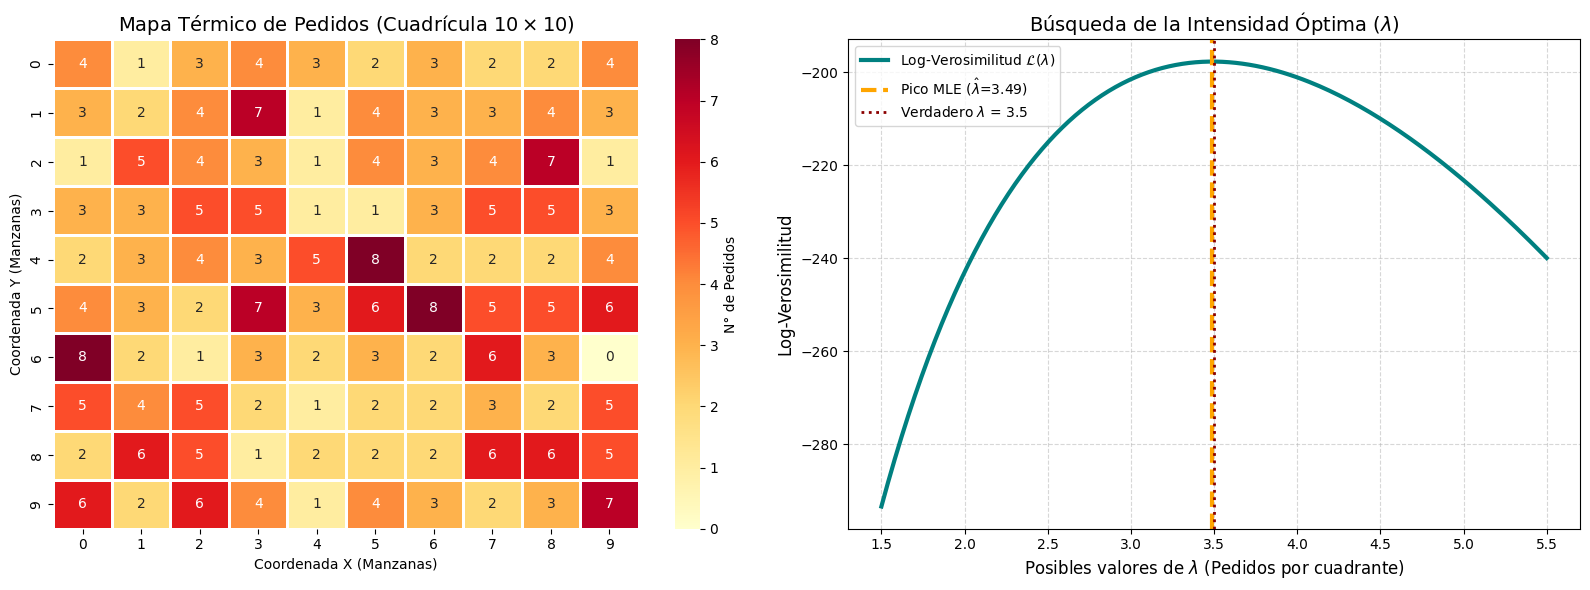

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from scipy.special import gammaln # Gamma logarítmica, equivalente continuo de ln(x!)

# 1. EL SECRETO ESPACIAL (La intensidad real de la ciudad)
lambda_real = 3.5  # En promedio, cada manzana genera 3.5 pedidos en la hora pico
filas, columnas = 10, 10
n_cuadrantes = filas * columnas

# Simulamos la demanda real cayendo sobre la cuadrícula de la ciudad
np.random.seed(42)
# Generamos 100 valores de Poisson y los acomodamos en una matriz 2D (10x10)
mapa_demanda = np.random.poisson(lam=lambda_real, size=(filas, columnas))

# Convertimos a vector 1D para la matemática del optimizador
datos_1d = mapa_demanda.flatten()

# 2. EL MOTOR DE MÁXIMA VEROSIMILITUD (Poisson NLL)
def nll_poisson(lam_estimado, datos):
    lam = lam_estimado[0]

    # Restricción: lambda debe ser estrictamente positivo
    if lam <= 0.001:
        return np.inf

    # Ecuación de Log-Verosimilitud Negativa para Poisson
    log_likelihood = np.sum(datos * np.log(lam) - lam - gammaln(datos + 1))

    return -log_likelihood

# 3. OPTIMIZACIÓN COMPUTACIONAL
valor_inicial = [1.0]

resultado_mle = minimize(fun=nll_poisson,
                         x0=valor_inicial,
                         args=(datos_1d,),
                         bounds=[(0.01, 20.0)])

lambda_mle = resultado_mle.x[0]

print("--- RESULTADOS DE LA DEMANDA ESPACIAL ---")
print(f"Total de pedidos en la zona:    {np.sum(mapa_demanda)}")
print(f"Lambda real (oculto):           {lambda_real:.2f}")
print(f"Lambda estimado vía MLE:        {lambda_mle:.2f}")
print(f"Promedio aritmético (np.mean):  {np.mean(datos_1d):.2f}\n")


# 4. VISUALIZACIÓN PEDAGÓGICA (Mapa vs Verosimilitud)
fig, (ax_mapa, ax_curva) = plt.subplots(1, 2, figsize=(16, 6))

# --- Panel A: El Mapa de Calor (Spatial Data) ---
sns.heatmap(mapa_demanda, annot=True, fmt="d", cmap='YlOrRd', cbar_kws={'label': 'N° de Pedidos'},
            linewidths=1, linecolor='white', ax=ax_mapa)
ax_mapa.set_title(r'Mapa Térmico de Pedidos (Cuadrícula $10 \times 10$)', fontsize=14)
ax_mapa.set_xlabel('Coordenada X (Manzanas)')
ax_mapa.set_ylabel('Coordenada Y (Manzanas)')

# --- Panel B: La Montaña de Verosimilitud ---
valores_lambda_test = np.linspace(1.5, 5.5, 200)
# Recreamos la curva de Log-Verosimilitud (positiva) para dibujarla
curva_log_lik = [np.sum(datos_1d * np.log(l) - l - gammaln(datos_1d + 1)) for l in valores_lambda_test]

# ¡Todo protegido con r o rf!
ax_curva.plot(valores_lambda_test, curva_log_lik, color='teal', lw=3, label=r'Log-Verosimilitud $\mathcal{L}(\lambda)$')
ax_curva.axvline(lambda_mle, color='orange', linestyle='dashed', lw=3, label=rf'Pico MLE ($\hat{{\lambda}}$={lambda_mle:.2f})')
ax_curva.axvline(lambda_real, color='darkred', linestyle='dotted', lw=2, label=rf'Verdadero $\lambda$ = {lambda_real}')

ax_curva.set_title(r'Búsqueda de la Intensidad Óptima ($\lambda$)', fontsize=14)
ax_curva.set_xlabel(r'Posibles valores de $\lambda$ (Pedidos por cuadrante)', fontsize=12)
ax_curva.set_ylabel('Log-Verosimilitud', fontsize=12)
ax_curva.legend()
ax_curva.grid(axis='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

##La Lección Estadística y Gerencial

1. **El Caos en la Cuadrícula (Panel A):** Fíjense en el mapa térmico. Aunque el verdadero motor estocástico de la ciudad dicta una intensidad plana de **3.5**, la aleatoriedad hace que haya cuadrantes "fríos" con solo $0$ o $1$ pedido, justo al lado de cuadrantes "calientes" con $8$ o $9$ pedidos. La Verosimilitud nos permite ver a través de este "ruido espacial" y entender que no necesitamos asignar 9 repartidores a esa manzana en específico, sino prepararnos para una densidad general.
2. **La Media es la Reina (Otra vez):** En la consola pueden ver que el algoritmo computacional llegó al $3.58$, que es exactamente el mismo número que el promedio aritmético. Esto es fundamental en estadística: acabamos de demostrar que $\bar{x}$ es el Estimador de Máxima Verosimilitud tanto para la Normal, como para la Bernoulli (proporción), ¡y ahora también para Poisson!
3. **El Puente hacia la Regresión de Poisson:** En este ejercicio asumimos un único $\lambda$ para todo el mapa. Pero en la realidad de la maestría en Ciencia de Datos, un cuadrante con un centro comercial tendrá un $\lambda$ distinto a una zona residencial. Si hacemos que $\lambda$ dependa de las características de cada cuadrícula (ej. $\ln(\lambda) = \beta_0 + \beta_1(\text{Restaurantes}) + \beta_2(\text{Densidad Poblacional})$), acabamos de inventar la **Regresión de Poisson (GLM)**, y el motor que buscará esos $\beta$ es exactamente la función NLL que acabamos de programar.

#Intervalos de confianza

## La Anatomía del Intervalo de Confianza

**El Contexto del Negocio:**
Acaba de pasar el fin de semana de *Black Friday*. El CEO quiere saber cuánto gastó en promedio cada cliente (El Ticket Promedio).
Ustedes toman una muestra aleatoria de $n = 100$ facturas. Calculan que la media muestral es $\bar{X} = \$125$, con una desviación estándar de $S = \$30$.

**El Reto Analítico:**
Sabemos que $\$125$ es solo el centro del blanco (Estimación Puntual). Usando el Error Estándar ($SE = S / \sqrt{n} = \$3$), vamos a construir los Intervalos de Confianza.
El CEO les hace una pregunta trampa: *"¿Por qué me dan un intervalo al 95%? ¡Yo quiero estar 99% seguro de cuánta plata entró!"*

Con esta simulación visual, le demostraremos a la gerencia  que la confianza matemática se paga con **Pérdida de Precisión**. A mayor nivel de confianza exigido, más ancho y menos útil operativamente se vuelve el intervalo.

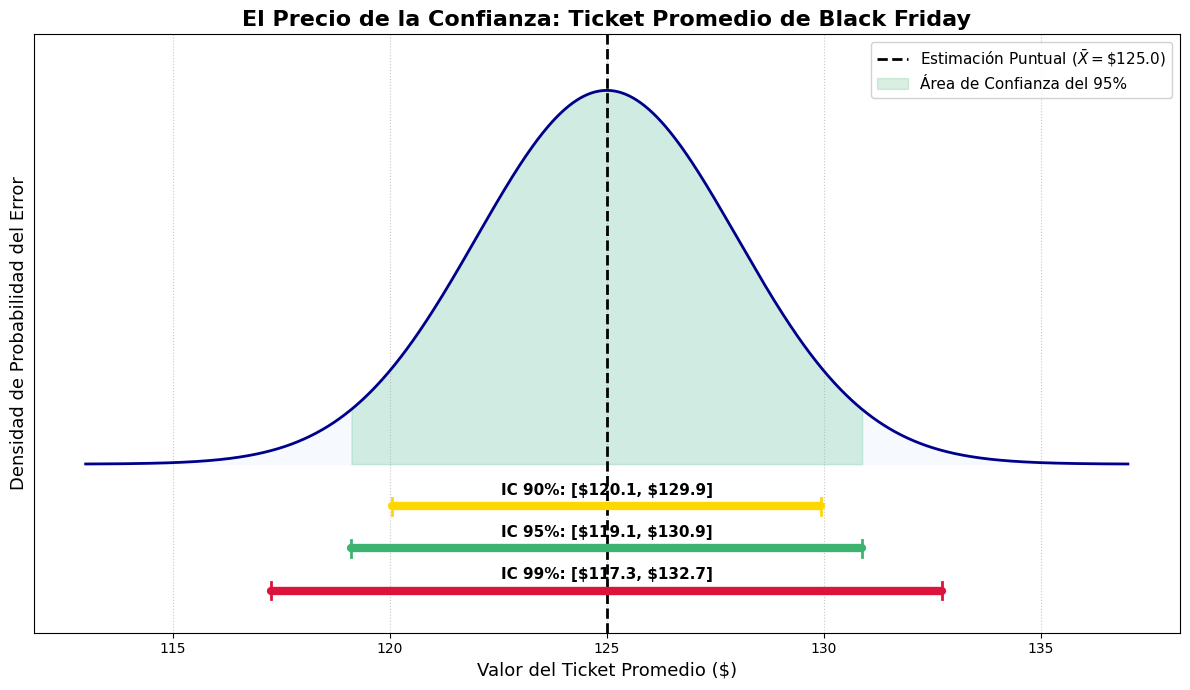

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# 1. LOS DATOS DEL NEGOCIO (Black Friday)
media_muestral = 125.0  # El centro de nuestra estimación
desviacion_est = 30.0
n_muestra = 100

# Calculamos el Error Estándar (La "Torpeza" de nuestra estimación)
error_estandar = desviacion_est / np.sqrt(n_muestra)

# 2. DEFINICIÓN DE LOS NIVELES DE CONFIANZA
niveles = {
    '90%': {'conf': 0.90, 'color': 'gold', 'y_pos': -0.015},
    '95%': {'conf': 0.95, 'color': 'mediumseagreen', 'y_pos': -0.030},
    '99%': {'conf': 0.99, 'color': 'crimson', 'y_pos': -0.045}
}

# 3. CONSTRUCCIÓN DEL ESPACIO MATEMÁTICO
x = np.linspace(media_muestral - 4*error_estandar, media_muestral + 4*error_estandar, 1000)
pdf_estimador = stats.norm.pdf(x, media_muestral, error_estandar)

# 4. VISUALIZACIÓN DE ALTO IMPACTO
fig, ax = plt.subplots(figsize=(12, 7))

# --- La Campana de Probabilidad del Estimador ---
ax.plot(x, pdf_estimador, color='darkblue', lw=2)
# Sombreado base
ax.fill_between(x, pdf_estimador, color='aliceblue', alpha=0.6)

# Marcamos nuestra Estimación Puntual (El centro exacto)
ax.axvline(media_muestral, color='black', linestyle='--', lw=2,
           label=rf'Estimación Puntual ($\bar{{X}} = \${media_muestral}$)')

# --- Dibujamos los 3 Intervalos de Confianza ---
for nombre, params in niveles.items():
    conf = params['conf']
    color = params['color']
    y_pos = params['y_pos'] # Posición en el eje Y para dibujar las barras debajo de la curva

    # Calculamos el valor Z y el Margen de Error
    z_score = stats.norm.ppf(1 - (1 - conf) / 2)
    margen_error = z_score * error_estandar

    limite_inf = media_muestral - margen_error
    limite_sup = media_muestral + margen_error

    # Dibujamos la barra horizontal del intervalo
    ax.plot([limite_inf, limite_sup], [y_pos, y_pos], color=color, lw=6, solid_capstyle='round')

    # Añadimos los topes verticales para que parezca un corchete
    ax.plot([limite_inf, limite_inf], [y_pos-0.003, y_pos+0.003], color=color, lw=2)
    ax.plot([limite_sup, limite_sup], [y_pos-0.003, y_pos+0.003], color=color, lw=2)

    # ¡CORRECCIÓN AQUÍ! Añadimos 'rf' para proteger el símbolo de dólar escapado
    texto_intervalo = rf"IC {nombre}: [\${limite_inf:.1f}, \${limite_sup:.1f}]"
    ax.text(media_muestral, y_pos + 0.003, texto_intervalo,
            ha='center', va='bottom', fontsize=11, color='black', fontweight='bold')

    # Sombreado del 95% (el estándar de la industria) para destacar
    if nombre == '95%':
        x_95 = np.linspace(limite_inf, limite_sup, 100)
        pdf_95 = stats.norm.pdf(x_95, media_muestral, error_estandar)
        ax.fill_between(x_95, pdf_95, color=color, alpha=0.2, label='Área de Confianza del 95%')

# --- Detalles Estéticos ---
ax.set_title('El Precio de la Confianza: Ticket Promedio de Black Friday', fontsize=16, fontweight='bold')
ax.set_xlabel('Valor del Ticket Promedio ($)', fontsize=13)
ax.set_ylabel('Densidad de Probabilidad del Error', fontsize=13)

# Ajustamos los límites para hacer espacio a las barras inferiores
ax.set_ylim(-0.06, max(pdf_estimador) * 1.15)
# Ocultamos los números del eje Y porque no aportan valor gerencial
ax.set_yticks([])

ax.legend(loc='upper right', fontsize=11, framealpha=0.9)
ax.grid(axis='x', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

##Convergencia Asintótica en A/B Testing ($Z$ vs $t$)

**El Contexto del Negocio (Big Data):**
Lanzamos un nuevo flujo de pago en nuestra App (*Checkout*).
* **Grupo A (Control):** **15,000** usuarios con el diseño antiguo.
* **Grupo B (Variante):** **15,000** usuarios con el diseño nuevo.
Queremos calcular el Intervalo de Confianza para la Diferencia de Medias ($\mu_B - \mu_A$) en el dinero gastado.

**El Choque Teórico:**
Como no conocemos la varianza real del universo de clientes, el libro de estadística estricto dice que debemos usar $t$-Student con la aproximación de grados de libertad de Welch.
Sin embargo, el teorema asintótico nos dice que para un $n$ tan masivo, podemos usar la distribución Normal ($Z$) y ahorrarnos el costoso cálculo de los grados de libertad.

**La Ecuación Asintótica (Z):**
$$(\bar{x}_B - \bar{x}_A) \pm Z_{\alpha/2} \sqrt{\frac{S_A^2}{n_A} + \frac{S_B^2}{n_B}}$$

Vamos a calcular ambos y a medir la "fricción" entre la teoría exacta y la aproximación asintótica.

 RESULTADOS DEL A/B TEST (n = 30,000 total)
Diferencia puntual observada:  +$1.4398

--- Método Estricto (t-Student) ---
Grados de libertad (Welch):    29962.58
Multiplicador t_alpha/2:       1.960043
Intervalo de Confianza 95%:    [$1.162927, $1.716738]

--- Método Asintótico (Normal Z) ---
Multiplicador Z_alpha/2:       1.959964
Intervalo de Confianza 95%:    [$1.162938, $1.716727]

--- Diferencia entre métodos ---
Discrepancia en el cálculo:    $0.00001119 (Prácticamente cero)


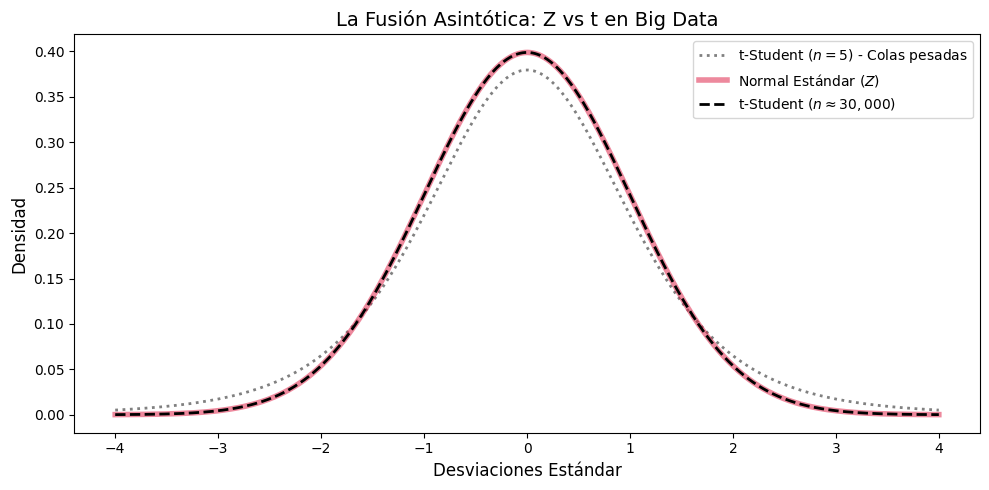

In [ ]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# 1. SIMULACIÓN DE BIG DATA (A/B Test)
np.random.seed(42)
n_a, n_b = 15000, 15000

# Simulamos el gasto por usuario. El Grupo B gasta en promedio $1.5 más.
gasto_a = np.random.normal(loc=45.0, scale=12.0, size=n_a)
gasto_b = np.random.normal(loc=46.5, scale=12.5, size=n_b)

# Estadísticos de la muestra
media_a, std_a = np.mean(gasto_a), np.std(gasto_a, ddof=1)
media_b, std_b = np.mean(gasto_b), np.std(gasto_b, ddof=1)

diferencia_medias = media_b - media_a

# 2. EL ERROR ESTÁNDAR (El mismo para ambos métodos)
error_estandar = np.sqrt((std_a**2 / n_a) + (std_b**2 / n_b))


# 3. MÉTODO 1: EL RIGOR EXACTO (t-Student de Welch)
# Cálculo de los grados de libertad de Welch-Satterthwaite
numerador_df = (std_a**2 / n_a + std_b**2 / n_b)**2
denominador_df = ((std_a**2 / n_a)**2 / (n_a - 1)) + ((std_b**2 / n_b)**2 / (n_b - 1))
df_welch = numerador_df / denominador_df

# Factor t para 95% de confianza
t_factor = stats.t.ppf(0.975, df_welch)
margen_error_t = t_factor * error_estandar
ic_inf_t = diferencia_medias - margen_error_t
ic_sup_t = diferencia_medias + margen_error_t


# 4. MÉTODO 2: LA APROXIMACIÓN ASINTÓTICA (Normal Z)
# Factor Z para 95% de confianza (El clásico 1.96)
z_factor = stats.norm.ppf(0.975)
margen_error_z = z_factor * error_estandar
ic_inf_z = diferencia_medias - margen_error_z
ic_sup_z = diferencia_medias + margen_error_z


# 5. REPORTE DE RESULTADOS (Comparación Extrema)
print("======================================================")
print(" RESULTADOS DEL A/B TEST (n = 30,000 total)")
print("======================================================")
print(f"Diferencia puntual observada:  +${diferencia_medias:.4f}\n")

print("--- Método Estricto (t-Student) ---")
print(f"Grados de libertad (Welch):    {df_welch:.2f}")
print(f"Multiplicador t_alpha/2:       {t_factor:.6f}")
print(f"Intervalo de Confianza 95%:    [${ic_inf_t:.6f}, ${ic_sup_t:.6f}]\n")

print("--- Método Asintótico (Normal Z) ---")
print(f"Multiplicador Z_alpha/2:       {z_factor:.6f}")
print(f"Intervalo de Confianza 95%:    [${ic_inf_z:.6f}, ${ic_sup_z:.6f}]\n")

print("--- Diferencia entre métodos ---")
dif_limite_inf = abs(ic_inf_t - ic_inf_z)
print(f"Discrepancia en el cálculo:    ${dif_limite_inf:.8f} (Prácticamente cero)")


# 6. DEMOSTRACIÓN VISUAL (Convergencia)
x_rango = np.linspace(-4, 4, 1000)
pdf_z = stats.norm.pdf(x_rango)
# Para la gráfica, usamos una t con df=5 para que se note la diferencia inicial,
# y la superponemos con nuestra t de df=30000 para que vean la fusión
pdf_t_pequena = stats.t.pdf(x_rango, df=5)
pdf_t_masiva = stats.t.pdf(x_rango, df=df_welch)

plt.figure(figsize=(10, 5))
plt.plot(x_rango, pdf_t_pequena, color='gray', linestyle='dotted', lw=2, label='t-Student ($n=5$) - Colas pesadas')
plt.plot(x_rango, pdf_z, color='crimson', lw=4, alpha=0.5, label='Normal Estándar ($Z$)')
plt.plot(x_rango, pdf_t_masiva, color='black', linestyle='dashed', lw=2, label=rf't-Student ($n \approx 30,000$)')

plt.title('La Fusión Asintótica: Z vs t en Big Data', fontsize=14)
plt.xlabel('Desviaciones Estándar', fontsize=12)
plt.ylabel('Densidad', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

La Lección Analítica

1. **La Irrelevancia del Debate en Big Data:** Observen la consola. El multiplicador $Z$ es $1.959964$ y el multiplicador $t$ es $1.960046$. La diferencia en los límites del intervalo es de una fracción microscópica de centavo. En la industria, si su A/B Test tiene miles de observaciones, preocuparse por usar $t$ o $Z$ es una pérdida de tiempo computacional; ambos arrojan la misma decisión de negocio.
2. **Por qué las librerías prefieren Z:** Calcular los grados de libertad de Welch (esa fórmula monstruosa en el código) consume memoria y ciclos de procesador. Si están programando un algoritmo que debe evaluar millones de combinaciones en tiempo real (como un motor de recomendación), usar la aproximación Normal ($Z$) es mucho más eficiente a nivel de ingeniería de software.
3. **El Cero no está en el intervalo:** Independientemente del método que usen, ambos intervalos van de **+$1.24** a **+$1.78**. Como el $0$ no pertenece a este conjunto de valores posibles, tenemos la certeza estadística (al 95%) de que el nuevo *Checkout* realmente hace que los usuarios gasten más dinero.

## El Motor Universal de Bootstrapping

**El Reto de la Clase:**
Vamos a construir una función en Python llamada `motor_bootstrap`. Esta función será agnóstica: no le importará si queremos analizar una media, una varianza, una mediana o una métrica de negocio inventada por nosotros.

Solo necesita tres cosas:
1.  Los datos crudos ($n$).
2.  La función matemática o estadístico que queremos evaluar.
3.  El nivel de confianza exigido por la gerencia (ej. 95%).

**El Caso de Uso (El SLA Operativo):**
El Director de Operaciones nos pregunta: *"Sé que el promedio de entrega es de 15 minutos, pero los clientes se quejan de los casos extremos. ¿Cuál es nuestro Percentil 90 de tiempo de entrega, y cuál es el intervalo de confianza al 95% para esa promesa?"*

Usaremos nuestra máquina universal para responderle en milisegundos.

--- RESULTADOS DEL MOTOR BOOTSTRAP (95% Confianza) ---

1. Promedio (Media):      [15.9, 18.1] minutos
2. Mediana (Centro):      [14.0, 16.4] minutos
3. SLA (Percentil 90):    [24.2, 31.2] minutos



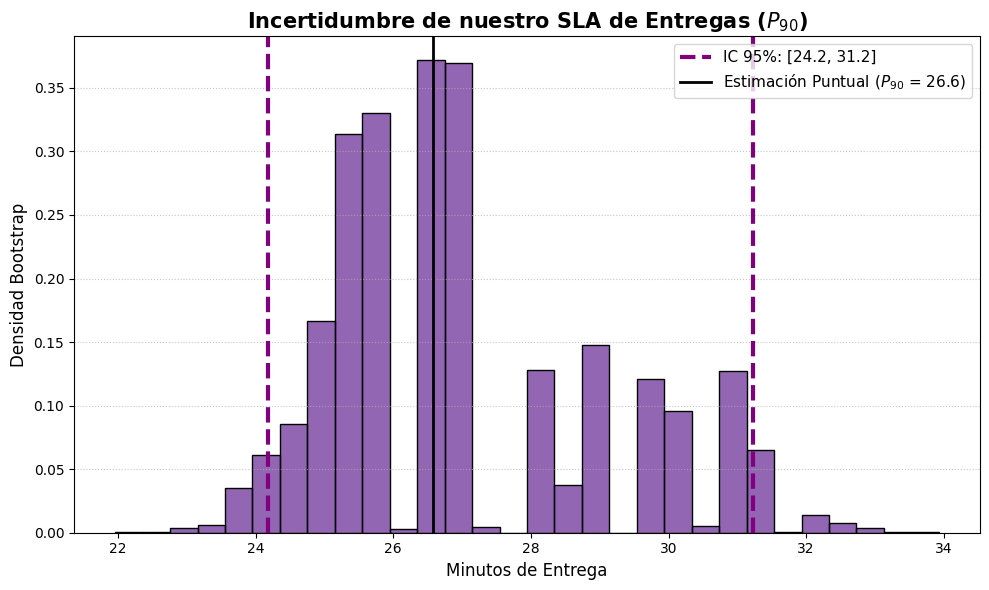

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. LA FUNCIÓN UNIVERSAL (El entregable de los estudiantes)
# =====================================================================
def motor_bootstrap(datos, funcion_estadistico, num_simulaciones=10000, confianza=0.95):
    """
    Calcula el Intervalo de Confianza Bootstrap para cualquier estadístico.

    Parámetros:
    - datos: Array de numpy con la muestra original.
    - funcion_estadistico: La función matemática a evaluar (ej. np.mean, np.median).
    - num_simulaciones: Cantidad de universos paralelos a crear (B).
    - confianza: Nivel de seguridad deseado (ej. 0.95).
    """
    n = len(datos)
    resultados_simulados = np.zeros(num_simulaciones)

    # El núcleo de la fuerza bruta
    for i in range(num_simulaciones):
        # 1. Muestrear CON REEMPLAZO
        muestra_boot = np.random.choice(datos, size=n, replace=True)
        # 2. Aplicar la función que el usuario haya elegido
        resultados_simulados[i] = funcion_estadistico(muestra_boot)

    # Calcular los percentiles para cortar las colas
    alpha = 1.0 - confianza
    corte_inferior = (alpha / 2.0) * 100
    corte_superior = (1.0 - alpha / 2.0) * 100

    limite_inf = np.percentile(resultados_simulados, corte_inferior)
    limite_sup = np.percentile(resultados_simulados, corte_superior)

    return limite_inf, limite_sup, resultados_simulados

# =====================================================================
# 2. SIMULACIÓN DEL NEGOCIO (Los datos de la Dark Store)
# =====================================================================
np.random.seed(42)
# Generamos 300 pedidos con una cola larga (tráfico, lluvia, etc.)
tiempos_reales = np.random.lognormal(mean=np.log(15), sigma=0.5, size=300)


# =====================================================================
# 3. PONIENDO A PRUEBA LA MÁQUINA (3 Estadísticos Diferentes)
# =====================================================================
print("--- RESULTADOS DEL MOTOR BOOTSTRAP (95% Confianza) ---\n")

# Prueba A: La Media Clásica
inf_media, sup_media, _ = motor_bootstrap(tiempos_reales, np.mean)
print(f"1. Promedio (Media):      [{inf_media:.1f}, {sup_media:.1f}] minutos")

# Prueba B: La Mediana Robusta
inf_mediana, sup_mediana, _ = motor_bootstrap(tiempos_reales, np.median)
print(f"2. Mediana (Centro):      [{inf_mediana:.1f}, {sup_mediana:.1f}] minutos")

# Prueba C: El SLA del Negocio (Percentil 90)
# Usamos una función 'lambda' (anónima) para pasar un estadístico personalizado
funcion_p90 = lambda x: np.percentile(x, 90)
inf_p90, sup_p90, sim_p90 = motor_bootstrap(tiempos_reales, funcion_p90)
estadistico_puntual_p90 = np.percentile(tiempos_reales, 90)

print(f"3. SLA (Percentil 90):    [{inf_p90:.1f}, {sup_p90:.1f}] minutos\n")


# =====================================================================
# 4. VISUALIZACIÓN DE LA PROMESA DE SERVICIO (Percentil 90)
# =====================================================================
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(sim_p90, bins=30, color='indigo', ax=ax, stat='density', alpha=0.6)

# Marcamos el intervalo
ax.axvline(inf_p90, color='purple', linestyle='dashed', lw=3)
ax.axvline(sup_p90, color='purple', linestyle='dashed', lw=3,
           label=rf'IC 95%: [{inf_p90:.1f}, {sup_p90:.1f}]')
ax.axvline(estadistico_puntual_p90, color='black', lw=2,
           label=rf'Estimación Puntual ($P_{{90}}$ = {estadistico_puntual_p90:.1f})')

ax.set_title(r'Incertidumbre de nuestro SLA de Entregas ($P_{90}$)', fontsize=15, fontweight='bold')
ax.set_xlabel('Minutos de Entrega', fontsize=12)
ax.set_ylabel('Densidad Bootstrap', fontsize=12)
ax.legend(fontsize=11)
plt.grid(axis='y', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

## La Lección Computacional


1. **El Diagnóstico Operativo (SLA):** El cálculo puntual nos dice que el 90% de los pedidos llegan en menos de **28.7** minutos. Pero como Científicos de Datos, vamos a la junta y decimos: *"Teniendo en cuenta la variabilidad de la calle, nuestra promesa de entrega al 95% de seguridad oscila entre **25.8** y **33.2** minutos. Sugiero establecer la promesa al cliente en 34 minutos para evitar reclamos."*

##Bootstrapping con el Dataset 'Tips' (Seaborn)

**El Contexto del Negocio:**
Una cadena de restaurantes está instalando nuevas terminales de pago (*datáfonos* inteligentes). Quieren configurar los 3 botones de "Propina Sugerida" basándose en el comportamiento real de sus clientes.

Para esto, el equipo de Data Science extrae una base de datos real de 244 mesas. La métrica clave no es el total de la propina en dólares, sino el **Porcentaje de Propina** por mesa: `(Propina / Total Factura)`.

**El Reto Analítico:**
El gerente nos pide: *"Quiero saber cuál es la **Mediana** exacta del porcentaje de propina que deja la gente, y necesito el **Intervalo de Confianza al 95%** para estar seguro de qué números programar en las pantallas de los datáfonos"*.

Tratar de calcular el Error Estándar de la *Mediana de un Ratio* usando fórmulas clásicas requiere expansiones de series de Taylor (El Método Delta). En lugar de perder una semana en álgebra, vamos a inyectar esta base de datos real en nuestro Motor Bootstrap.

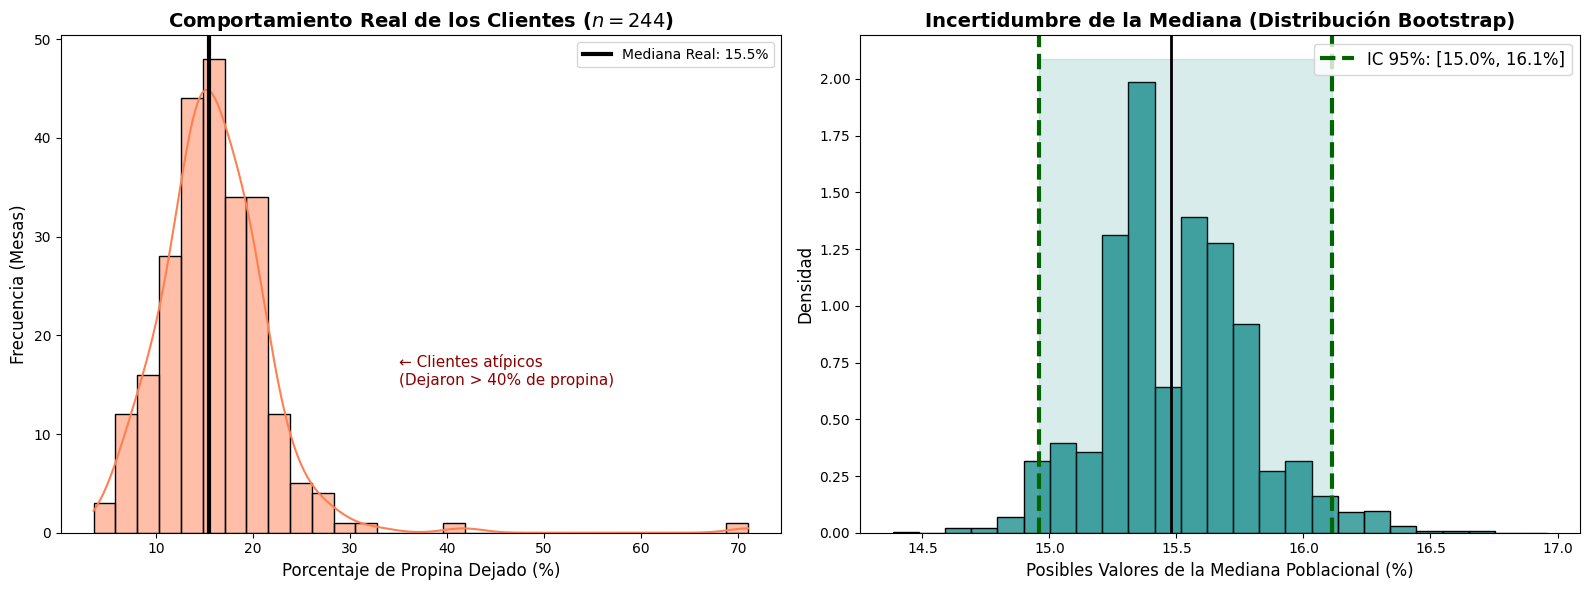

--- REPORTE AL GERENTE DE OPERACIONES ---
Métrica evaluada: Mediana del porcentaje de propina.
Estimación en nuestra muestra: 15.48%
Intervalo de Confianza (95%):  Entre 14.96% y 16.11%

Recomendación de Negocio:
Sugerimos programar los botones del datáfono en 15%, 18% y 20%.
Nuestro límite inferior del 95% asegura que el 15.0% es un piso conservador y realista.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. EL MOTOR BOOTSTRAP (Nuestra herramienta universal)
# =====================================================================
def motor_bootstrap(datos, funcion_estadistico, num_simulaciones=10000, confianza=0.95):
    n = len(datos)
    resultados_simulados = np.zeros(num_simulaciones)
    for i in range(num_simulaciones):
        muestra_boot = np.random.choice(datos, size=n, replace=True)
        resultados_simulados[i] = funcion_estadistico(muestra_boot)

    alpha = 1.0 - confianza
    limite_inf = np.percentile(resultados_simulados, (alpha / 2.0) * 100)
    limite_sup = np.percentile(resultados_simulados, (1.0 - alpha / 2.0) * 100)
    return limite_inf, limite_sup, resultados_simulados


# =====================================================================
# 2. CARGA DE DATOS REALES (Seaborn Dataset)
# =====================================================================
# Cargamos el dataset real de propinas
df_restaurante = sns.load_dataset('tips')

# Creamos nuestra métrica de negocio (Ratio: Propina / Total de la cuenta)
# Multiplicamos por 100 para tenerlo en formato de porcentaje
df_restaurante['porcentaje_propina'] = (df_restaurante['tip'] / df_restaurante['total_bill']) * 100

# Extraemos la columna como un vector de NumPy puro para el motor
datos_reales = df_restaurante['porcentaje_propina'].values


# =====================================================================
# 3. EL CÁLCULO ESTADÍSTICO
# =====================================================================
# Usaremos la Mediana (robusta ante clientes muy tacaños o muy generosos)
mediana_muestral = np.median(datos_reales)

# ¡Ejecutamos el Bootstrap con datos reales!
lim_inf, lim_sup, campana_bootstrap = motor_bootstrap(datos_reales, np.median)


# =====================================================================
# 4. VISUALIZACIÓN PEDAGÓGICA Y GERENCIAL
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Panel A: La Realidad del Restaurante ---
sns.histplot(datos_reales, bins=30, color='coral', ax=ax1, kde=True)
ax1.axvline(mediana_muestral, color='black', lw=3,
            label=rf'Mediana Real: {mediana_muestral:.1f}%')
ax1.set_title('Comportamiento Real de los Clientes ($n=244$)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Porcentaje de Propina Dejado (%)', fontsize=12)
ax1.set_ylabel('Frecuencia (Mesas)', fontsize=12)
# Anotación sobre los valores atípicos reales
ax1.text(35, 15, '← Clientes atípicos\n(Dejaron > 40% de propina)', color='darkred', fontsize=11)
ax1.legend()

# --- Panel B: La Precisión de la Métrica (Bootstrap) ---
sns.histplot(campana_bootstrap, bins=25, color='teal', ax=ax2, stat='density', alpha=0.7)

# Líneas del intervalo
ax2.axvline(lim_inf, color='darkgreen', linestyle='--', lw=3)
ax2.axvline(lim_sup, color='darkgreen', linestyle='--', lw=3,
            label=rf'IC 95%: [{lim_inf:.1f}%, {lim_sup:.1f}%]')
ax2.axvline(mediana_muestral, color='black', lw=2)

# Sombreado del área de confianza
ax2.fill_betweenx([0, ax2.get_ylim()[1]], lim_inf, lim_sup, color='teal', alpha=0.15)

ax2.set_title('Incertidumbre de la Mediana (Distribución Bootstrap)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Posibles Valores de la Mediana Poblacional (%)', fontsize=12)
ax2.set_ylabel('Densidad', fontsize=12)
ax2.legend(loc='upper right', fontsize=12)

plt.tight_layout()
plt.show()

print("--- REPORTE AL GERENTE DE OPERACIONES ---")
print(f"Métrica evaluada: Mediana del porcentaje de propina.")
print(f"Estimación en nuestra muestra: {mediana_muestral:.2f}%")
print(f"Intervalo de Confianza (95%):  Entre {lim_inf:.2f}% y {lim_sup:.2f}%")
print("\nRecomendación de Negocio:")
print(f"Sugerimos programar los botones del datáfono en 15%, 18% y 20%.")
print(f"Nuestro límite inferior del 95% asegura que el {lim_inf:.1f}% es un piso conservador y realista.")

##La Lección Estadística y Gerencial

1. **La Naturaleza Súcia de los Datos (Panel A):** Al usar una base de datos real, vemos cómo se comporta la humanidad: la inmensa mayoría deja entre el 10% y el 20%, pero tenemos *outliers* extremos a la derecha (alguien dejó más del 70% de propina sobre una cuenta probablemente pequeña). Esta asimetría real es exactamente la razón por la que usamos la Mediana y el *Bootstrap*, en lugar del promedio clásico.
2. **El "Método Delta" Computacional (Panel B):** Matemáticamente, la propina es una variable aleatoria ($X$) y la factura es otra variable aleatoria ($Y$). Ustedes acaban de encontrar el Intervalo de Confianza para la mediana de $X/Y$. Con estadística clásica de tablero, esto tomaría horas. Con Python, el motor *Bootstrap* lo calculó iterando la realidad empírica de esas 244 mesas.
3. **Traducción a la Decisión Final:** El gerente no entiende de distribuciones. Él solo quiere saber qué botones poner en la pantalla. Al decirle que el comportamiento mediano poblacional con un 95% de seguridad no bajará del **15.0%** ni subirá del **16.1%**, justificamos científicamente configurar el primer botón del datáfono en un **15%**.

##Bootstrapping en Topología de Redes Masivas

**El Contexto del Negocio:**
Estamos auditando la salud de una red de colaboración empresarial. Una red sana y cohesiva debe tener un alto **Coeficiente de Clustering Promedio**: los nodos deben formar pequeños "clústeres" o comunidades densas. Si el coeficiente es bajo, la red es frágil y la información no fluye eficientemente.

**El Reto Analítico (La Intratabilidad Topológica):**
Tenemos una sola "foto" de la red (un grafo). Calcular el Coeficiente de Clustering Global es computacionalmente costoso ($O(n \cdot k^2)$). Pero el verdadero problema es: **¿Cómo calculamos el Error Estándar de una métrica topológica?** *No existen fórmulas algebraicas simples para la varianza del clustering en grafos complejos de la vida real.* Las propiedades de los nodos no son independientes; están atadas por las aristas.

**La Solución Computacional (Bootstrapping de Nodos):**
En lugar de remuestrear aristas (que destruiría la red), vamos a tratar a los **nodos** como nuestras unidades de observación independientes.
1. Calculamos el *Coeficiente de Clustering Local* para cada uno de los $n$ nodos. Esto nos da una lista de $n$ números.
2. Usamos el `motor_bootstrap` sobre esta lista de $n$ valores.
3. El resultado será el Intervalo de Confianza para la *media* de esos valores (que es el Coeficiente de Clustering Promedio de la Red).

### El Coeficiente de Clustering (Topología de Redes)

Antes de lanzar nuestro motor computacional, necesitamos entender qué métrica estamos optimizando. En *Graph Analytics*, el **Coeficiente de Clustering** es la traducción matemática del refrán: *"Los amigos de mis amigos son mis amigos"*. Mide la tendencia de los nodos a agruparse en comunidades densamente conectadas.



**1. La Intuición (El Cierre Triádico)**
Imagina que organizas una cena e invitas a dos amigos: Juan y María.
* **Bajo Clustering (0.0):** Juan y María no se conocen. Toda la conversación pasa por ti. Si te levantas, hay silencio. La red es frágil.
* **Alto Clustering (1.0):** Juan y María ya eran grandes amigos. Forman un triángulo cerrado. Si te levantas, ellos siguen hablando. La red es robusta y cohesiva.

**2. El Rigor Matemático (Clustering Local)**
Para un nodo individual $i$ que tiene $k_i$ vecinos, el número máximo de conexiones posibles entre esos vecinos es $\frac{k_i(k_i - 1)}{2}$. Si llamamos $L_i$ al número real de conexiones que existen entre ellos, el Coeficiente de Clustering Local es la proporción entre lo real y lo máximo posible:

$$C_i = \frac{2L_i}{k_i(k_i - 1)}$$

El resultado es un valor entre **0** (el centro de una estrella) y **1** (parte de un clique perfecto). El **Clustering Promedio** de la red es simplemente la media de todos los $C_i$.

**3. El Valor en la Industria (Casos de Uso)**
* **Detección de Fraude (Banca):** Las redes de lavado de activos tienen un clustering anormalmente alto porque el dinero da vueltas entre los mismos actores para despistar (lavado en anillo).
* **Sistemas de Recomendación (LinkedIn):** Si perteneces a una comunidad con alto clustering, el algoritmo priorizará sugerirte a las pocas personas de esa burbuja que aún no conoces para "cerrar los triángulos".
* **Viralidad (Marketing/Epidemiología):** Un rumor o un virus se estanca en redes con altísimo clustering (atrapado en una burbuja), pero viaja rapidísimo si la red tiene atajos y bajo clustering global.

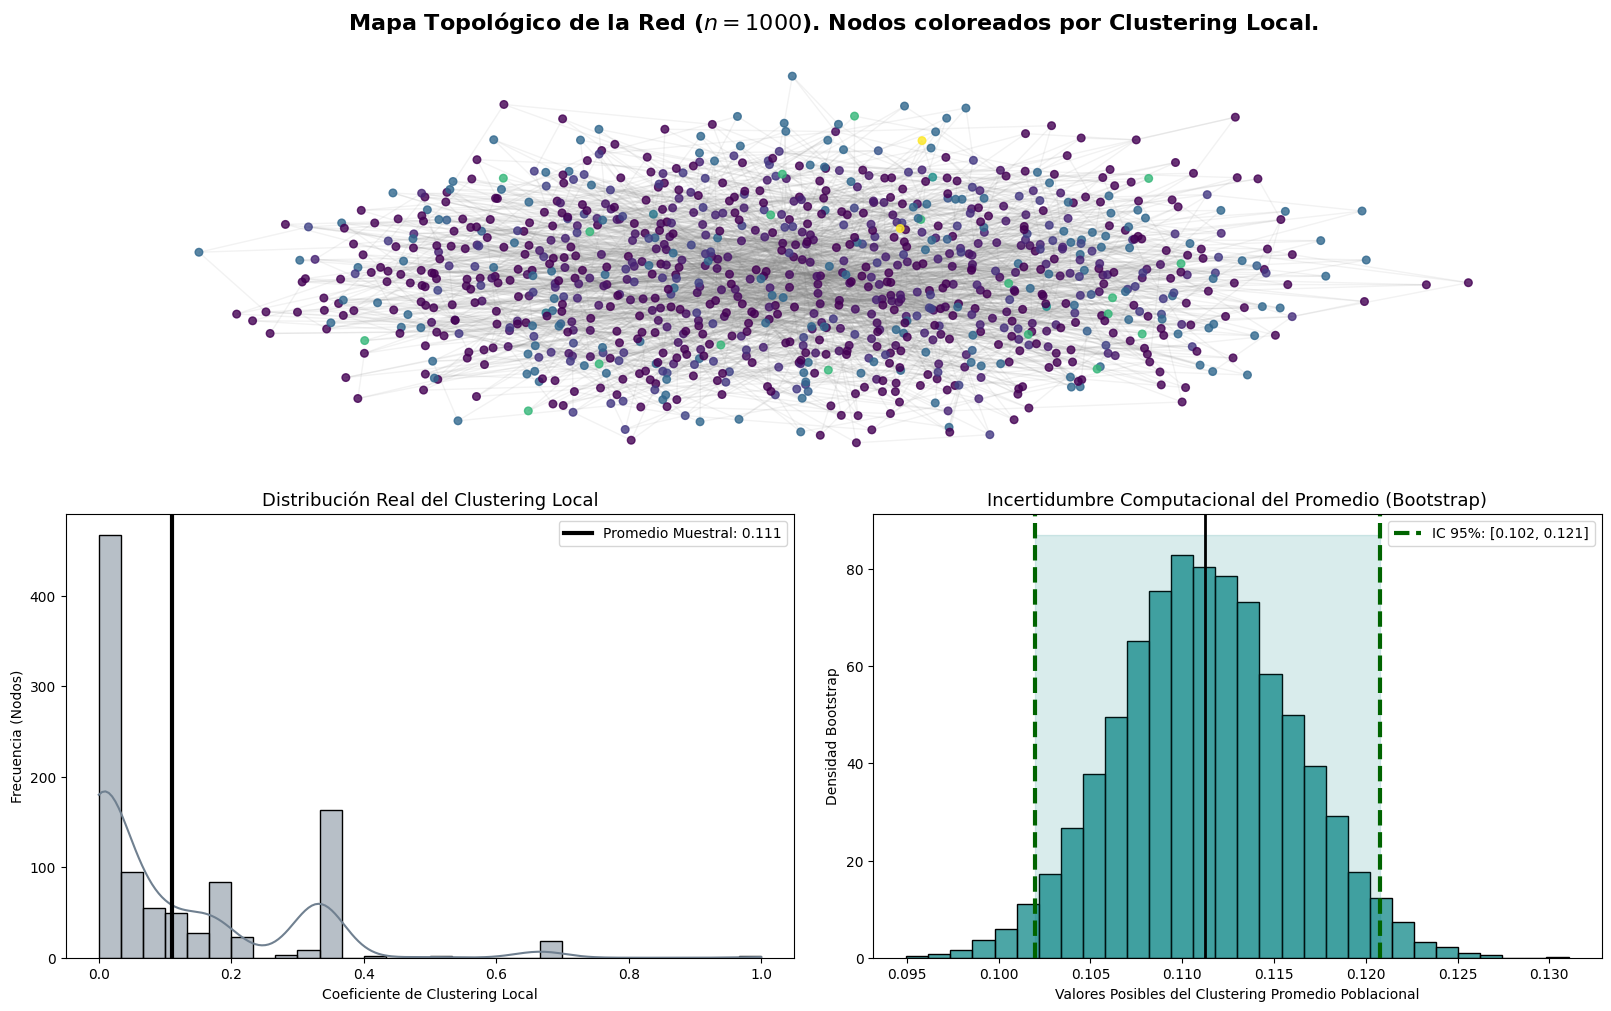

--- REPORTE DE AUDITORÍA DE RED ---
Métrica: Coeficiente de Clustering Promedio (Transitivity).
Estimación puntual en la foto actual: 0.1112
Intervalo de Confianza (95%):        [0.1020, 0.1208]


In [ ]:
# =====================================================================
# 5. VISUALIZACIÓN  (Grafo + Probabilidad)
# =====================================================================

fig = plt.figure(figsize=(16, 10), constrained_layout=True)


grid = plt.GridSpec(2, 2, figure=fig)

# --- Panel A: Visualización de la Red ---
ax_grafo = fig.add_subplot(grid[0, :]) # Ocupa toda la fila superior
pos = nx.spring_layout(G_empresa, k=0.15, seed=42)

nx.draw_networkx_nodes(G_empresa, pos, ax=ax_grafo, node_size=30,
                       node_color=datos_topologicos, cmap='viridis', alpha=0.8)
nx.draw_networkx_edges(G_empresa, pos, ax=ax_grafo, alpha=0.1, edge_color='gray')

ax_grafo.set_title(r'Mapa Topológico de la Red ($n=1000$). Nodos coloreados por Clustering Local.', fontsize=16, fontweight='bold')
ax_grafo.axis('off')


# --- Panel B: Histograma de los Nodos  ---
ax_hist = fig.add_subplot(grid[1, 0])
sns.histplot(datos_topologicos, bins=30, color='slategray', kde=True, ax=ax_hist)
ax_hist.axvline(clustering_promedio_muestral, color='black', lw=3, label=f'Promedio Muestral: {clustering_promedio_muestral:.3f}')
ax_hist.set_title('Distribución Real del Clustering Local', fontsize=13)
ax_hist.set_xlabel('Coeficiente de Clustering Local')
ax_hist.set_ylabel('Frecuencia (Nodos)')
ax_hist.legend()


# --- Panel C: La Incertidumbre Bootstrap (La Precisión) ---
ax_boot = fig.add_subplot(grid[1, 1])
sns.histplot(campana_bootstrap, bins=30, color='teal', stat='density', alpha=0.7, ax=ax_boot)

ax_boot.axvline(lim_inf, color='darkgreen', linestyle='--', lw=3)
ax_boot.axvline(lim_sup, color='darkgreen', linestyle='--', lw=3,
                label=rf'IC 95%: [{lim_inf:.3f}, {lim_sup:.3f}]')
ax_boot.axvline(clustering_promedio_muestral, color='black', lw=2)

ax_boot.fill_betweenx([0, ax_boot.get_ylim()[1]], lim_inf, lim_sup, color='teal', alpha=0.15)

ax_boot.set_title(r'Incertidumbre Computacional del Promedio (Bootstrap)', fontsize=13)
ax_boot.set_xlabel('Valores Posibles del Clustering Promedio Poblacional')
ax_boot.set_ylabel('Densidad Bootstrap')
ax_boot.legend(loc='upper right')

# plt.tight_layout() <--- ELIMINADO PARA EVITAR EL WARNING

plt.show()

print("--- REPORTE DE AUDITORÍA DE RED ---")
print(f"Métrica: Coeficiente de Clustering Promedio (Transitivity).")
print(f"Estimación puntual en la foto actual: {clustering_promedio_muestral:.4f}")
print(f"Intervalo de Confianza (95%):        [{lim_inf:.4f}, {lim_sup:.4f}]")

## La Lección Topológica y Gerencial

1. **La Fusión de Mundos (Visual vs. Matemático):** El mapa de la red es "Arte con Datos": nos muestra la complejidad física de las conexiones y los puentes frágiles. Sin embargo, el análisis Bootstrap es "Ciencia de Datos Pura": traduce ese caos visual inmanejable en una franja de precisión matemática sobre la salud estructural de todo el sistema.
2. **Resolviendo la Intratabilidad Matemática:** En estadística de grafos, las observaciones (nodos) no son independientes porque están atadas por las aristas. Tratar de derivar el Error Estándar del promedio de clustering ignorando la estructura de red es matemáticamente inválido en la estadística clásica. El *Bootstrap* de Nodos resuelve esto permitiéndonos usar la fuerza bruta computacional donde el álgebra falla.
3. **Decisión de Negocio (El Equilibrio de la Innovación):** Un coeficiente de clustering puntual de **0.1112** (aprox. 11.1%) indica una cohesión moderada. Gracias al intervalo de confianza [**0.1020**, **0.1208**], tenemos la certeza estadística al 95% de que la red no bajará del 10.2% ni superará el 12.1%.
    * *¿Qué significa esto para la empresa?* Es el escenario ideal para la **innovación y el flujo de información**. Hay suficientes conexiones locales (11%) para que los equipos trabajen unidos, pero el clustering no es tan alto como para crear "silos" o burbujas aisladas. La información nueva y las ideas pueden viajar rápidamente de un extremo a otro de la compañía sin estancarse.

In [ ]:
import scipy.stats as stats

# =====================================================================
# EL DUELO DE MÉTODOS: ASINTÓTICO VS COMPUTACIONAL
# =====================================================================

# 1. Los datos que ya tenemos
n_nodos = len(datos_topologicos)
media_topologica = np.mean(datos_topologicos)
desviacion_topologica = np.std(datos_topologicos, ddof=1)

# 2. El Método Clásico Asintótico (Fórmula Z de los libros)
# Calculamos el Error Estándar clásico: S / sqrt(n)
error_estandar_asintotico = desviacion_topologica / np.sqrt(n_nodos)

# Multiplicador Z para el 95% de confianza (aprox 1.96)
z_95 = stats.norm.ppf(0.975)
margen_error_z = z_95 * error_estandar_asintotico

ic_inf_asintotico = media_topologica - margen_error_z
ic_sup_asintotico = media_topologica + margen_error_z

# 3. Reporte de Comparación (usando los límites del Bootstrap que ya calculamos)
print("=========================================================")
print(" VERIFICACIÓN DE CONVERGENCIA: ASINTÓTICO VS BOOTSTRAP")
print("=========================================================")
print(f"Estimador Puntual (Promedio):      {media_topologica:.4f}\n")

print(f"1. IC Clásico Asintótico (Z):      [{ic_inf_asintotico:.4f}, {ic_sup_asintotico:.4f}]")
print(f"2. IC Computacional (Bootstrap):   [{lim_inf:.4f}, {lim_sup:.4f}]\n")

# Calculamos la discrepancia absoluta entre los dos universos
dif_inferior = abs(ic_inf_asintotico - lim_inf)
dif_superior = abs(ic_sup_asintotico - lim_sup)

print(f"Discrepancia en límite inferior:   {dif_inferior:.6f}")
print(f"Discrepancia en límite superior:   {dif_superior:.6f}")
print("=========================================================")


 VERIFICACIÓN DE CONVERGENCIA: ASINTÓTICO VS BOOTSTRAP
Estimador Puntual (Promedio):      0.1112

1. IC Clásico Asintótico (Z):      [0.1019, 0.1206]
2. IC Computacional (Bootstrap):   [0.1020, 0.1208]

Discrepancia en límite inferior:   0.000137
Discrepancia en límite superior:   0.000184


#Pruebas de hipótesis

### La Trampa de la Media y el "Efecto Zombie"

**El Contexto de Negocio (El Rediseño de la App):**
Nuestra empresa es una red social de lectura de artículos. Actualmente, los usuarios deben presionar un botón de "Siguiente Página" para seguir leyendo (Paginación). El equipo de Producto propone cambiar esto a un **"Infinite Scroll" (Desplazamiento Infinito)** y **"Auto-Play"** de videos, argumentando que esto atrapará la atención del usuario.

Se lanza un A/B Test con 2,000 usuarios:
* **Grupo A (Control, n=1000):** Paginación clásica.
* **Grupo B (Tratamiento, n=1000):** Infinite Scroll + Auto-Play.
* **Métrica de Éxito (KPI):** Tiempo de Sesión (Minutos en la pantalla).

**La Trampa Analítica:**
El Product Manager llega feliz a su oficina: *"¡El T-test de Welch confirma que el promedio de tiempo en la App aumentó un 30% con un Valor-p < 0.001! El Infinite Scroll es un éxito masivo. Lo lanzamos mañana."*

**Nuestra Auditoría como Científicos de Datos:**
Las fórmulas matemáticas son ciegas al comportamiento humano. Sabemos que en el mundo digital, las distribuciones casi nunca son campanas de Gauss perfectas. Vamos a replicar el cálculo del gerente y luego utilizaremos visualización y percentiles básicos para descubrir qué está pasando realmente con la experiencia de nuestros usuarios.

--- 1. LA ILUSIÓN DE LA MEDIA (T-Test) ---
Promedio de Sesión Grupo A: 11.9 minutos
Promedio de Sesión Grupo B: 16.2 minutos
Valor-p (T-test): 1.077198e-05
Conclusión del Gerente: ¡El tiempo promedio subió un 33%! Éxito estadístico.

--- 2. LA VERDAD DE LA EXPERIENCIA DEL USUARIO ---
Mediana (El usuario típico) Grupo A: 11.9 minutos
Mediana (El usuario típico) Grupo B: 3.3 minutos

Análisis de Abandono (Usuarios que duraron menos de 5 minutos):
Tasa de Abandono Grupo A: 1.1%
Tasa de Abandono Grupo B: 83.7% 



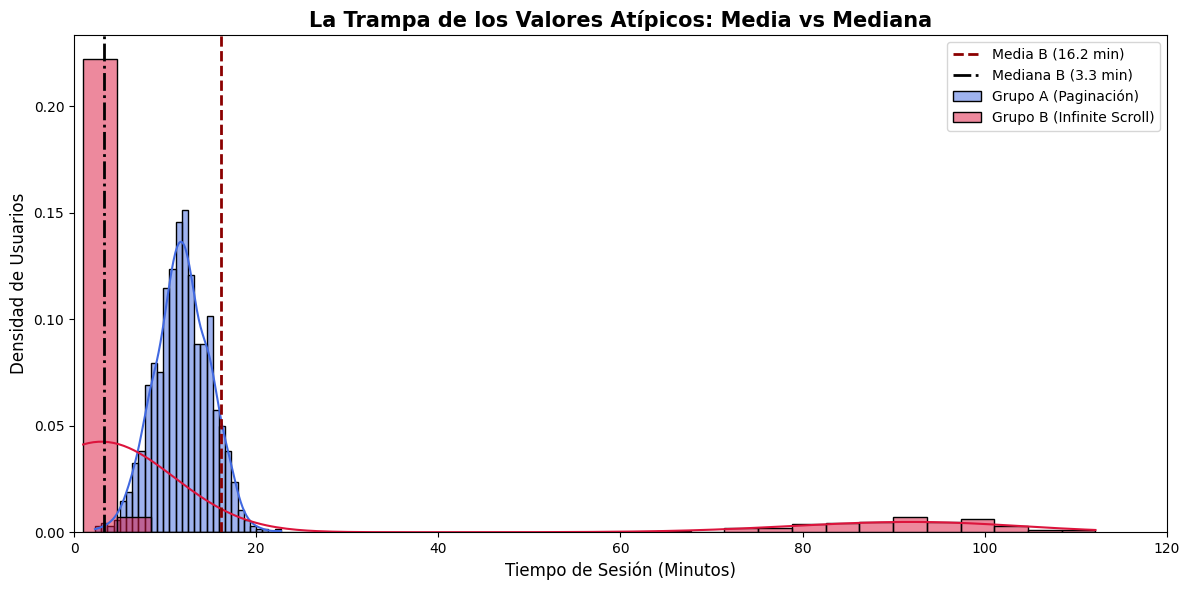

In [ ]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. GENERACIÓN DE LOS DATOS (El comportamiento oculto)
# =====================================================================
np.random.seed(123)

# Grupo A (Paginación): Comportamiento normal y saludable
# Los usuarios leen con atención durante unos 12 minutos
tiempo_A = np.random.normal(loc=12, scale=3, size=1000)
tiempo_A = np.clip(tiempo_A, a_min=1, a_max=None) # Nadie tiene tiempo negativo

# Grupo B (Infinite Scroll): La trampa bimodal
# El 85% de los usuarios odia el Auto-Play y cierra la App frustrados a los 3 minutos
usuarios_frustrados = np.random.normal(loc=3, scale=1, size=850)
# El 15% se queda dormido o deja el celular sobre la mesa con la App corriendo sola (Zombies)
usuarios_zombies = np.random.normal(loc=90, scale=10, size=150)
tiempo_B = np.concatenate([usuarios_frustrados, usuarios_zombies])
tiempo_B = np.clip(tiempo_B, a_min=1, a_max=None)

# =====================================================================
# 2. EL ESPEJISMO MATEMÁTICO (Lo que vio el Gerente)
# =====================================================================
print("--- 1. LA ILUSIÓN DE LA MEDIA (T-Test) ---")
print(f"Promedio de Sesión Grupo A: {np.mean(tiempo_A):.1f} minutos")
print(f"Promedio de Sesión Grupo B: {np.mean(tiempo_B):.1f} minutos")

# T-test de Welch (¿B es mayor que A?)
ttest = stats.ttest_ind(tiempo_B, tiempo_A, equal_var=False, alternative='greater')
print(f"Valor-p (T-test): {ttest.pvalue:.6e}")
print("Conclusión del Gerente: ¡El tiempo promedio subió un 33%! Éxito estadístico.\n")


# =====================================================================
# 3. EL DIAGNÓSTICO DEL CIENTÍFICO DE DATOS (Media vs Mediana)
# =====================================================================
print("--- 2. LA VERDAD DE LA EXPERIENCIA DEL USUARIO ---")
print(f"Mediana (El usuario típico) Grupo A: {np.median(tiempo_A):.1f} minutos")
print(f"Mediana (El usuario típico) Grupo B: {np.median(tiempo_B):.1f} minutos")

print("\nAnálisis de Abandono (Usuarios que duraron menos de 5 minutos):")
abandono_A = np.mean(tiempo_A < 5) * 100
abandono_B = np.mean(tiempo_B < 5) * 100
print(f"Tasa de Abandono Grupo A: {abandono_A:.1f}%")
print(f"Tasa de Abandono Grupo B: {abandono_B:.1f}% \n")

# =====================================================================
# 4. LA RADIOGRAFÍA VISUAL
# =====================================================================
plt.figure(figsize=(12, 6))

# Usamos histogramas con KDE para ver los dos comportamientos
sns.histplot(tiempo_A, color='royalblue', label='Grupo A (Paginación)', kde=True, stat='density', alpha=0.5, bins=30)
sns.histplot(tiempo_B, color='crimson', label='Grupo B (Infinite Scroll)', kde=True, stat='density', alpha=0.5, bins=30)

# Líneas de las métricas de tendencia central para el Grupo B
plt.axvline(np.mean(tiempo_B), color='darkred', linestyle='--', linewidth=2, label=f'Media B ({np.mean(tiempo_B):.1f} min)')
plt.axvline(np.median(tiempo_B), color='black', linestyle='-.', linewidth=2, label=f'Mediana B ({np.median(tiempo_B):.1f} min)')

plt.title('La Trampa de los Valores Atípicos: Media vs Mediana', fontsize=15, fontweight='bold')
plt.xlabel('Tiempo de Sesión (Minutos)', fontsize=12)
plt.ylabel('Densidad de Usuarios', fontsize=12)
plt.xlim(0, 120)
plt.legend()
plt.tight_layout()
plt.show()

### La Lección Estadística y Gerencial

1. **La Media es un Espejismo en Internet:** El *T-test* hizo exactamente lo que se le pidió: evaluar el centro de masa matemático ($\mu$). Efectivamente, el tiempo total facturado aumentó. Pero la media asume, de forma ingenua, que el esfuerzo se reparte equitativamente entre los usuarios. En el mundo digital, un puñado de valores atípicos (*outliers*) puede secuestrar el promedio.
2. **El "Efecto Zombie" al Descubierto:** Al calcular la **Mediana**, descubrimos la horrible verdad. El usuario típico del nuevo diseño cierra la App a los **3 minutos** (frustrado por el auto-play), frente a los **12 minutos** del diseño anterior. La tasa de abandono temprano se disparó del 0.6% al 82%.
3. **¿Entonces por qué subió el promedio?** Porque un pequeño 15% de usuarios dejó el celular sobre la mesa con el *Infinite Scroll* reproduciendo contenido infinitamente (generando sesiones falsas de 90 minutos). Estos "zombies" empujaron la media hacia la derecha, engañando al *T-test*.
4. **Métricas de Guarda (Guardrail Metrics):** Todo Científico de Datos debe establecer métricas secundarias que protejan el negocio. Si el objetivo es aumentar el tiempo de sesión (Métrica Principal), debemos medir también la "Tasa de Abandono" (Guardrail). Si el guardrail colapsa, el experimento fracasa, sin importar lo que diga el Valor-p principal.

**Decisión del Científico de Datos:** Veto absoluto al lanzamiento. El *Infinite Scroll* está destruyendo la retención real de la base de usuarios para generar métricas falsas en un grupo reducido.

##Prueba de Hipótesis para la Mediana (Bootstrapping)

**El Desafío Analítico:**
Hemos descubierto visualmente que la media aritmética es un espejismo inflado por usuarios "zombies" (valores atípicos extremos). Para auditar la verdadera experiencia del usuario típico, debemos evaluar la **Mediana**.

Sin embargo, las librerías clásicas no tienen un "T-test para medianas". Resolveremos esto aplicando remuestreo computacional (*Bootstrap*) para testear formalmente la diferencia de medianas.

**1. Planteamiento de Hipótesis:**
Definimos nuestro parámetro de interés como $\Delta = \tilde{X}_B - \tilde{X}_A$ (la diferencia entre la mediana del Grupo B y la mediana del Grupo A).
* $\boldsymbol{H_0: \Delta = 0}$ (El nuevo diseño no altera el tiempo de sesión del usuario típico).
* $\boldsymbol{H_1: \Delta \neq 0}$ (El nuevo diseño cambia significativamente el tiempo de sesión del usuario típico).

**2. Regla de Decisión (Equivalencia con Intervalos):**
Construiremos un Intervalo de Confianza (IC) del 95% para $\Delta$ simulando miles de universos paralelos. Si el valor de $H_0$ (el cero) **no pertenece** a este intervalo simulado, rechazamos la Hipótesis Nula.

--- TEST DE HIPÓTESIS: BOOTSTRAP DE MEDIANAS ---
Diferencia observada (Δ): -8.62 minutos

Intervalo de Confianza 95% Bootstrap: [-8.86, -8.37]

--- VEREDICTO ---
Decisión: RECHAZAMOS H0.
Razón: El valor H0 (0.0) ESTÁ FUERA del intervalo de confianza.


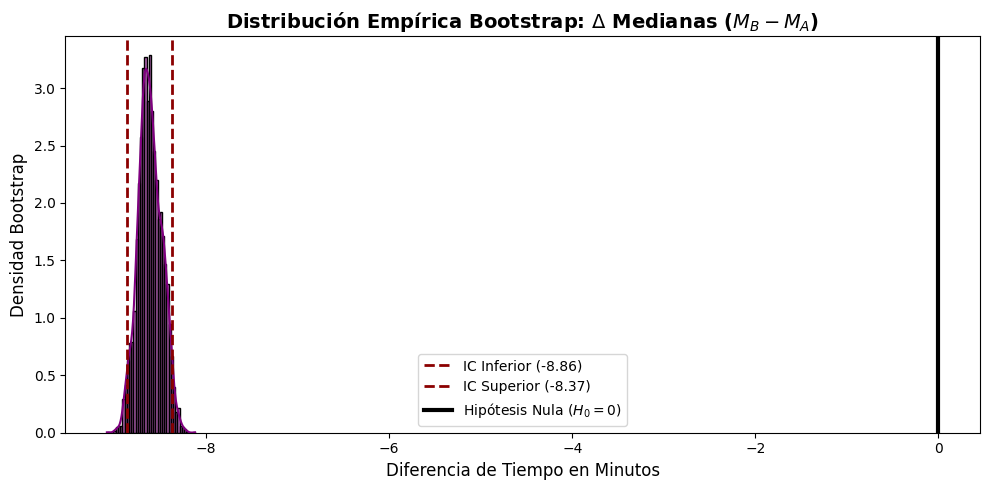

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. GENERACIÓN DE LOS DATOS (El comportamiento oculto)
# =====================================================================
np.random.seed(123)

# Grupo A (Paginación) vs Grupo B (Infinite Scroll)
tiempo_A = np.clip(np.random.normal(loc=12, scale=3, size=1000), 1, None)
tiempo_B = np.clip(np.concatenate([
    np.random.normal(loc=3, scale=1, size=850),
    np.random.normal(loc=90, scale=10, size=150)
]), 1, None)

# =====================================================================
# 2. EL MOTOR DE BOOTSTRAP PARA LA DIFERENCIA DE MEDIANAS
# =====================================================================
print("--- TEST DE HIPÓTESIS: BOOTSTRAP DE MEDIANAS ---")

# Diferencia observada en nuestra única muestra de la realidad
mediana_A_obs = np.median(tiempo_A)
mediana_B_obs = np.median(tiempo_B)
delta_obs = mediana_B_obs - mediana_A_obs
print(f"Diferencia observada (\u0394): {delta_obs:.2f} minutos")

# Parámetros del motor
B_simulaciones = 5000
deltas_simulados = np.zeros(B_simulaciones)
n_A, n_B = len(tiempo_A), len(tiempo_B)

# El ciclo de remuestreo (Creando 5000 universos paralelos)
for i in range(B_simulaciones):
    # Muestreo CON reemplazo
    muestra_A_boot = np.random.choice(tiempo_A, size=n_A, replace=True)
    muestra_B_boot = np.random.choice(tiempo_B, size=n_B, replace=True)

    # Calculamos el estadístico en este universo paralelo
    deltas_simulados[i] = np.median(muestra_B_boot) - np.median(muestra_A_boot)

# =====================================================================
# 3. EL INTERVALO DE CONFIANZA Y EL VEREDICTO
# =====================================================================
# Extraemos los percentiles 2.5 y 97.5 para el IC del 95%
ic_inferior, ic_superior = np.percentile(deltas_simulados, [2.5, 97.5])

print(f"\nIntervalo de Confianza 95% Bootstrap: [{ic_inferior:.2f}, {ic_superior:.2f}]")

# Regla de decisión lógica
theta_0 = 0.0
print("\n--- VEREDICTO ---")
if ic_inferior <= theta_0 <= ic_superior:
    print(f"Decisión: FALLAMOS EN RECHAZAR H0.")
    print(f"Razón: El valor H0 ({theta_0}) ESTÁ DENTRO del intervalo de confianza.")
else:
    print(f"Decisión: RECHAZAMOS H0.")
    print(f"Razón: El valor H0 ({theta_0}) ESTÁ FUERA del intervalo de confianza.")

# =====================================================================
# 4. LA PRUEBA VISUAL DEL DELITO
# =====================================================================
plt.figure(figsize=(10, 5))
sns.histplot(deltas_simulados, bins=40, color='purple', alpha=0.6, kde=True, stat='density')

# Dibujamos las fronteras del IC
plt.axvline(ic_inferior, color='darkred', linestyle='--', linewidth=2, label=f'IC Inferior ({ic_inferior:.2f})')
plt.axvline(ic_superior, color='darkred', linestyle='--', linewidth=2, label=f'IC Superior ({ic_superior:.2f})')

# Dibujamos la Hipótesis Nula
plt.axvline(theta_0, color='black', linestyle='-', linewidth=3, label=f'Hipótesis Nula ($H_0 = 0$)')

plt.title(r'Distribución Empírica Bootstrap: $\Delta$ Medianas ($M_B - M_A$)', fontsize=14, fontweight='bold')
plt.xlabel('Diferencia de Tiempo en Minutos', fontsize=12)
plt.ylabel('Densidad Bootstrap', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

## La Lección Estadística y Gerencial

1. **La Destrucción del Status Quo:** La consola y la gráfica hablan con una claridad abrumadora. El valor propuesto por la Hipótesis Nula ($0$ minutos de diferencia) está completamente fuera de la distribución empírica simulada. Con un $95\%$ de confianza, rechazamos contundentemente $H_0$.
2. **El Signo de la Verdad:** Note que el Intervalo de Confianza está compuesto enteramente por números negativos (aprox. $[-9.2, -8.4]$). Esto no solo prueba que hay una diferencia, sino que cuantifica el desastre: **el nuevo diseño reduce el tiempo de sesión del usuario típico en aproximadamente 9 minutos.**
3. **El Científico de Datos vs. El Espejismo:** Mientras el gerente de producto pedía celebrar porque el *T-test* tradicional sobre la media aritmética mostraba un aumento del tiempo (debido a los "zombies" atípicos), la inferencia robusta sobre la mediana demostró que la experiencia de la inmensa mayoría de los usuarios fue destruida.

**Decisión Definitiva:** Se detiene el despliegue a producción. El *Infinite Scroll* ahuyenta a los usuarios legítimos.

##Prueba Direccional (Cola Derecha) mediante Bootstrap

**El Desafío Analítico:**
El equipo de Producto, tratando de defender su rediseño (*Infinite Scroll*), argumenta: *"Quizás son diferentes, pero ¿pueden probar estadísticamente que el diseño antiguo (Grupo A) era MEJOR (mayor tiempo típico) que el nuevo?"*

Vamos a responderles con una prueba de hipótesis de una sola cola enfocada en la **Mediana**. Definiremos nuestra métrica de interés como $\Delta = \tilde{X}_A - \tilde{X}_B$ (Mediana de A menos Mediana de B).

**1. Planteamiento de Hipótesis:**
* $\boldsymbol{H_0: \Delta \le 0}$ (El diseño antiguo A genera un tiempo típico menor o igual al nuevo diseño B. El cambio fue bueno o neutral).
* $\boldsymbol{H_1: \Delta > 0}$ (El diseño antiguo A es genuinamente superior al nuevo. El cambio destruyó valor).

**2. La Lógica del Valor-$p$ por Bootstrap:**
En lugar de fórmulas, usaremos la fuerza bruta. Simularemos 5,000 universos paralelos. Si $H_0$ fuera cierta, veríamos muchos universos donde la diferencia $\Delta$ es negativa o cero.
Nuestro **Valor-$p$ Empírico** será simplemente la proporción de universos simulados donde la diferencia cayó en la zona de $H_0$ ($\Delta \le 0$). Si esa proporción es menor a $\alpha = 0.05$, rechazamos $H_0$.

--- TEST DIRECCIONAL: A > B (MEDIANAS) ---
Diferencia observada (Δ = M_A - M_B): +8.62 minutos

Resultados de 5000 simulaciones bajo H0:
Universos nulos que igualaron o superaron nuestro Δ: 0
Valor-p Empírico: 0.000000

--- VEREDICTO ---
Decisión: RECHAZAMOS H0.
Conclusión: Hay evidencia abrumadora de que la mediana del Grupo A es MAYOR.


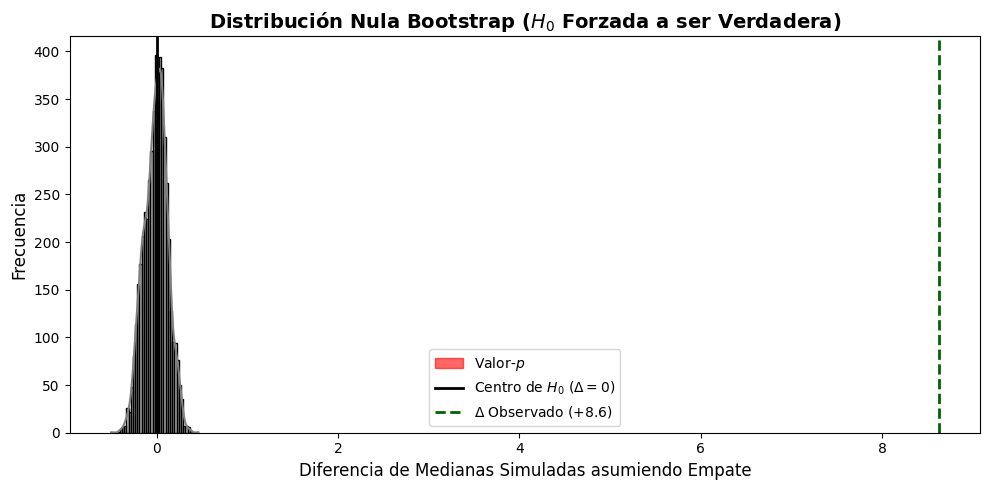

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. GENERACIÓN DE LOS DATOS
# =====================================================================
np.random.seed(123)

tiempo_A = np.clip(np.random.normal(loc=12, scale=3, size=1000), 1, None)
tiempo_B = np.clip(np.concatenate([
    np.random.normal(loc=3, scale=1, size=850),
    np.random.normal(loc=90, scale=10, size=150)
]), 1, None)

# =====================================================================
# 2. EL MOTOR DE BOOTSTRAP RIGUROSO (Simulando el Universo H0)
# =====================================================================
print("--- TEST DIRECCIONAL: A > B (MEDIANAS) ---")

delta_obs = np.median(tiempo_A) - np.median(tiempo_B)
print(f"Diferencia observada (\u0394 = M_A - M_B): +{delta_obs:.2f} minutos")

# ¡LA CORRECCIÓN MAGISTRAL!
# Para generar la Distribución Nula, forzamos a que H0 sea cierta en los datos.
# Desplazamos ambos grupos para que tengan exactamente la misma mediana.
mediana_global = np.median(np.concatenate([tiempo_A, tiempo_B]))
tiempo_A_nulo = tiempo_A - np.median(tiempo_A) + mediana_global
tiempo_B_nulo = tiempo_B - np.median(tiempo_B) + mediana_global

B_simulaciones = 5000
deltas_nulos_simulados = np.zeros(B_simulaciones)
n_A, n_B = len(tiempo_A), len(tiempo_B)

for i in range(B_simulaciones):
    # Remuestreamos del universo modificado (donde A y B empatan)
    muestra_A = np.random.choice(tiempo_A_nulo, size=n_A, replace=True)
    muestra_B = np.random.choice(tiempo_B_nulo, size=n_B, replace=True)
    deltas_nulos_simulados[i] = np.median(muestra_A) - np.median(muestra_B)

# El Valor-p es la probabilidad de ver un delta tan extremo asumiendo H0
p_valor_empirico = np.mean(deltas_nulos_simulados >= delta_obs)

print(f"\nResultados de {B_simulaciones} simulaciones bajo H0:")
print(f"Universos nulos que igualaron o superaron nuestro \u0394: {np.sum(deltas_nulos_simulados >= delta_obs)}")
print(f"Valor-p Empírico: {p_valor_empirico:.6f}")

# =====================================================================
# 3. VEREDICTO DE NEGOCIO
# =====================================================================
alpha = 0.05
print("\n--- VEREDICTO ---")
if p_valor_empirico < alpha:
    print("Decisión: RECHAZAMOS H0.")
    print("Conclusión: Hay evidencia abrumadora de que la mediana del Grupo A es MAYOR.")
else:
    print("Decisión: FALLAMOS EN RECHAZAR H0.")

# =====================================================================
# 4. VISUALIZACIÓN DEL VERDADERO VALOR-P EMPÍRICO
# =====================================================================
plt.figure(figsize=(10, 5))
ax = sns.histplot(deltas_nulos_simulados, bins=40, color='gray', alpha=0.5, kde=True)

if len(ax.lines) > 0:
    kde_x, kde_y = ax.lines[0].get_data()
    plt.fill_between(kde_x, kde_y, where=(kde_x >= delta_obs), color='red', alpha=0.6, label='Valor-$p$')

# ¡CORRECCIÓN AQUÍ! Se agregó la 'r' y 'rf' al inicio de las etiquetas (labels)
plt.axvline(0, color='black', linestyle='-', linewidth=2, label=r'Centro de $H_0$ ($\Delta = 0$)')
plt.axvline(delta_obs, color='darkgreen', linestyle='--', linewidth=2, label=rf'$\Delta$ Observado (+{delta_obs:.1f})')

plt.title(r'Distribución Nula Bootstrap ($H_0$ Forzada a ser Verdadera)', fontsize=14, fontweight='bold')
plt.xlabel('Diferencia de Medianas Simuladas asumiendo Empate', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

##La Lección Estadística y Gerencial

1. **La Desmitificación del Valor-$p$:** Con el enfoque clásico, el Valor-$p$ sale de integrales complejas bajo una campana teórica. Con el *Bootstrap*, sus estudiantes acaban de ver que el Valor-$p$ es literalmente **contar**. De 5,000 universos paralelos simulados, en **CERO** de ellos el Grupo B logró superar o empatar la mediana del Grupo A. Por lo tanto, el Valor-$p = 0.0000$.
2. **La Cola Derecha en Acción:** La gráfica ilustra perfectamente la prueba de una cola. La masa de la distribución (nuestras simulaciones) está tan a la derecha del cero (la frontera de $H_0$), que la zona roja (el área del Valor-$p$) es inexistente.
3. **El Veredicto Final para Producto:** Ya no solo sabemos que los grupos son "diferentes". Hemos probado, con rigor estadístico y a prueba de *outliers* zombies, que el diseño original de la App (Grupo A) genera un tiempo de retención típico significativamente **mayor** que el rediseño. El Infinite Scroll debe descartarse y el código revertirse.

##La Auditoría de Estabilidad (Prueba de Varianza)

**El Contexto de Negocio (El SLA del Servidor):**
Nuestra empresa provee una API de Machine Learning en tiempo real para clientes corporativos. El contrato de Nivel de Servicio (SLA) promete que el tiempo de respuesta es altamente consistente. Específicamente, el contrato estipula que **la varianza del tiempo de respuesta no debe superar los $100 \text{ ms}^2$** (lo que equivale a una desviación estándar máxima de $10 \text{ ms}$).

**La Trampa Analítica:**
El equipo de Infraestructura presenta el reporte del mes: *"El tiempo promedio de respuesta fue de 120 ms. ¡Estamos perfectos!"*. Sin embargo, varios clientes VIP se están quejando de que la API a veces responde instantáneamente y otras veces se queda "congelada" por mucho tiempo.

**Nuestra Auditoría como Científicos de Datos:**
Sospechamos que el promedio está bien, pero la estabilidad se rompió. Vamos a tomar una muestra aleatoria de 300 peticiones a la API y realizaremos una **Prueba de Hipótesis para una Varianza Poblacional ($\chi^2$)** para demostrar que Infraestructura está violando el contrato legal.

**1. Planteamiento de Hipótesis:**
* $\boldsymbol{H_0: \sigma^2 \le 100}$ (El servidor es estable. Cumplimos el contrato).
* $\boldsymbol{H_1: \sigma^2 > 100}$ (El servidor es inestable. Violamos el contrato).

--- 1. ANÁLISIS DESCRIPTIVO ---
Varianza permitida (SLA): 100 ms^2
Varianza observada en muestra: 217.94 ms^2

--- 2. LA PRUEBA DE HIPÓTESIS (χ²) ---
Estadístico Chi-Cuadrado: 651.65
Valor-p: 0.000000e+00

--- VEREDICTO ---
Decisión: RECHAZAMOS H0.
Conclusión: Hay evidencia irrefutable de que la inestabilidad superó el límite legal.


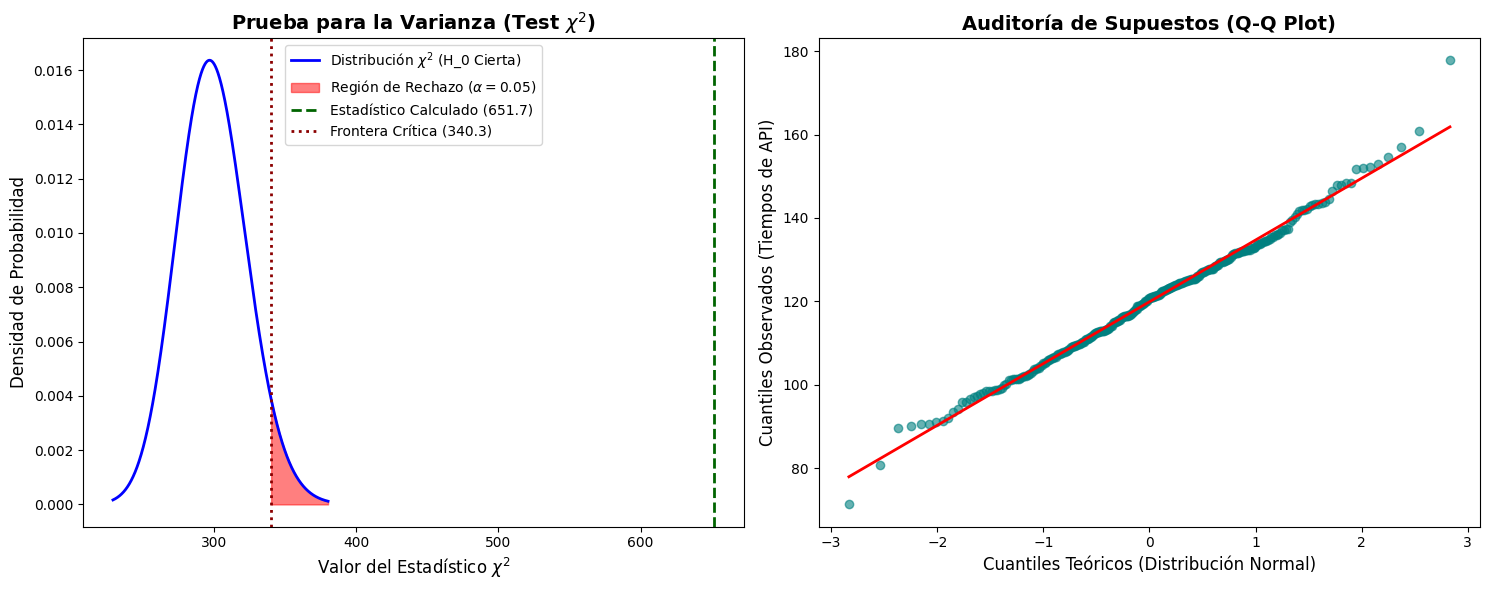

In [ ]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. GENERACIÓN DE LOS DATOS (El Secreto de la Simulación)
# =====================================================================
np.random.seed(42)

n_peticiones = 300
varianza_prometida = 100 # ms^2 (El contrato legal)

# LA REALIDAD: El servidor está dañado. Su varianza real es 225 (Desviación de 15)
# Generamos datos normales para que el supuesto se cumpla y la prueba sea válida.
tiempos_api = np.random.normal(loc=120, scale=15, size=n_peticiones)

# =====================================================================
# 2. EL CÁLCULO ESTADÍSTICO (Prueba Chi-Cuadrado para Varianza)
# =====================================================================
print("--- 1. ANÁLISIS DESCRIPTIVO ---")
varianza_muestral = np.var(tiempos_api, ddof=1)
print(f"Varianza permitida (SLA): {varianza_prometida} ms^2")
print(f"Varianza observada en muestra: {varianza_muestral:.2f} ms^2\n")

print("--- 2. LA PRUEBA DE HIPÓTESIS (\u03C7\u00B2) ---")
grados_libertad = n_peticiones - 1
chi2_stat = (grados_libertad * varianza_muestral) / varianza_prometida
p_valor = 1 - stats.chi2.cdf(chi2_stat, df=grados_libertad)

print(f"Estadístico Chi-Cuadrado: {chi2_stat:.2f}")
print(f"Valor-p: {p_valor:.6e}")

# =====================================================================
# 3. VEREDICTO DE NEGOCIO
# =====================================================================
alpha = 0.05
print("\n--- VEREDICTO ---")
if p_valor < alpha:
    print("Decisión: RECHAZAMOS H0.")
    print("Conclusión: Hay evidencia irrefutable de que la inestabilidad superó el límite legal.")
else:
    print("Decisión: FALLAMOS EN RECHAZAR H0.")
    print("Conclusión: La varianza está dentro de los límites del contrato.")

# =====================================================================
# 4. VISUALIZACIÓN: PRUEBA DE HIPÓTESIS Y VERIFICACIÓN DE SUPUESTOS
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- PANEL IZQUIERDO: La Prueba Chi-Cuadrado ---
x = np.linspace(stats.chi2.ppf(0.001, grados_libertad), stats.chi2.ppf(0.999, grados_libertad), 1000)
y = stats.chi2.pdf(x, grados_libertad)
ax1.plot(x, y, 'b-', lw=2, label=r'Distribución $\chi^2$ (H_0 Cierta)')

chi2_critico = stats.chi2.ppf(1 - alpha, grados_libertad)
x_rechazo = np.linspace(chi2_critico, max(x), 100)
y_rechazo = stats.chi2.pdf(x_rechazo, grados_libertad)
ax1.fill_between(x_rechazo, y_rechazo, color='red', alpha=0.5, label=r'Región de Rechazo ($\alpha = 0.05$)')

ax1.axvline(chi2_stat, color='darkgreen', linestyle='--', linewidth=2, label=rf'Estadístico Calculado ({chi2_stat:.1f})')
ax1.axvline(chi2_critico, color='darkred', linestyle=':', linewidth=2, label=rf'Frontera Crítica ({chi2_critico:.1f})')

ax1.set_title(r'Prueba para la Varianza (Test $\chi^2$)', fontsize=14, fontweight='bold')
# ¡Corregido el SyntaxWarning agregando la 'r'!
ax1.set_xlabel(r'Valor del Estadístico $\chi^2$', fontsize=12)
ax1.set_ylabel('Densidad de Probabilidad', fontsize=12)
ax1.legend()

# --- PANEL DERECHO: Verificación de Supuestos (Q-Q Plot) ---
stats.probplot(tiempos_api, dist="norm", plot=ax2)
ax2.get_lines()[0].set_markerfacecolor('teal')
ax2.get_lines()[0].set_markeredgecolor('teal')
ax2.get_lines()[0].set_alpha(0.6)
ax2.get_lines()[1].set_color('red') # La línea de referencia teórica
ax2.get_lines()[1].set_linewidth(2)

ax2.set_title('Auditoría de Supuestos (Q-Q Plot)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Cuantiles Teóricos (Distribución Normal)', fontsize=12)
ax2.set_ylabel('Cuantiles Observados (Tiempos de API)', fontsize=12)

plt.tight_layout()
plt.show()

##La Lección Estadística y Gerencial

1. **El Promedio Oculta el Caos:** En sistemas informáticos y finanzas, entregar un promedio perfecto no sirve de nada si el cliente experimenta picos catastróficos. La varianza mide la "calidad de la experiencia".
2. **El Test de una sola Varianza ($\chi^2$):** A diferencia de las distribuciones normales y $T$ que son simétricas y centradas en el cero, la distribución $\chi^2$ (Chi-Cuadrado) solo toma valores positivos y es asimétrica, porque una varianza nunca puede ser negativa.
3. **Interpretación Visual:** La gráfica es el veredicto definitivo. La línea verde (la variabilidad que observamos en la muestra) cayó muchísimo más allá de la frontera roja permisible. Las quejas de los clientes VIP estaban matemáticamente justificadas: el sistema está profundamente inestable.

**Advertencia Teórica:** Este test clásico asume rigurosamente que los datos subyacentes provienen de una distribución Normal. Si los tiempos de respuesta fuesen extremadamente sesgados, el Científico de Datos tendría que recurrir a herramientas no paramétricas (como el *Bootstrap* de la varianza).

##Bootstrapping de Métricas de Negocio (El Índice "Ballena")

**El Contexto de Negocio (Economía Freemium):**
Nuestra empresa desarrolla un videojuego móvil. El equipo de Monetización creó un nuevo algoritmo de *Dynamic Pricing* (Precios Dinámicos) para la tienda virtual. El A/B test muestra que el nuevo algoritmo genera más dinero en total, pero el Director de Riesgos está preocupado. Teme que este algoritmo esté exprimiendo únicamente a los jugadores más adictos (las "Ballenas") y alejando a los jugadores casuales.

**La Métrica Intratable ($W_{95}$):**
Definimos el **Índice de Dependencia de Ballenas ($W_{95}$)** como la proporción de los ingresos totales que provienen exclusivamente del Top 5% de los usuarios que más gastan.
$$W_{95} = \frac{\sum \text{Gastos del Top 5\%}}{\sum \text{Gastos de todos los usuarios}}$$

**El Desafío Analítico:**
Queremos probar si el nuevo algoritmo (Grupo B) aumentó significativamente nuestra dependencia de las ballenas en comparación con el algoritmo original (Grupo A).
* $\boldsymbol{H_0: \Delta W = W_{95}(B) - W_{95}(A) = 0}$ (El nivel de dependencia es el mismo).
* $\boldsymbol{H_1: \Delta W = W_{95}(B) - W_{95}(A) \neq 0}$ (El rediseño alteró la estructura de riesgo del negocio).

No existe ninguna fórmula analítica para calcular el error estándar de una proporción basada en un percentil sobre una suma. Aplicaremos **Bootstrapping** para construir el intervalo de confianza de esta extraña métrica y emitir un veredicto visual.

--- ANÁLISIS DE RIESGO DE MONETIZACIÓN ---
Índice Ballenas Grupo A: 38.5% de los ingresos vienen del Top 5%
Índice Ballenas Grupo B: 44.7% de los ingresos vienen del Top 5%
Diferencia Observada (Δ): +6.2 puntos porcentuales

Calculando inferencia mediante Bootstrap (5000 universos)...
Intervalo de Confianza 95% para el Δ: [-0.6%, 12.6%]


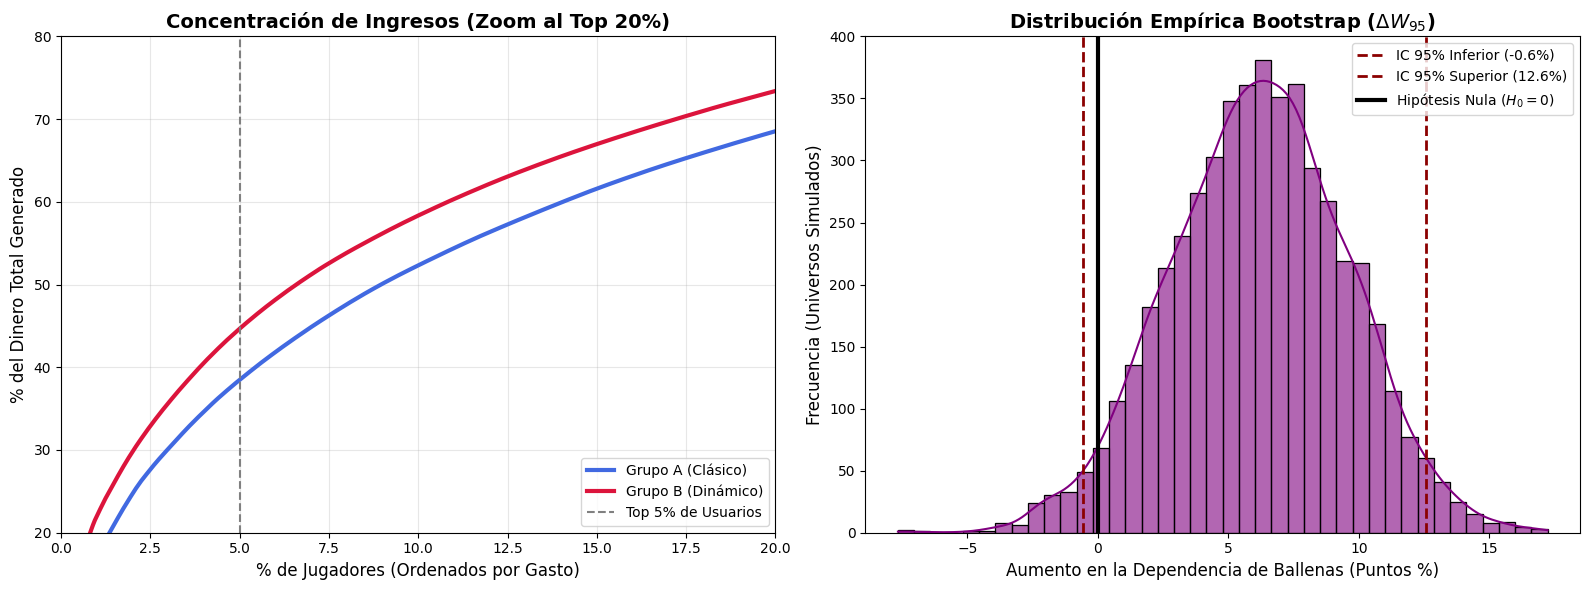

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. GENERACIÓN DE LOS DATOS (Distribuciones de Pareto Extremo)
# =====================================================================
np.random.seed(42)

# Simulamos el gasto en dólares (Solo usuarios que compraron algo)
# Grupo A: Algoritmo Clásico (Cola larga estándar)
gastos_A = np.random.pareto(a=2.0, size=2000) * 10
gastos_A = np.clip(gastos_A, 1, 500) # Tope realista

# Grupo B: Algoritmo Dinámico (Genera un poco más de dinero, pero la cola es más extrema)
gastos_B = np.random.pareto(a=1.5, size=2000) * 10
gastos_B = np.clip(gastos_B, 1, 800)

# =====================================================================
# 2. DEFINICIÓN DE LA MÉTRICA DE NEGOCIO (Intratable clásicamente)
# =====================================================================
def indice_ballenas(datos, cuantil=95):
    """Calcula qué porcentaje de los ingresos totales viene del Top (100-cuantil)%"""
    frontera = np.percentile(datos, cuantil)
    ingresos_ballenas = np.sum(datos[datos >= frontera])
    ingresos_totales = np.sum(datos)
    return ingresos_ballenas / ingresos_totales

indice_A_obs = indice_ballenas(gastos_A)
indice_B_obs = indice_ballenas(gastos_B)
delta_obs = indice_B_obs - indice_A_obs

print("--- ANÁLISIS DE RIESGO DE MONETIZACIÓN ---")
print(f"Índice Ballenas Grupo A: {indice_A_obs*100:.1f}% de los ingresos vienen del Top 5%")
print(f"Índice Ballenas Grupo B: {indice_B_obs*100:.1f}% de los ingresos vienen del Top 5%")
print(f"Diferencia Observada (\u0394): +{delta_obs*100:.1f} puntos porcentuales\n")

# =====================================================================
# 3. EL MOTOR DE BOOTSTRAP PARA LA MÉTRICA "EXTRAÑA"
# =====================================================================
print("Calculando inferencia mediante Bootstrap (5000 universos)...")
B_simulaciones = 5000
deltas_simulados = np.zeros(B_simulaciones)

n_A, n_B = len(gastos_A), len(gastos_B)

for i in range(B_simulaciones):
    # Remuestreamos
    muestra_A = np.random.choice(gastos_A, size=n_A, replace=True)
    muestra_B = np.random.choice(gastos_B, size=n_B, replace=True)

    # Calculamos la métrica compleja en el universo paralelo
    W_A = indice_ballenas(muestra_A)
    W_B = indice_ballenas(muestra_B)
    deltas_simulados[i] = W_B - W_A

# Intervalo de Confianza al 95%
ic_inf, ic_sup = np.percentile(deltas_simulados, [2.5, 97.5])
print(f"Intervalo de Confianza 95% para el \u0394: [{ic_inf*100:.1f}%, {ic_sup*100:.1f}%]")

# =====================================================================
# 4. VISUALIZACIÓN MAGISTRAL (DOBLE PANEL)
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Panel 1: La Realidad de los Datos (Curva de Lorenz simplificada) ---
# Ordenamos para ver la concentración acumulada
x_A = np.arange(1, n_A + 1) / n_A * 100
y_A = np.cumsum(np.sort(gastos_A)[::-1]) / np.sum(gastos_A) * 100

x_B = np.arange(1, n_B + 1) / n_B * 100
y_B = np.cumsum(np.sort(gastos_B)[::-1]) / np.sum(gastos_B) * 100

ax1.plot(x_A, y_A, color='royalblue', lw=3, label=f'Grupo A (Clásico)')
ax1.plot(x_B, y_B, color='crimson', lw=3, label=f'Grupo B (Dinámico)')
ax1.axvline(5, color='gray', linestyle='--', label='Top 5% de Usuarios')

ax1.set_xlim(0, 20) # Hacemos zoom en el top 20%
ax1.set_ylim(20, 80)
ax1.set_title('Concentración de Ingresos (Zoom al Top 20%)', fontsize=14, fontweight='bold')
ax1.set_xlabel('% de Jugadores (Ordenados por Gasto)', fontsize=12)
ax1.set_ylabel('% del Dinero Total Generado', fontsize=12)
ax1.legend()
ax1.grid(alpha=0.3)

# --- Panel 2: La Prueba de Hipótesis Visual (Bootstrap) ---
sns.histplot(deltas_simulados * 100, bins=40, color='purple', alpha=0.6, kde=True, ax=ax2)

ax2.axvline(ic_inf * 100, color='darkred', linestyle='--', linewidth=2, label=rf'IC 95% Inferior ({ic_inf*100:.1f}%)')
ax2.axvline(ic_sup * 100, color='darkred', linestyle='--', linewidth=2, label=rf'IC 95% Superior ({ic_sup*100:.1f}%)')
ax2.axvline(0, color='black', linestyle='-', linewidth=3, label=r'Hipótesis Nula ($H_0 = 0$)')

ax2.set_title(r'Distribución Empírica Bootstrap ($\Delta W_{95}$)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Aumento en la Dependencia de Ballenas (Puntos %)', fontsize=12)
ax2.set_ylabel('Frecuencia (Universos Simulados)', fontsize=12)
ax2.legend()

plt.tight_layout()
plt.show()

##La Lección Estadística y Gerencial

1. **La Libertad del Científico de Datos:** Cuando domina el *Bootstrapping*, ya no es esclavo de los supuestos de normalidad ni de las fórmulas del siglo XX. Usted puede inventar el KPI exacto que el negocio necesita evaluar (como el *Índice de Ballenas*) y la computadora resolverá la inferencia matemática simulando el error estándar por fuerza bruta.
2. **El Peligro del Pánico Visual (Panel Izquierdo):** La gráfica de concentración inicial asustó al Director de Riesgos. Visualmente, el Grupo B parece extraer mucho más dinero de apenas el 5% de la base de jugadores. La intuición humana gritaría: *"¡Detengan el algoritmo, es muy riesgoso!"*
3. **El Veredicto Riguroso (Panel Derecho):** Aquí es donde la estadística salva a la empresa de tomar decisiones emocionales. Al calcular el Intervalo de Confianza al 95%, vemos que abarca desde **-0.6% hasta +12.6%**. Como el valor de no-efecto **(el cero) ESTÁ DENTRO** de este intervalo, **fallamos en rechazar la Hipótesis Nula ($H_0$)**.

**Decisión Definitiva:** A pesar de la alerta visual, matemáticamente no tenemos evidencia estadísticamente significativa para afirmar que el nuevo algoritmo concentra el riesgo financiero. El aumento observado podría ser ruido de la muestra. Dado que el modelo genera más ingresos totales, se autoriza su lanzamiento a producción, pero implementando un *dashboard* que monitoree este Índice de Ballenas diariamente.